In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

In [2]:
with open("../../ford_categories.json", "r", encoding='utf-8') as file:
    ford_categories = json.load(file)

In [3]:
df_c19 = pd.read_csv('../../data/outputs/cord19/c19_final.csv')
df_m17 = pd.read_csv('../../data/outputs/m17+/m17_final.csv')
df_c19 = df_c19.astype({'cited':'int32'})
df_m17 = df_m17.astype({'evaluation':'int32'})

In [4]:
def plot_categorical_distribution(df, target_variable, categorical_variable):
    plt.figure(figsize=(10, 6))
    data = '_c19' if target_variable == 'cited' else '_m17'
    sns.set_palette('viridis')

    if df[df[categorical_variable] == 'medium'].shape[0] != 0:
        category_order = ['low', 'medium', 'high']
        ax = sns.countplot(data=df, x=categorical_variable, hue=target_variable, order=category_order, palette='viridis')
    else:
        ax = sns.countplot(data=df, x=categorical_variable, hue=target_variable, palette='viridis')
    
    plt.ylabel('Count')
    if '0' in categorical_variable:
        categorical_variable = ford_categories[categorical_variable]
    plt.xlabel(categorical_variable)

    plt.title(f'Distribution of {categorical_variable} by {target_variable}')

    for p in ax.patches:
        if p.get_height() != 0:
            ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                        textcoords='offset points')

    plt.legend(title=target_variable)
    plt.xticks(rotation=45)  

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

    plt.show()


from scipy.stats import chi2_contingency
from sklearn.utils import resample

def get_stat_significance(df, categorical_variable, target_variable, n_bootstrap=2500):
    cross_tab = pd.crosstab(df[categorical_variable], df[target_variable])

    chi2, p_val, _, expected_freq = chi2_contingency(cross_tab)

    # Calculate effect size (Cramér's V)
    n = cross_tab.sum().sum()  # total number of observations
    k = min(cross_tab.shape) - 1  # smaller of (rows - 1) or (columns - 1)
    cramers_v = np.sqrt(chi2 / (n * k))

    # Bootstrap validation
    bootstrap_p_values = []
    i = 0
    for _ in range(n_bootstrap):
        df_sample = resample(df)
        cross_tab_sample = pd.crosstab(df_sample[categorical_variable], df_sample[target_variable])
        if cross_tab_sample.shape == cross_tab.shape:  # Ensure same shape for comparison
            chi2_sample, p_val_sample, _, _ = chi2_contingency(cross_tab_sample)
            if p_val_sample < 0.05:
                i+= 1
            bootstrap_p_values.append(p_val_sample)

    mean_p_val = np.mean(bootstrap_p_values)

    # print(f"Chi-Squared Value: {chi2}")
    print(f"Original P-value: {p_val}")
    print(f"Bootstrap Mean P-value: {mean_p_val}")
    print(f"Relationship is significant in {i}/{n_bootstrap} bootstrap samples.")

    print(f"Cramér's V (Effect Size): {cramers_v}")

    # Interpret effect size (Cramér's V)
    effect_size_interpretation = (
        "Weak association" if cramers_v <= 0.1 else
        "Moderate association" if cramers_v <= 0.3 else
        "Strong association"
    )
    print(f"Effect Size: {effect_size_interpretation}")

    if p_val < 0.05:
        print(f"Significant association between {categorical_variable} and {target_variable}.")
    else:
        print(f"No significant association between {categorical_variable} and {target_variable}.")

    print("---------------------------------------------------------------")



# def get_stat_significance(df, categorical_variable, target_variable):
#     cross_tab = pd.crosstab(df[categorical_variable], df[target_variable])
#     # print(cross_tab)
# 
#     chi2, p_val, _, expected_freq = chi2_contingency(cross_tab)
# 
#     # Calculate effect size (Cramér's V)
#     n = cross_tab.sum().sum()  # total number of observations
#     k = min(cross_tab.shape) - 1  # smaller of (rows - 1) or (columns - 1)
#     cramers_v = np.sqrt(chi2 / (n * k))
# 
#     print("Chi-Squared Value:", chi2)
#     print("P-value:", p_val)
#     print("Cramér's V (Effect Size):", cramers_v)
# 
#     # Interpret effect size (Cramér's V)
#     if cramers_v <= 0.1:
#         effect_size_interpretation = "Weak association"
#     elif cramers_v <= 0.3:
#         effect_size_interpretation = "Moderate association"
#     else:
#         effect_size_interpretation = "Strong association"
# 
#     print("Effect Size:", effect_size_interpretation)
# 
#     if p_val < 0.05:
#         print(f"There is a significant association between {categorical_variable} and {target_variable}.")
#     else:
#         print(f"There is no significant association between {categorical_variable} and {target_variable}")
# 
#     print("---------------------------------------------------------------")

Original P-value: 0.0008586505323392688
Bootstrap Mean P-value: 0.015345057383401127
Relationship is significant in 2305/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06862875226025426
Effect Size: Weak association
Significant association between novelty and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


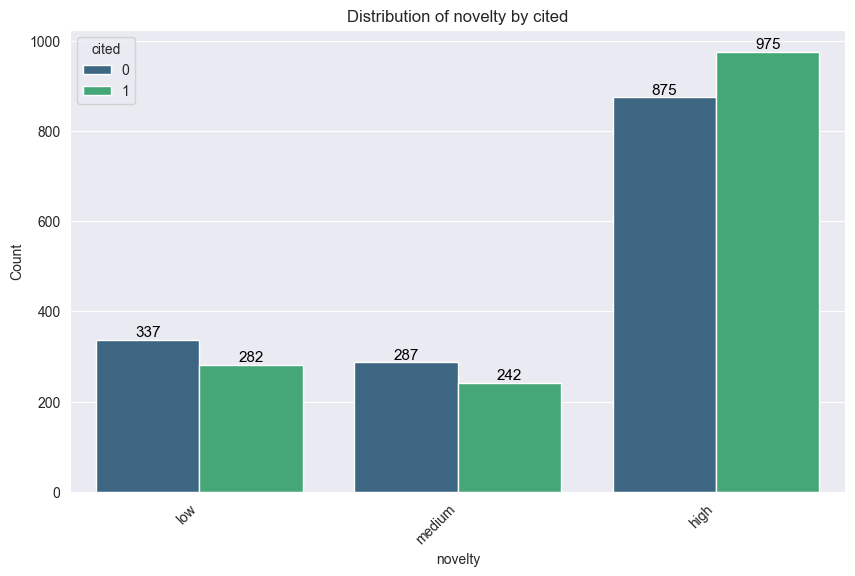

Original P-value: 1.9920906553215145e-47
Bootstrap Mean P-value: 9.548024240572979e-33
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.24508303513948965
Effect Size: Moderate association
Significant association between novelty and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


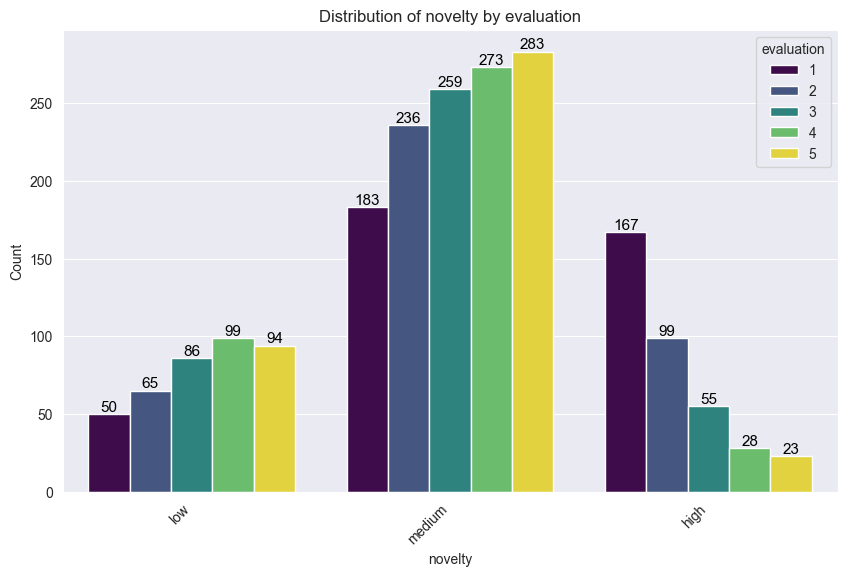

In [5]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='novelty')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="novelty")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='novelty')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="novelty")

Original P-value: 3.263381969650772e-17
Bootstrap Mean P-value: 1.8090938691746771e-09
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1540842873008556
Effect Size: Moderate association
Significant association between basic_medicine and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


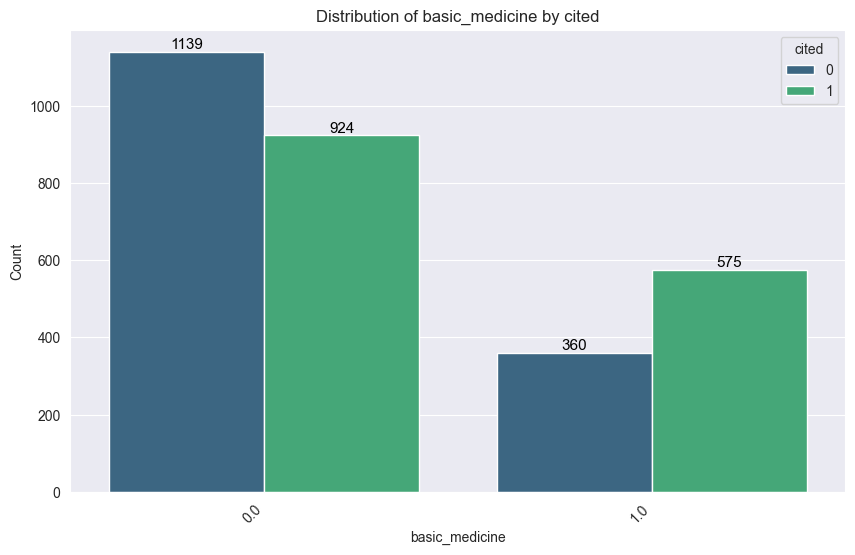

Original P-value: 1.3259480087015795e-41
Bootstrap Mean P-value: 4.287089792597191e-28
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.314207400404362
Effect Size: Strong association
Significant association between basic_medicine and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


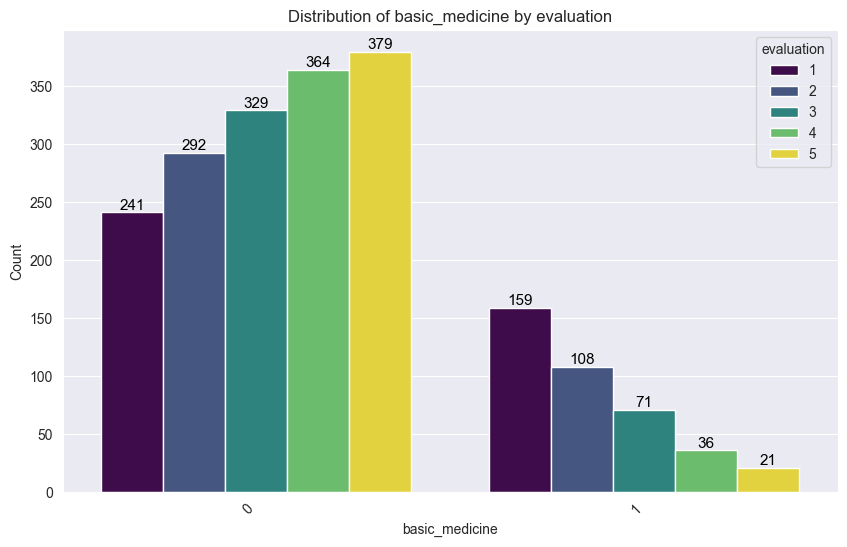

In [6]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='basic_medicine')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="basic_medicine")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='basic_medicine')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="basic_medicine")

Original P-value: 0.0661537695532712
Bootstrap Mean P-value: 0.16657467169356954
Relationship is significant in 1123/2500 bootstrap samples.
Cramér's V (Effect Size): 0.03355700919216443
Effect Size: Weak association
No significant association between applied_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


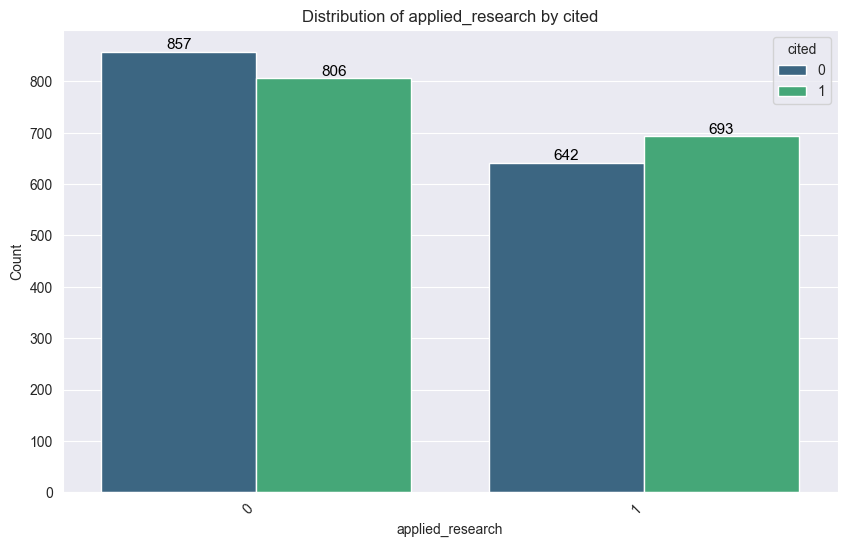

Original P-value: 7.516505691881803e-10
Bootstrap Mean P-value: 6.9389985948539775e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.15568257207006558
Effect Size: Moderate association
Significant association between applied_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


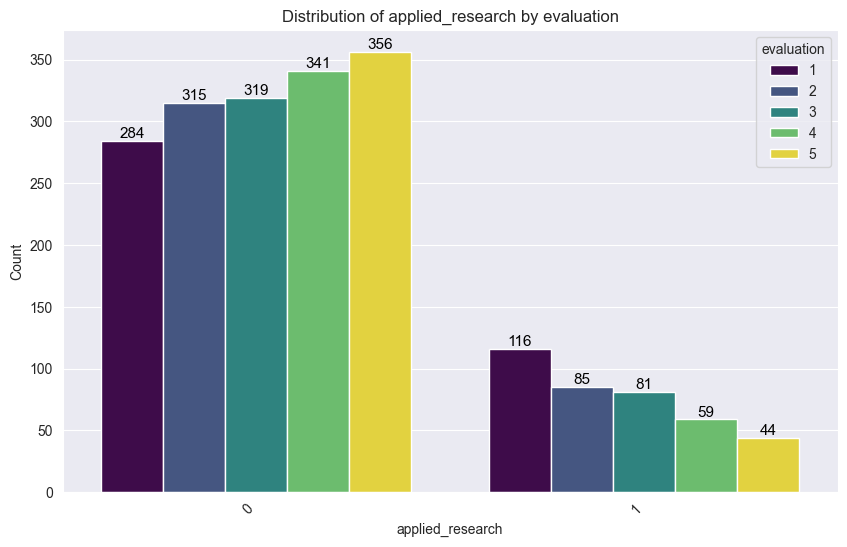

In [7]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='applied_research')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="applied_research")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='applied_research')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="applied_research")

Original P-value: 0.9467455187293435
Bootstrap Mean P-value: 0.5296415770961556
Relationship is significant in 114/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0012198968752529413
Effect Size: Weak association
No significant association between grammar and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


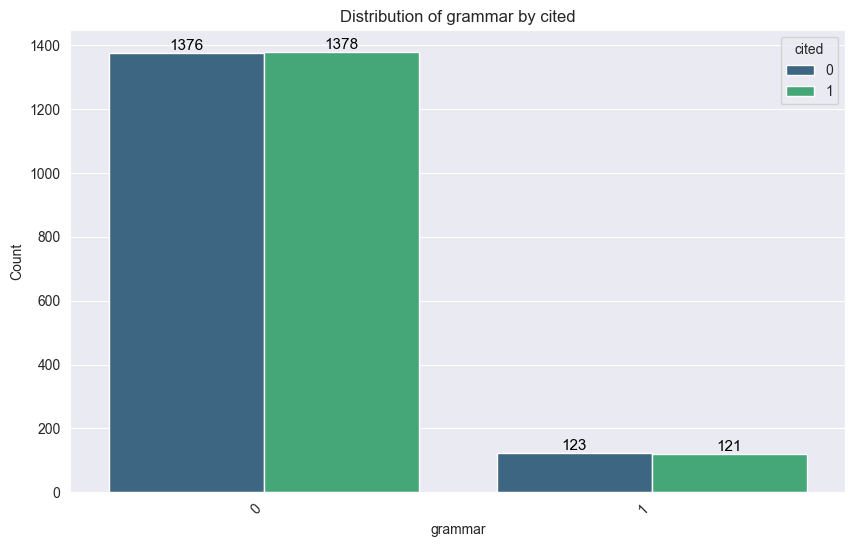

Original P-value: 4.6865211722534796e-20
Bootstrap Mean P-value: 1.826655373742316e-11
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2200161484028683
Effect Size: Moderate association
Significant association between grammar and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


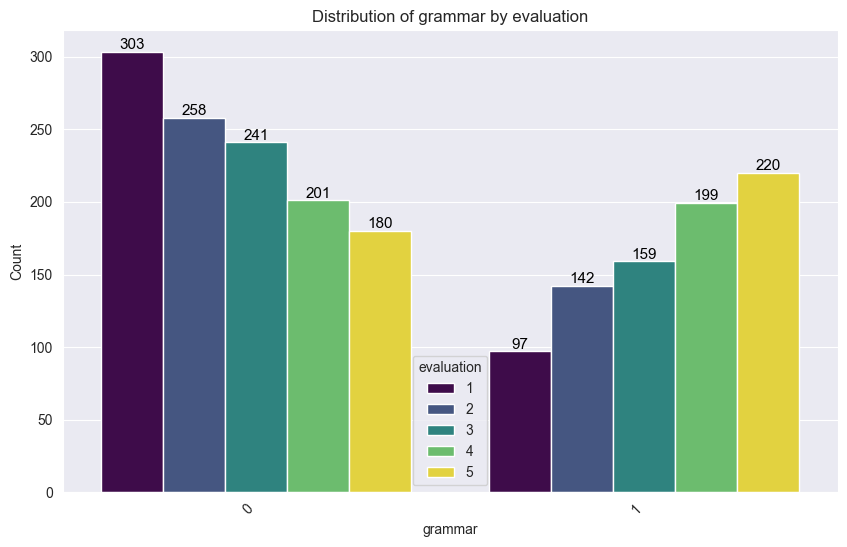

In [8]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='grammar')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="grammar")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable="grammar")
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="grammar")

Original P-value: 1.6263383960153328e-07
Bootstrap Mean P-value: 0.0001405245940499728
Relationship is significant in 2499/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1021182082174206
Effect Size: Moderate association
Significant association between rigor and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


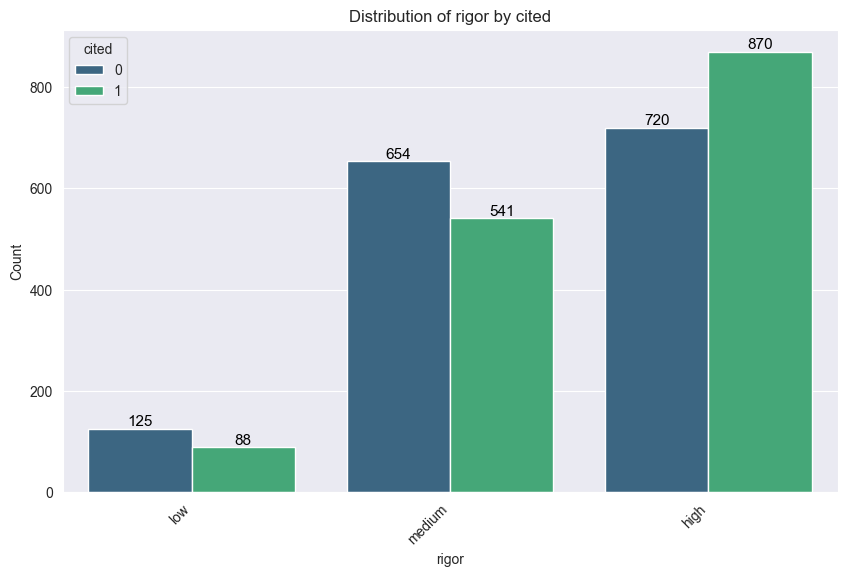

Original P-value: 7.0785552881818806e-71
Bootstrap Mean P-value: 9.201530524335332e-55
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2960156487064823
Effect Size: Moderate association
Significant association between rigor and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


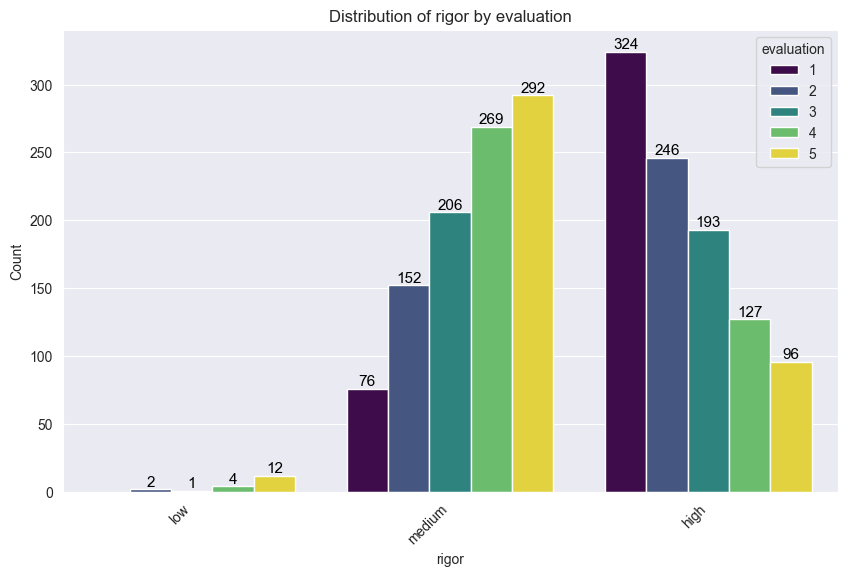

In [9]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='rigor')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="rigor")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='rigor')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="rigor")

Original P-value: 0.5521520254249231
Bootstrap Mean P-value: 0.4757568687949507
Relationship is significant in 224/2500 bootstrap samples.
Cramér's V (Effect Size): 0.01085835761664739
Effect Size: Weak association
No significant association between accessibility and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


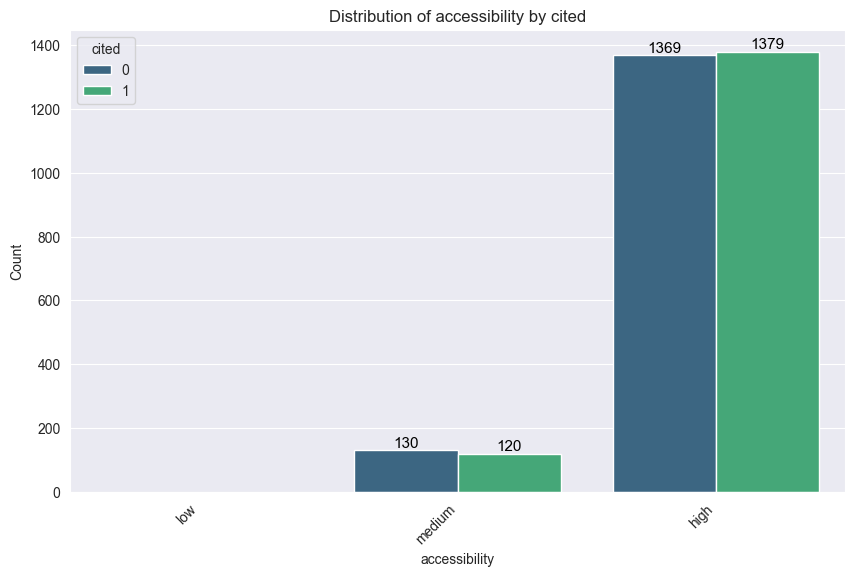

Original P-value: 0.1491445134929061
Bootstrap Mean P-value: 0.07274872836128579
Relationship is significant in 1688/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0548781030099254
Effect Size: Weak association
No significant association between accessibility and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


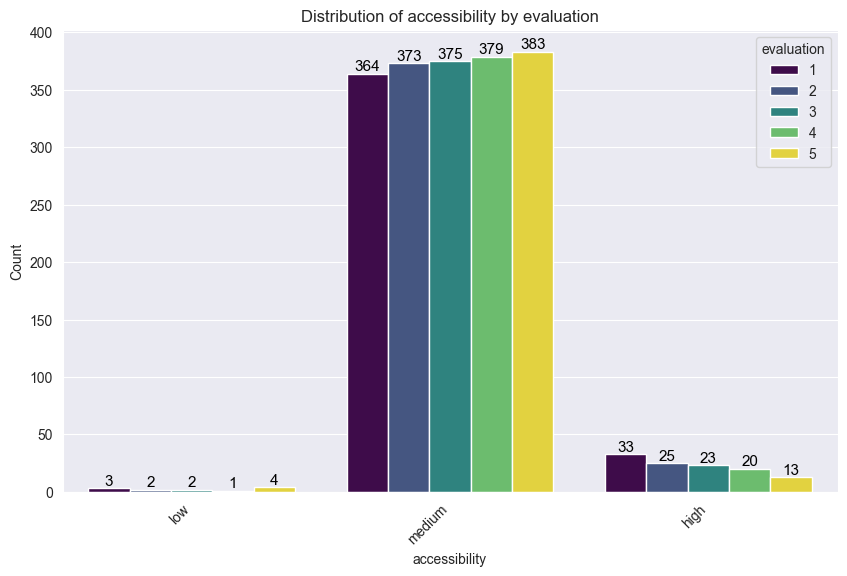

In [10]:
get_stat_significance(df_c19,target_variable='cited' ,categorical_variable='accessibility')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="accessibility")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='accessibility')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="accessibility")

Original P-value: 0.1491445134929061
Bootstrap Mean P-value: 0.07087739102499487
Relationship is significant in 1700/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0548781030099254
Effect Size: Weak association
No significant association between accessibility and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


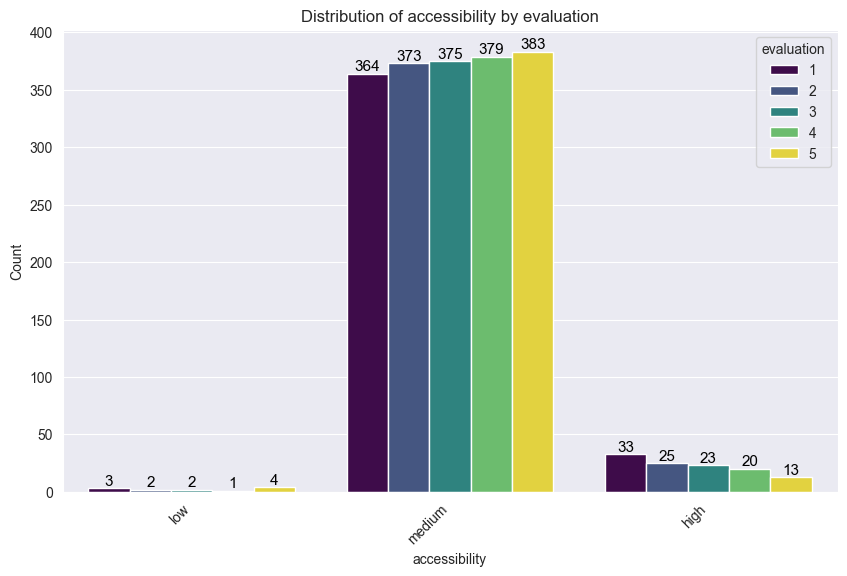

In [11]:
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='accessibility')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="accessibility")

In [12]:
df_c19['replicability'].value_counts()

replicability
1    1856
0    1142
Name: count, dtype: int64

Original P-value: 0.1880663143327544
Bootstrap Mean P-value: 0.2933758095843964
Relationship is significant in 654/2500 bootstrap samples.
Cramér's V (Effect Size): 0.024040638968216312
Effect Size: Weak association
No significant association between replicability and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


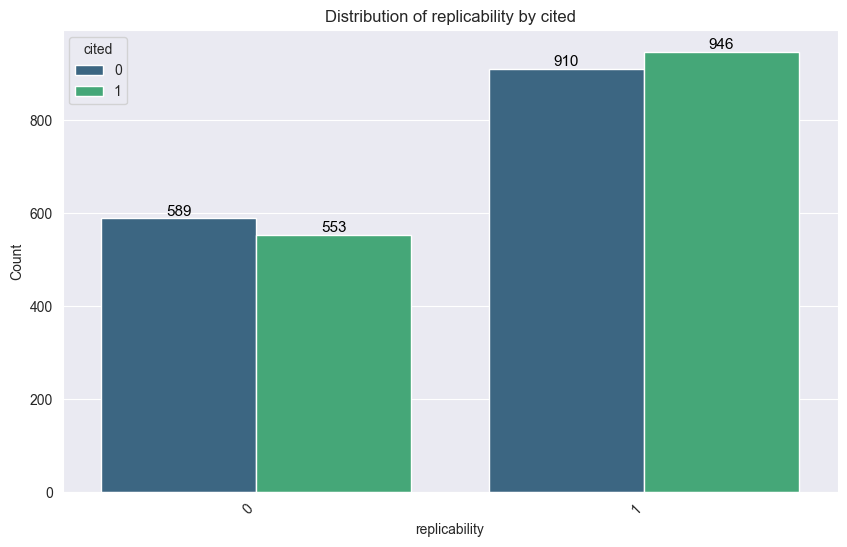

Original P-value: 7.971471796954155e-44
Bootstrap Mean P-value: 6.347940262947174e-30
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.32232094984252535
Effect Size: Strong association
Significant association between replicability and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


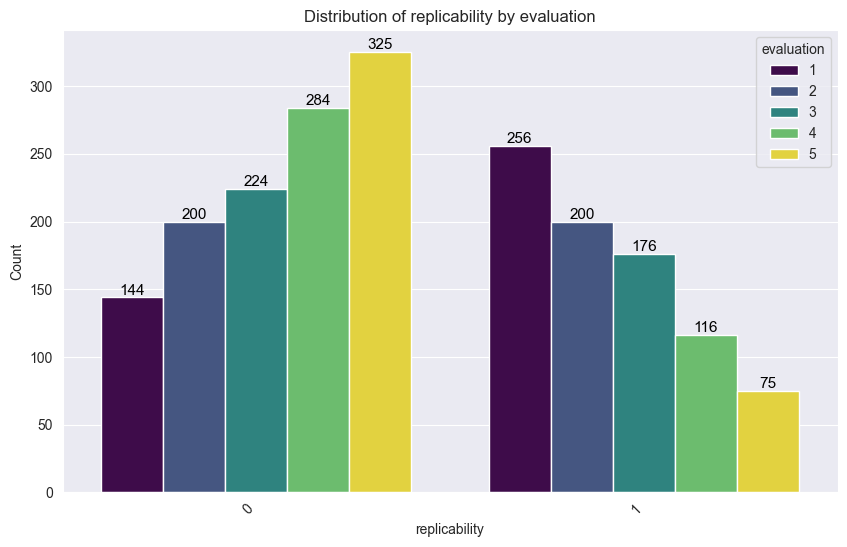

In [13]:
get_stat_significance(df_c19, target_variable='cited' ,categorical_variable='replicability')
plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable="replicability")
get_stat_significance(df_m17,target_variable='evaluation' ,categorical_variable='replicability')
plot_categorical_distribution(df_m17, target_variable="evaluation", categorical_variable="replicability")

In [14]:
# for col in df.columns:
#     get_stat_significance(col)

In [15]:
df_m17.head()

,title,abstract,science_field,collaborators,journal_name,evaluation,novelty,rigor,grammar,replicability,...,exploratory_research,focus_groups,interviews,mixed_methods,observation,qualitative_research,quantitative_research,questionnaires,secondary_research,survey_methodology
0,The making of a socialist underworld: people o...,This text depicts the mechanisms that created ...,60101.0,"Dušková, Lucie",European Review of History/Revue Europeenne d&...,1,medium,high,0,0,...,0,0,0,0,0,0,0,0,0,0
1,Selective Translation Complex Profiling Reveal...,Translational control targeting the initiation...,10608.0,"Wagner, Susan:Herrmannová, Anna:Hronová, Vladi...",Molecular Cell,1,high,high,0,1,...,0,0,0,1,0,0,0,0,0,0
2,Layered Black Phosphorus: Strongly Anisotropic...,"Layered elemental materials, such as black pho...",0.0,"Sofer, Zdeněk:Sedmidubský, David:Huber, Štěpán...",Angewandte Chemie-International Edition,1,high,high,1,1,...,0,0,0,0,0,0,0,0,0,0
3,Geochemical Modelling of Igneous Processes - P...,The aim of this book is to unlock the power of...,0.0,"Janoušek, Vojtěch: Moyen, Jean-Francois: Marti...",Geochemical Modelling of Igneous Processes - P...,1,medium,medium,0,0,...,0,0,0,0,0,0,0,0,0,0
4,Plant diversity increases with the strength of...,Theory predicts that higher biodiversity in th...,40102.0,"Janík, David:Král, Kamil:Vrška, Tomáš",Science,1,high,high,0,1,...,1,0,0,1,0,1,1,0,0,0


now in rigor
Original P-value: 1.6263383960153328e-07
Bootstrap Mean P-value: 0.0001491197701210262
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1021182082174206
Effect Size: Moderate association
Significant association between rigor and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


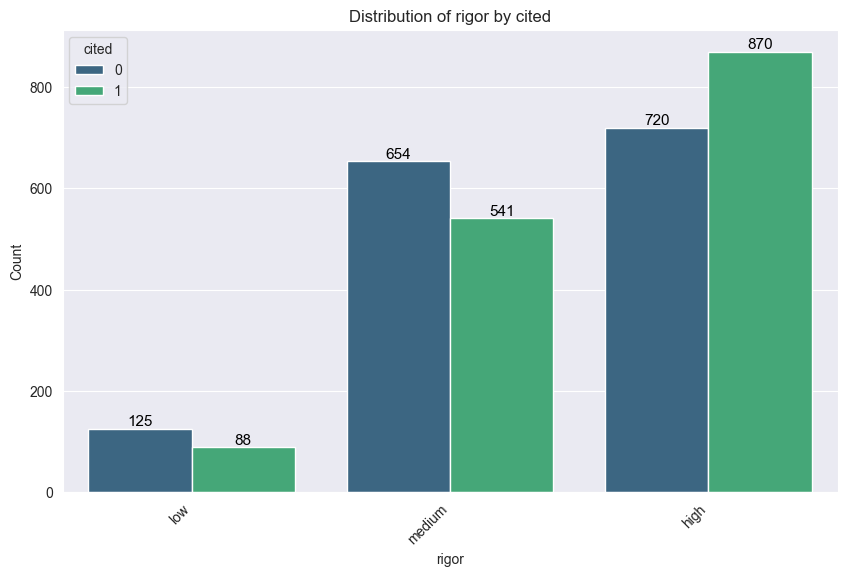

now in novelty
Original P-value: 0.0008586505323392688
Bootstrap Mean P-value: 0.014675764398648311
Relationship is significant in 2326/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06862875226025426
Effect Size: Weak association
Significant association between novelty and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


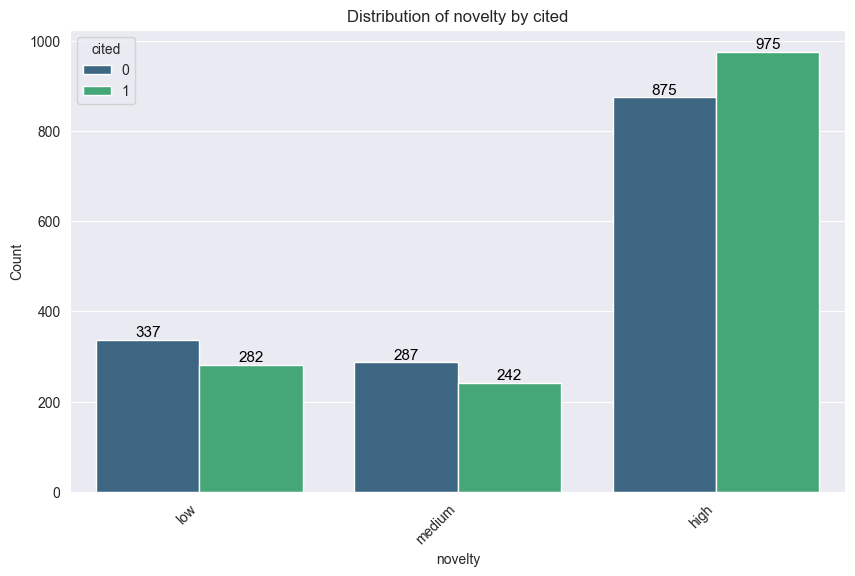

now in grammar
Original P-value: 0.9467455187293435
Bootstrap Mean P-value: 0.5402278985921546
Relationship is significant in 109/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0012198968752529413
Effect Size: Weak association
No significant association between grammar and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


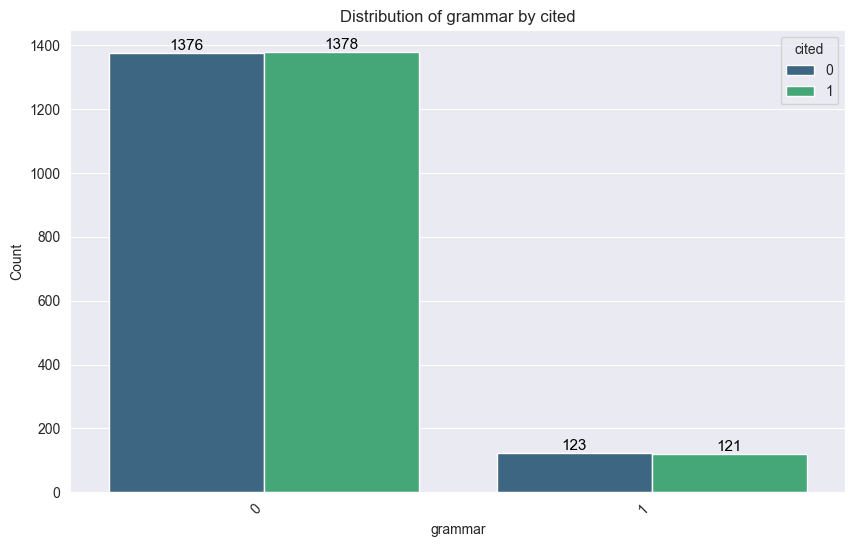

now in replicability
Original P-value: 0.1880663143327544
Bootstrap Mean P-value: 0.28845189710928104
Relationship is significant in 660/2500 bootstrap samples.
Cramér's V (Effect Size): 0.024040638968216312
Effect Size: Weak association
No significant association between replicability and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


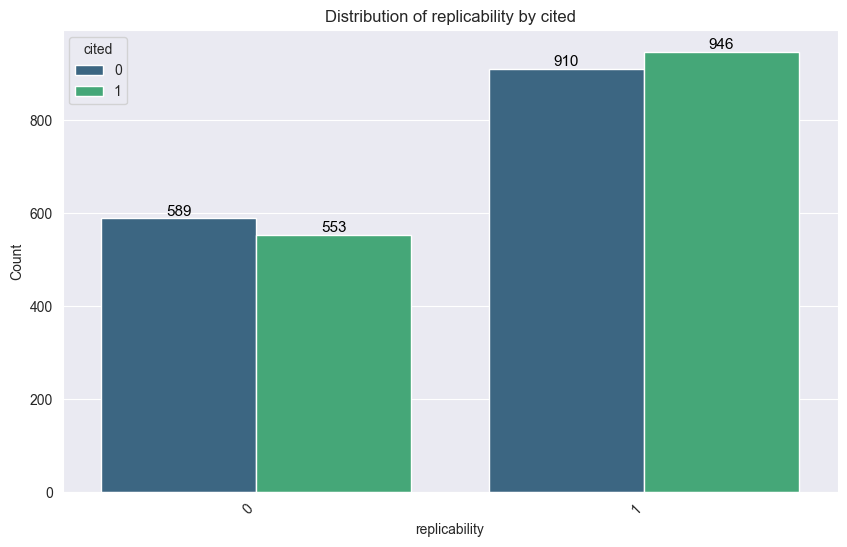

now in accessibility
Original P-value: 0.5521520254249231
Bootstrap Mean P-value: 0.4657995895651202
Relationship is significant in 231/2500 bootstrap samples.
Cramér's V (Effect Size): 0.01085835761664739
Effect Size: Weak association
No significant association between accessibility and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


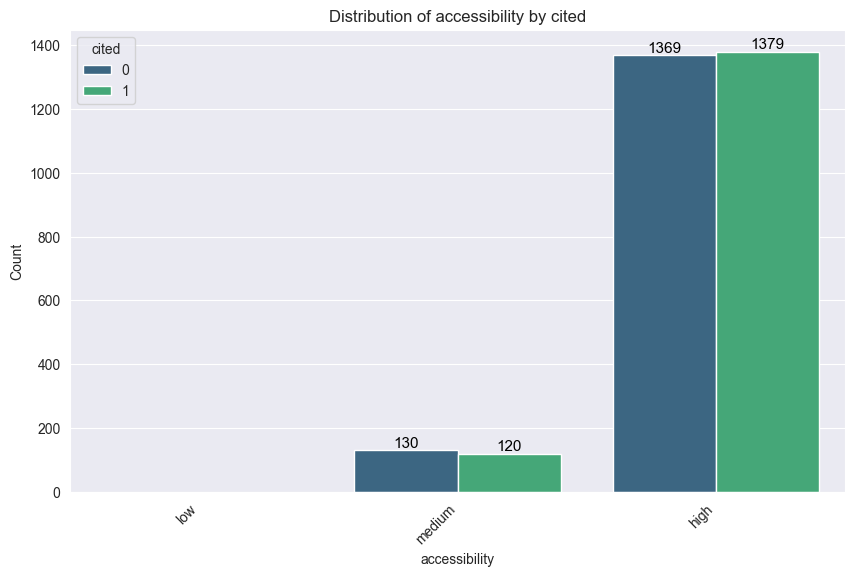

now in mathematics
Original P-value: 0.005435799120309171
Bootstrap Mean P-value: 0.05427106502720277
Relationship is significant in 1940/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0507726496537452
Effect Size: Weak association
Significant association between mathematics and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


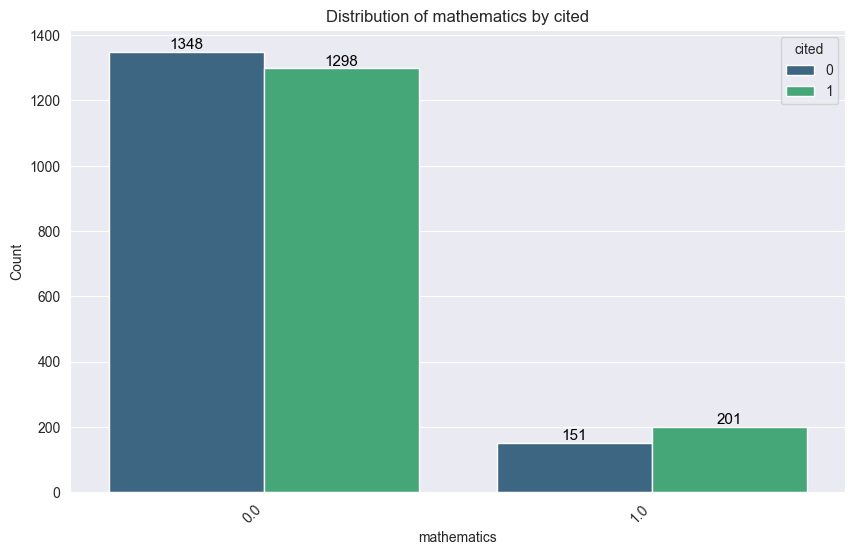

now in computer_sciences
Original P-value: 4.967147887614575e-06
Bootstrap Mean P-value: 0.0009447010014863842
Relationship is significant in 2491/2500 bootstrap samples.
Cramér's V (Effect Size): 0.08339428903781594
Effect Size: Weak association
Significant association between computer_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


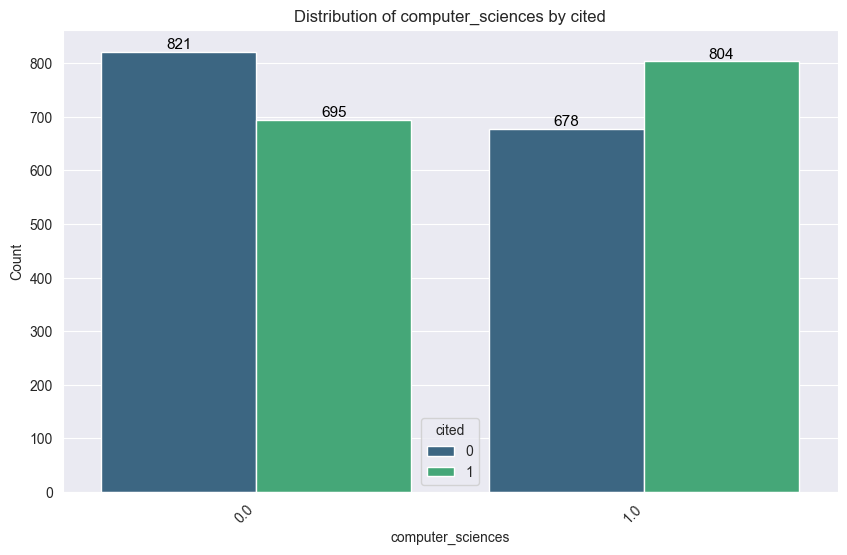

now in physical_sciences
Original P-value: 7.921146558572942e-12
Bootstrap Mean P-value: 1.7185098786890028e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1249217868244114
Effect Size: Moderate association
Significant association between physical_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


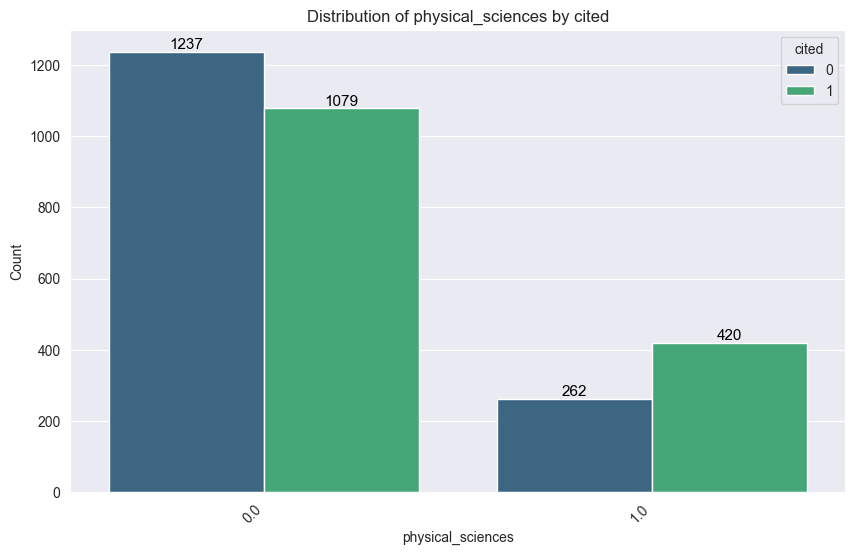

now in chemical_sciences
Original P-value: 1.0344426359606074e-14
Bootstrap Mean P-value: 2.2330316851161042e-08
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1412673053149002
Effect Size: Moderate association
Significant association between chemical_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


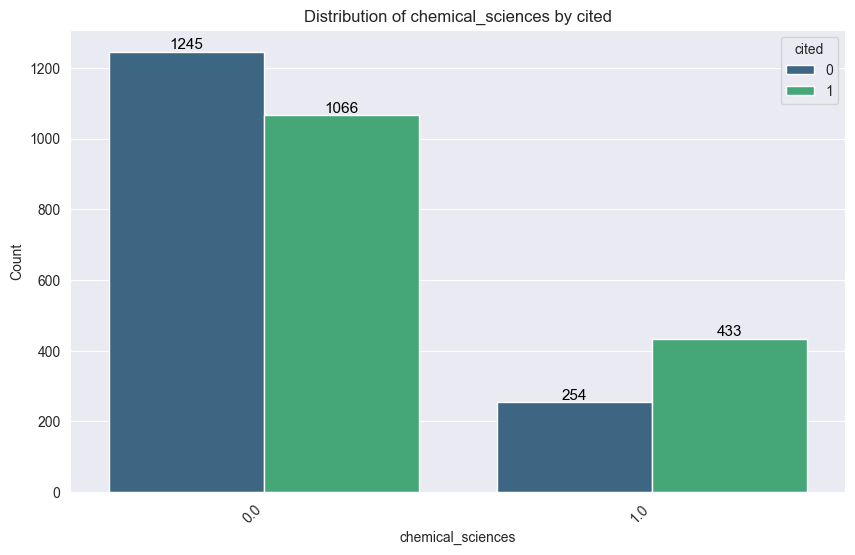

now in earth_and_related_sciences
Original P-value: 4.846219278452379e-08
Bootstrap Mean P-value: 8.257408703153313e-05
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.09966144488088396
Effect Size: Weak association
Significant association between earth_and_related_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


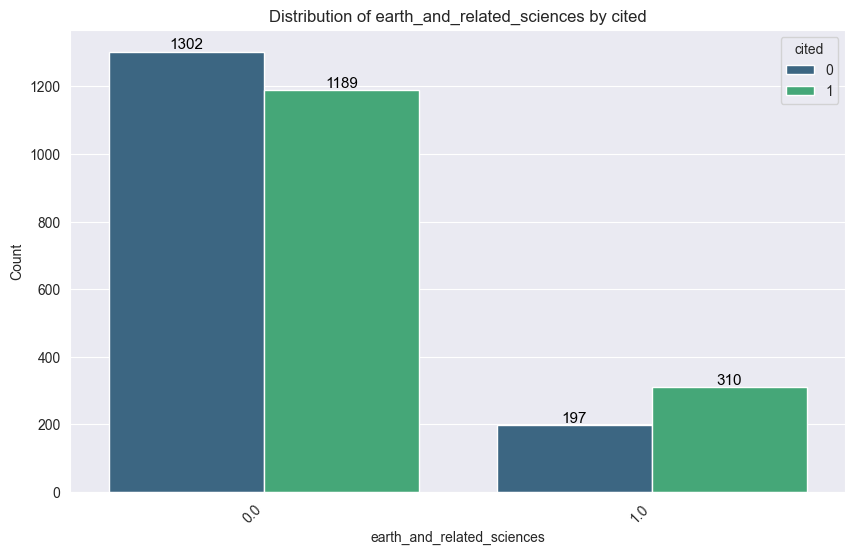

now in biological_sciences
Original P-value: 2.3094724156967882e-15
Bootstrap Mean P-value: 5.452647477842386e-09
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.14471060154698734
Effect Size: Moderate association
Significant association between biological_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


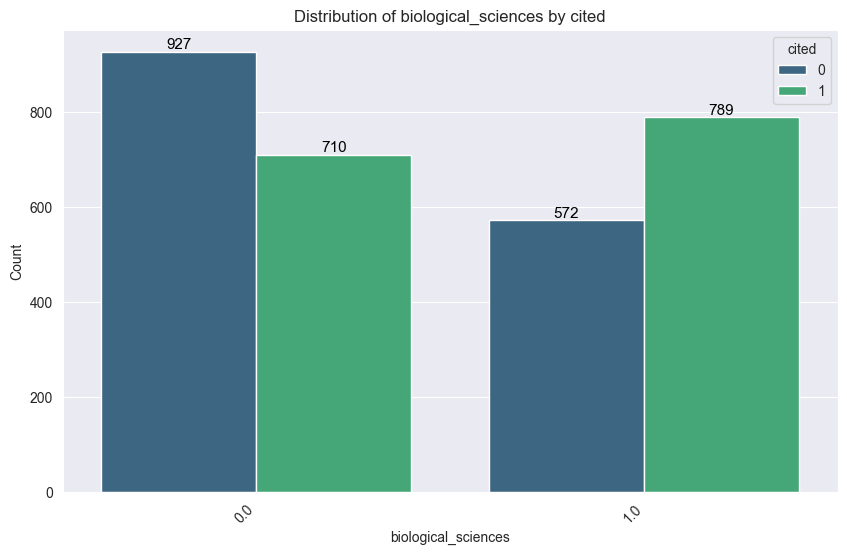

now in other_natural_sciences
Original P-value: 1.9910860856943468e-08
Bootstrap Mean P-value: 0.00011837425017583914
Relationship is significant in 2499/2500 bootstrap samples.
Cramér's V (Effect Size): 0.10250893915101655
Effect Size: Moderate association
Significant association between other_natural_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


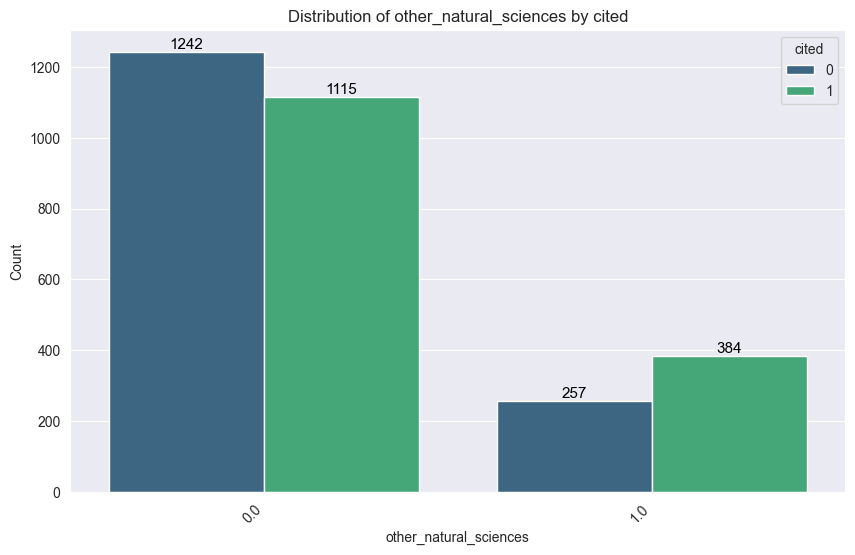

now in civil_engineering
Original P-value: 0.020310929535942168
Bootstrap Mean P-value: 0.09740310277987001
Relationship is significant in 1579/2500 bootstrap samples.
Cramér's V (Effect Size): 0.04238145447344224
Effect Size: Weak association
Significant association between civil_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


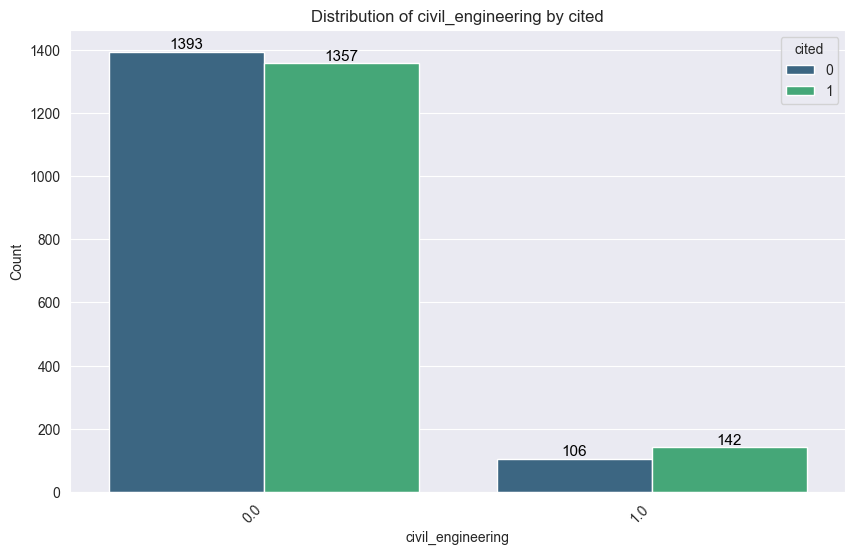

now in electrical_engineering
Original P-value: 0.05129940965875685
Bootstrap Mean P-value: 0.1553736994289471
Relationship is significant in 1242/2500 bootstrap samples.
Cramér's V (Effect Size): 0.03559496658263964
Effect Size: Weak association
No significant association between electrical_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


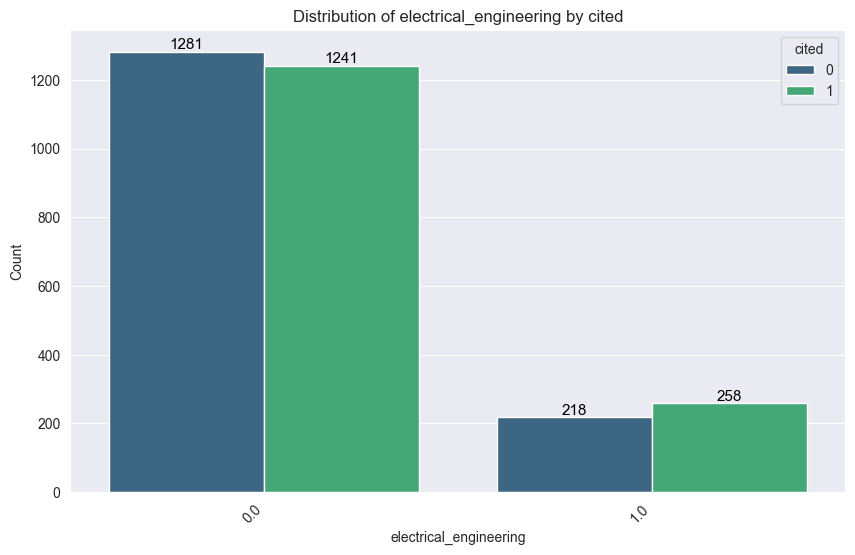

now in mechanical_engineering
Original P-value: 6.333588441014675e-06
Bootstrap Mean P-value: 0.0013666356628045794
Relationship is significant in 2491/2500 bootstrap samples.
Cramér's V (Effect Size): 0.08245856755539979
Effect Size: Weak association
Significant association between mechanical_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


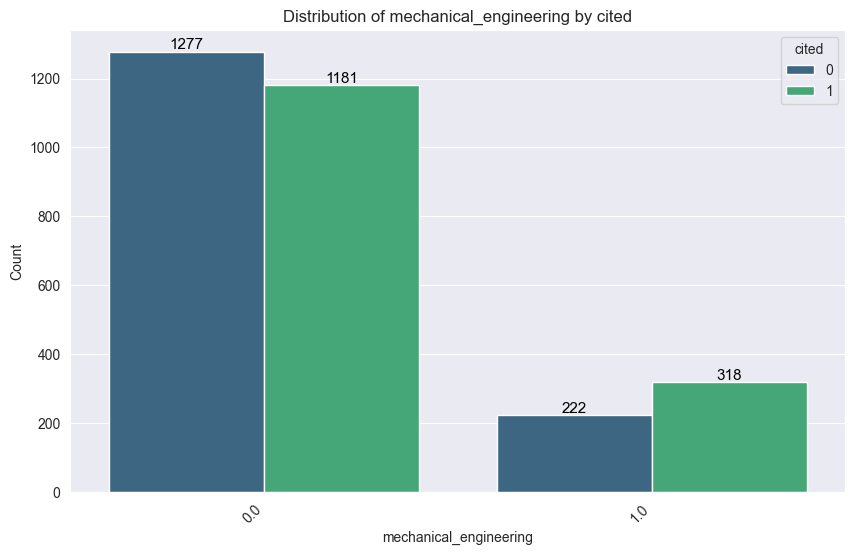

now in chemical_engineering
Original P-value: 9.468718878426198e-09
Bootstrap Mean P-value: 2.8285295935813938e-05
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.10483218517759268
Effect Size: Moderate association
Significant association between chemical_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


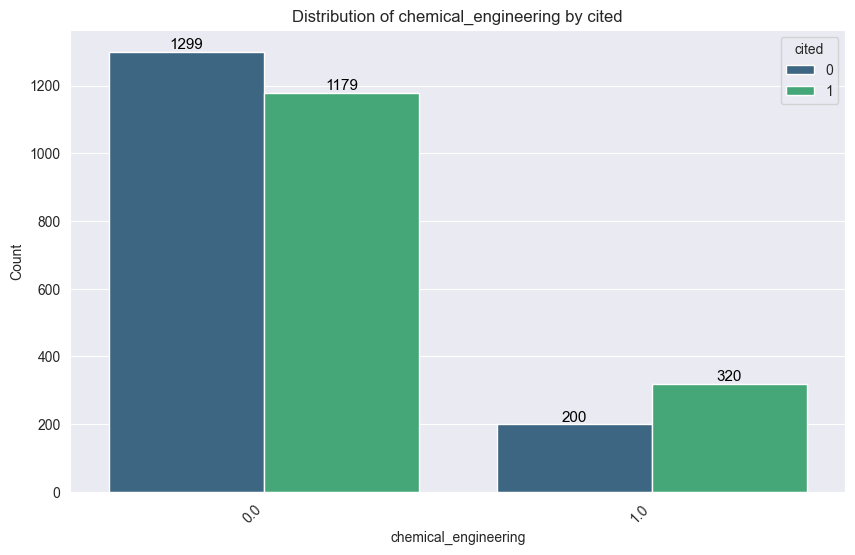

now in materials_engineering
Original P-value: 0.010480229018045831
Bootstrap Mean P-value: 0.07611203168611681
Relationship is significant in 1790/2500 bootstrap samples.
Cramér's V (Effect Size): 0.046746692839686334
Effect Size: Weak association
Significant association between materials_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


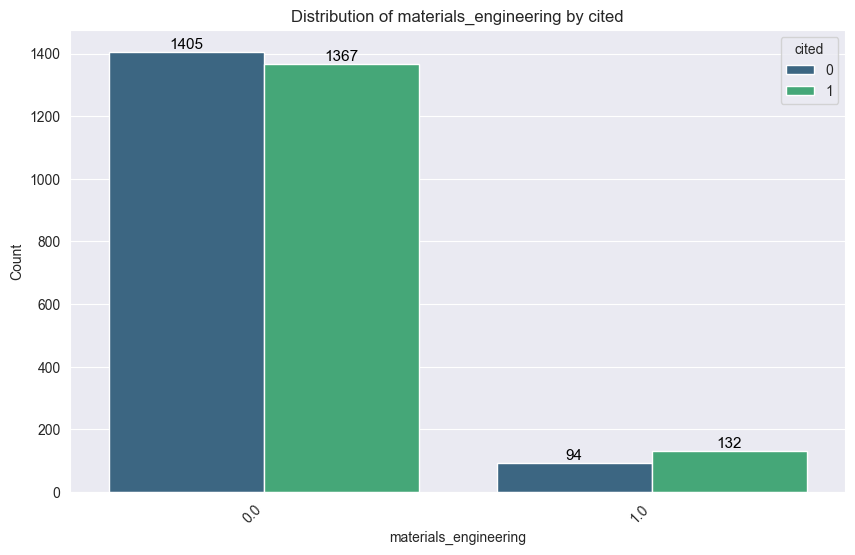

now in environmental_engineering
Original P-value: 0.0044194509436976245
Bootstrap Mean P-value: 0.044362603932016756
Relationship is significant in 2018/2500 bootstrap samples.
Cramér's V (Effect Size): 0.051988155322342765
Effect Size: Weak association
Significant association between environmental_engineering and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


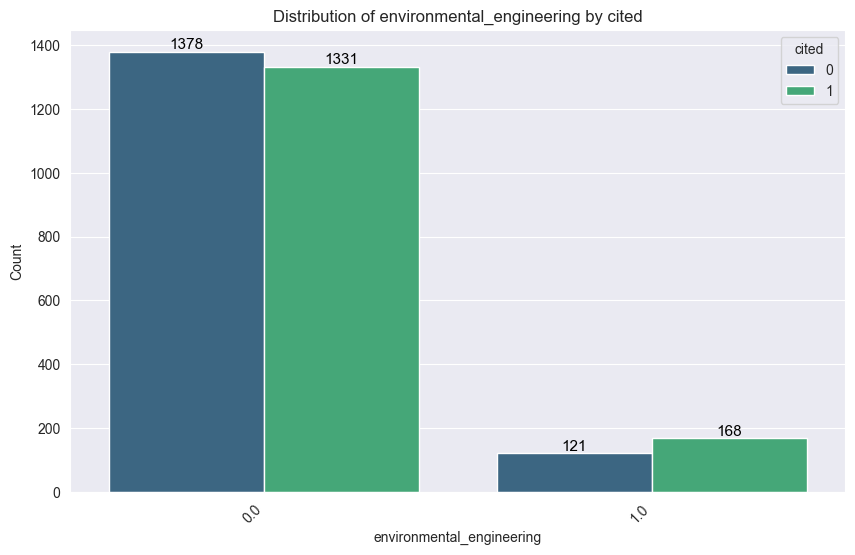

now in evironmental_biotechnology
Original P-value: 5.408174178301266e-07
Bootstrap Mean P-value: 0.0006131951113519806
Relationship is significant in 2494/2500 bootstrap samples.
Cramér's V (Effect Size): 0.09152273283638507
Effect Size: Weak association
Significant association between evironmental_biotechnology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


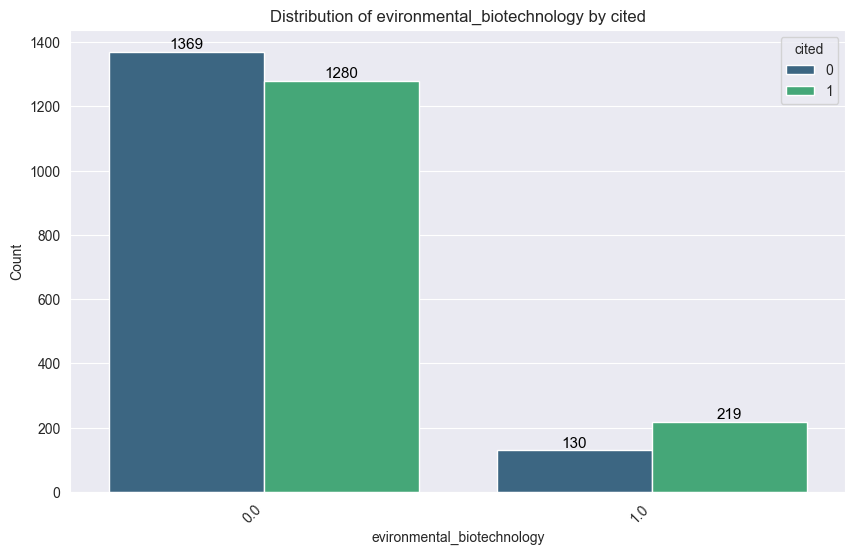

now in industrial_biotechnology
Original P-value: 8.327541718460593e-09
Bootstrap Mean P-value: 5.5719266753811036e-05
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.10522868405666636
Effect Size: Moderate association
Significant association between industrial_biotechnology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


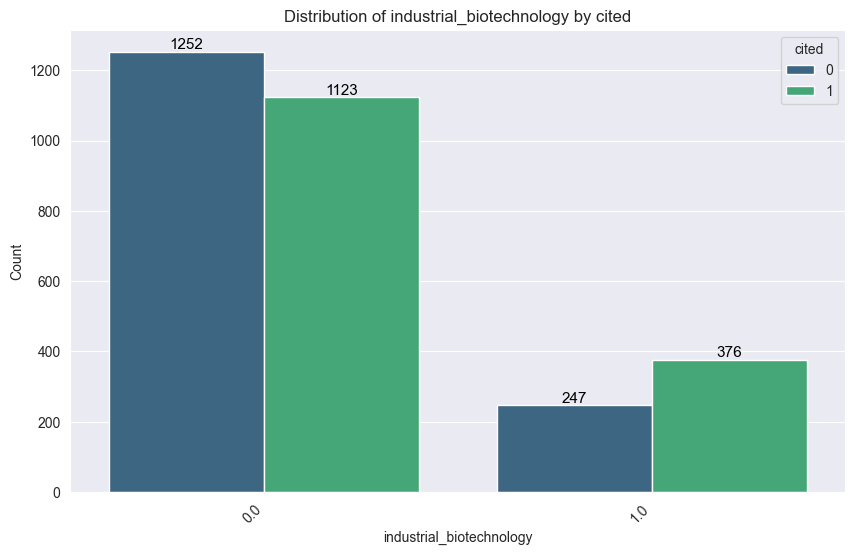

now in nano-technology
Original P-value: 0.010826403654746542
Bootstrap Mean P-value: 0.07052219675731307
Relationship is significant in 1800/2500 bootstrap samples.
Cramér's V (Effect Size): 0.04654003093688537
Effect Size: Weak association
Significant association between nano-technology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


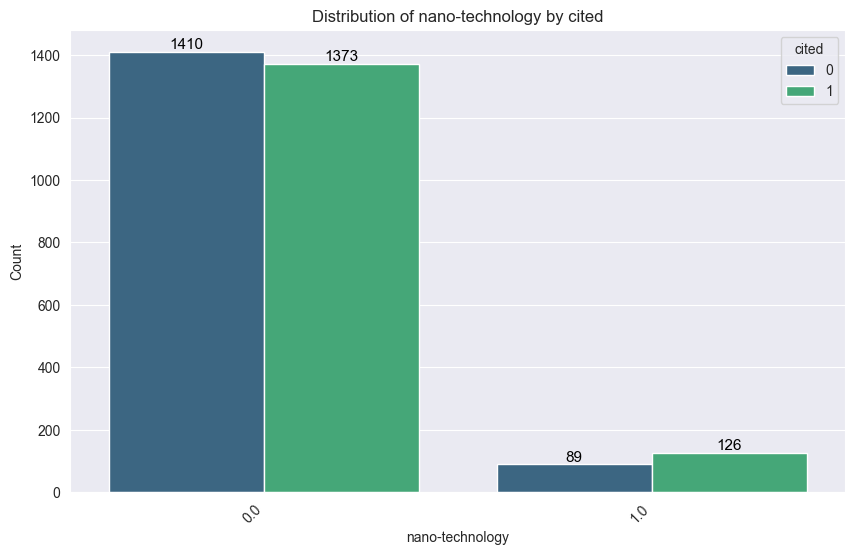

now in other_engineering_and_technologies
Original P-value: 0.08072852808452795
Bootstrap Mean P-value: 0.1961613767594241
Relationship is significant in 1039/2500 bootstrap samples.
Cramér's V (Effect Size): 0.03189675067058281
Effect Size: Weak association
No significant association between other_engineering_and_technologies and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


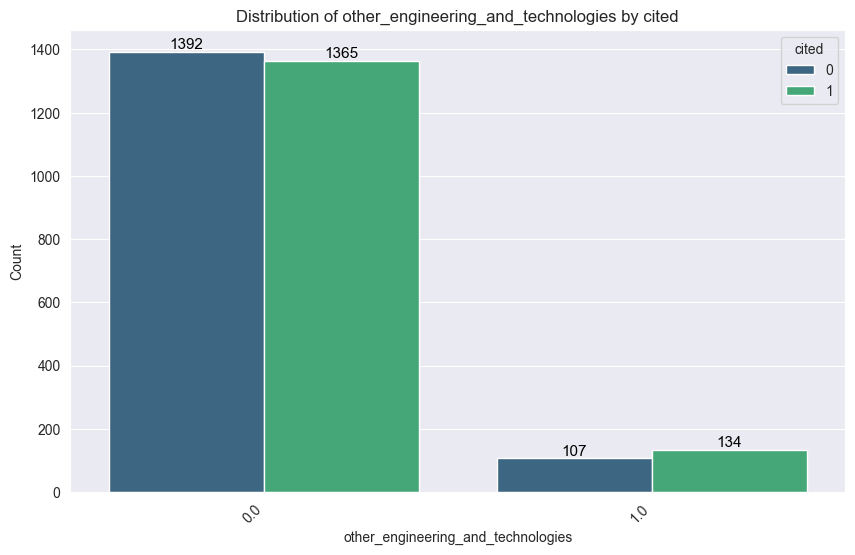

now in basic_medicine
Original P-value: 3.263381969650772e-17
Bootstrap Mean P-value: 5.310367686451332e-10
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1540842873008556
Effect Size: Moderate association
Significant association between basic_medicine and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


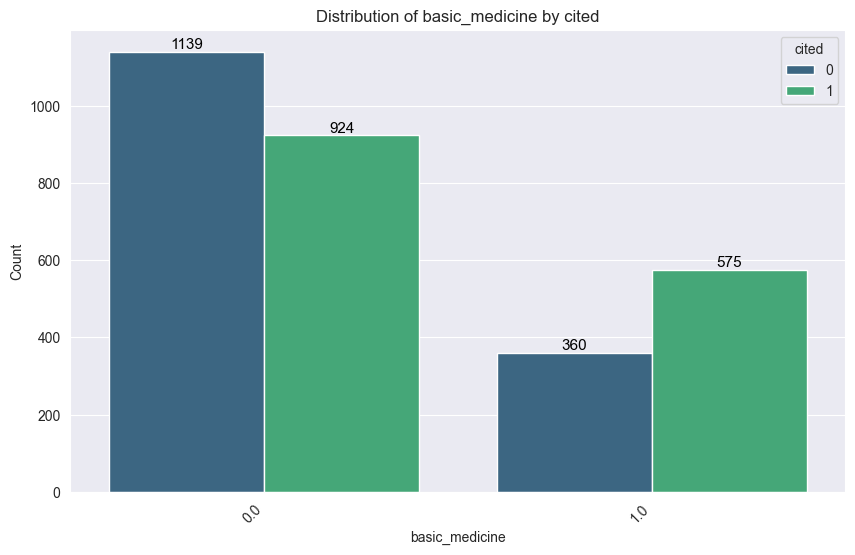

now in clinical_medicine
Original P-value: 5.1643619203403903e-05
Bootstrap Mean P-value: 0.004738486034034791
Relationship is significant in 2452/2500 bootstrap samples.
Cramér's V (Effect Size): 0.07393179791429753
Effect Size: Weak association
Significant association between clinical_medicine and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


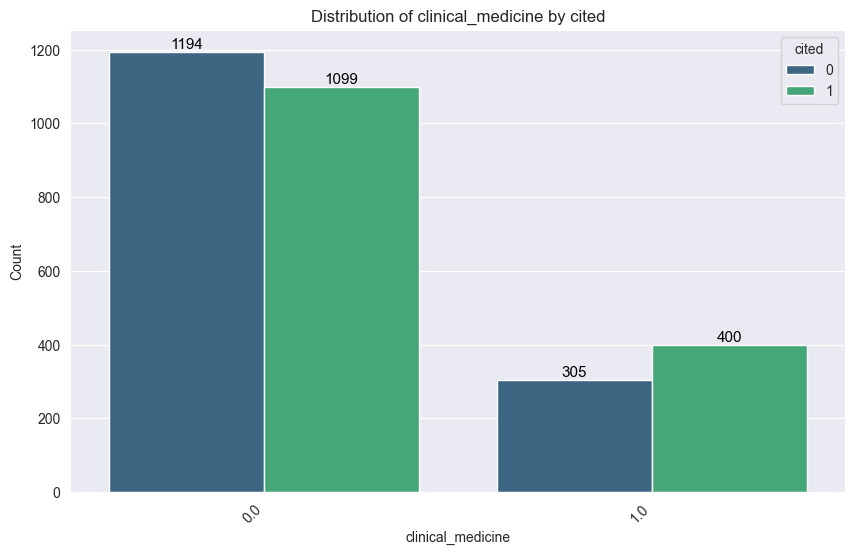

now in health_sciences
Original P-value: 0.0036519613227176785
Bootstrap Mean P-value: 0.039419266977149287
Relationship is significant in 2068/2500 bootstrap samples.
Cramér's V (Effect Size): 0.053087588065230985
Effect Size: Weak association
Significant association between health_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


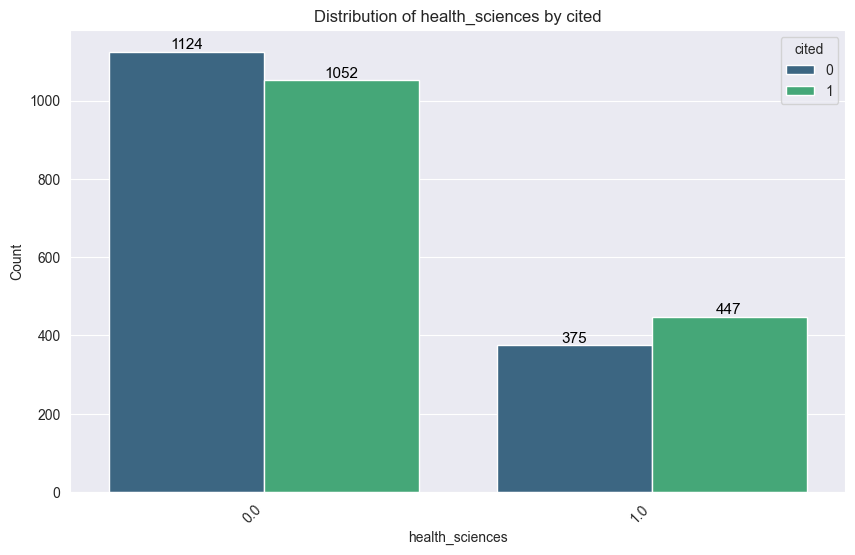

now in medical_biotechnology
Original P-value: 1.212997020405208e-06
Bootstrap Mean P-value: 0.0003418237344251573
Relationship is significant in 2498/2500 bootstrap samples.
Cramér's V (Effect Size): 0.08864198227411407
Effect Size: Weak association
Significant association between medical_biotechnology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


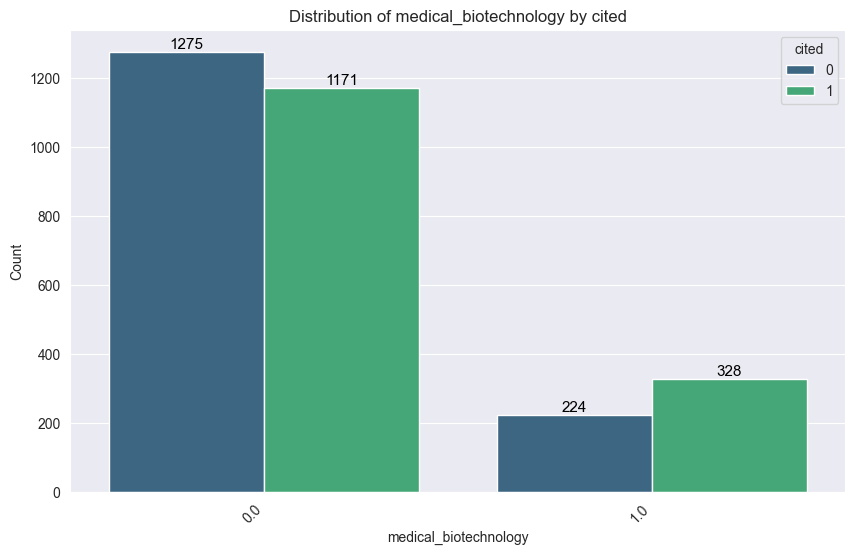

now in other_medical_sciences
Original P-value: 9.751951295315822e-07
Bootstrap Mean P-value: 0.000625085685976302
Relationship is significant in 2495/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0894287047940681
Effect Size: Weak association
Significant association between other_medical_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


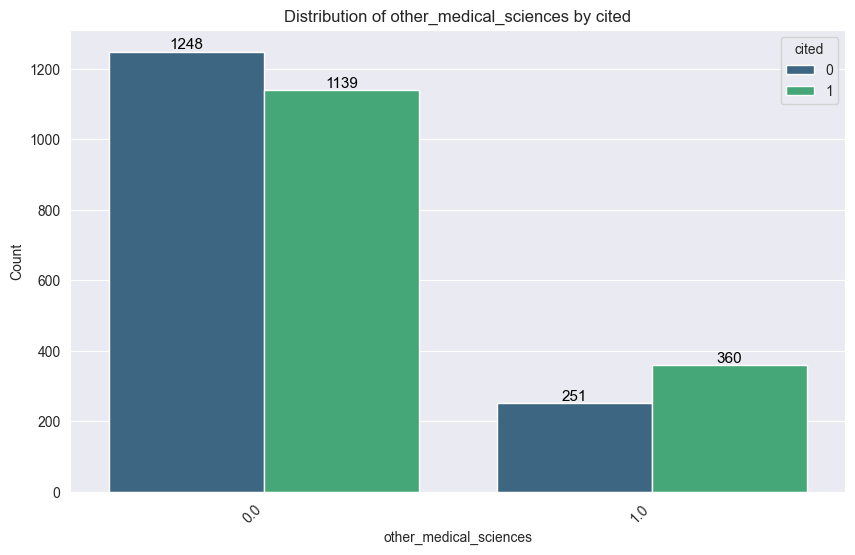

now in agriculture_forestry_and_fisheries
Original P-value: 5.78024357540128e-09
Bootstrap Mean P-value: 2.9407278628900413e-05
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.10634830452887611
Effect Size: Moderate association
Significant association between agriculture_forestry_and_fisheries and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


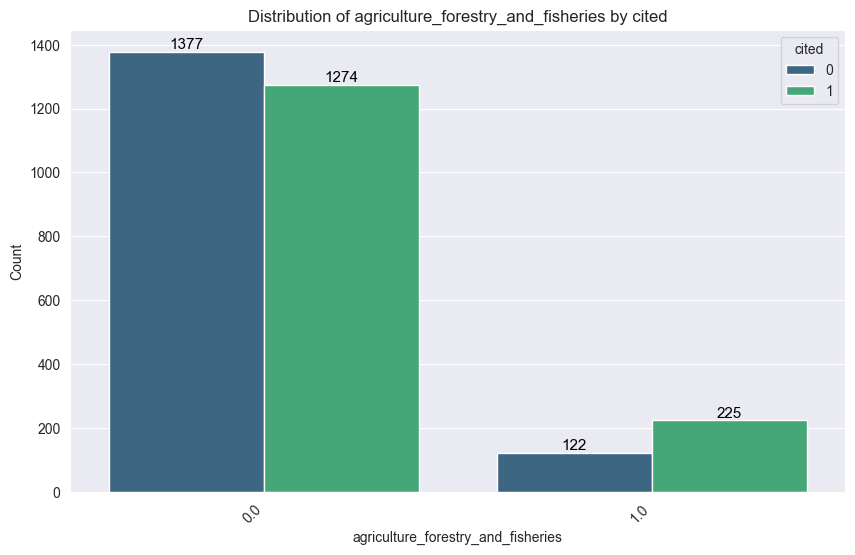

now in animal_and_dairy_science
Original P-value: 4.485335395623643e-11
Bootstrap Mean P-value: 1.3059081284751854e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.12030334833193444
Effect Size: Moderate association
Significant association between animal_and_dairy_science and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


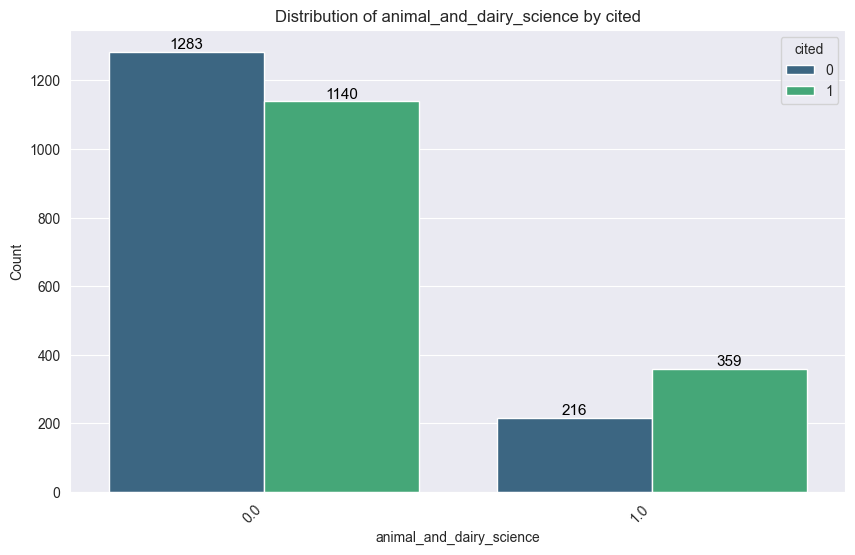

now in veterinary_science
Original P-value: 8.398252997817666e-13
Bootstrap Mean P-value: 6.0389867764348e-07
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1306661421144256
Effect Size: Moderate association
Significant association between veterinary_science and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


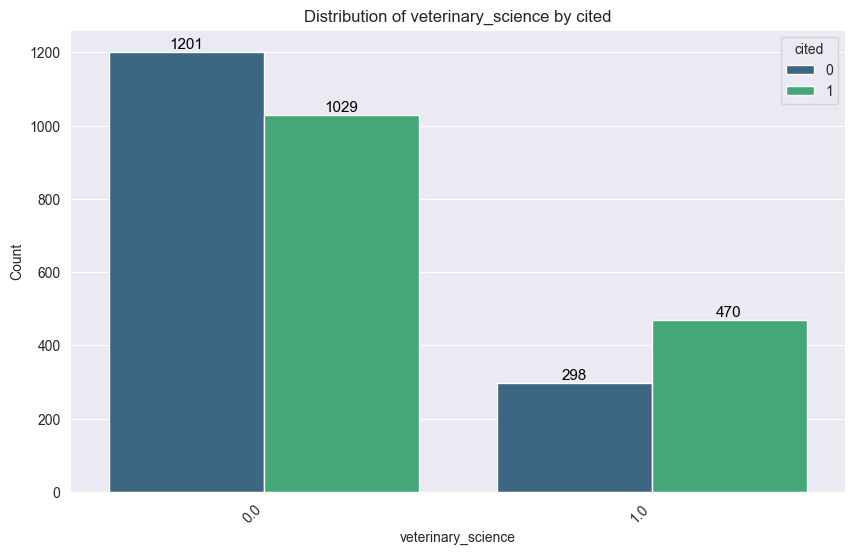

now in agricultural_biotechnology
Original P-value: 0.0033675548168735758
Bootstrap Mean P-value: 0.035588095845494314
Relationship is significant in 2098/2500 bootstrap samples.
Cramér's V (Effect Size): 0.05354913036918415
Effect Size: Weak association
Significant association between agricultural_biotechnology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


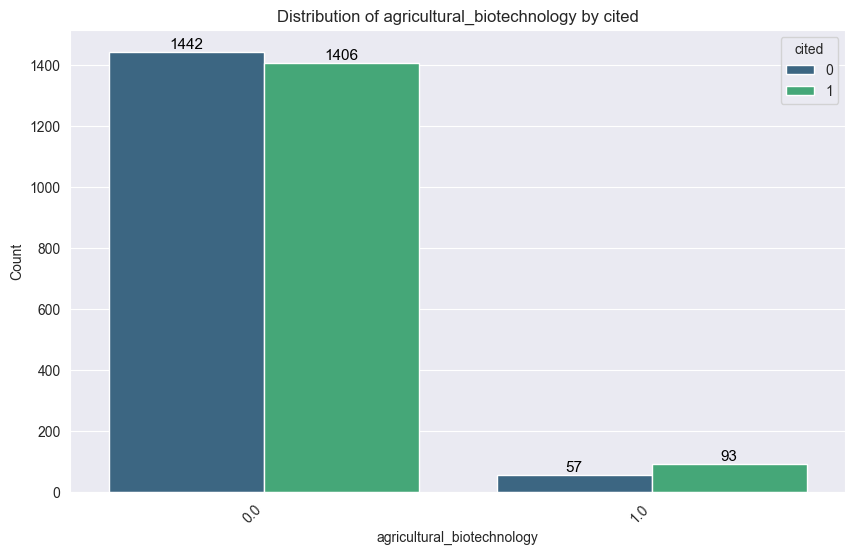

now in other_agricultural_sciences
Original P-value: 0.00043039923263464764
Bootstrap Mean P-value: 0.011026302025397974
Relationship is significant in 2366/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0643004435831885
Effect Size: Weak association
Significant association between other_agricultural_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


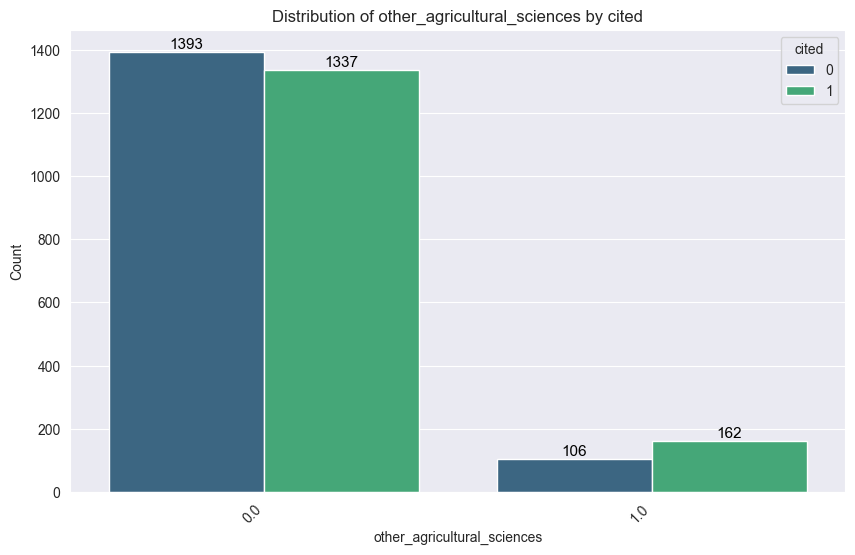

now in psychology
Original P-value: 0.0018658414291885576
Bootstrap Mean P-value: 0.026546652208368278
Relationship is significant in 2197/2500 bootstrap samples.
Cramér's V (Effect Size): 0.05681403567652098
Effect Size: Weak association
Significant association between psychology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


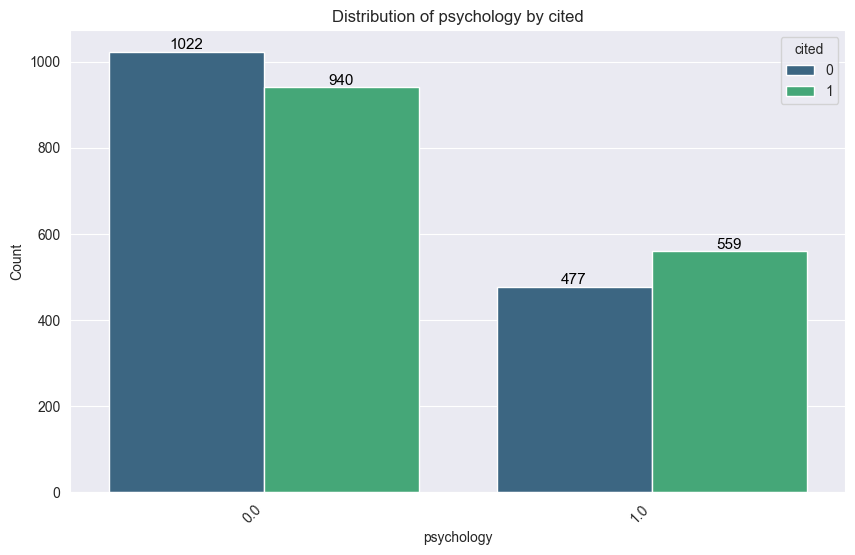

now in economics_and_business
Original P-value: 0.9595847462123431
Bootstrap Mean P-value: 0.5243087279962583
Relationship is significant in 111/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0009254975539733546
Effect Size: Weak association
No significant association between economics_and_business and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


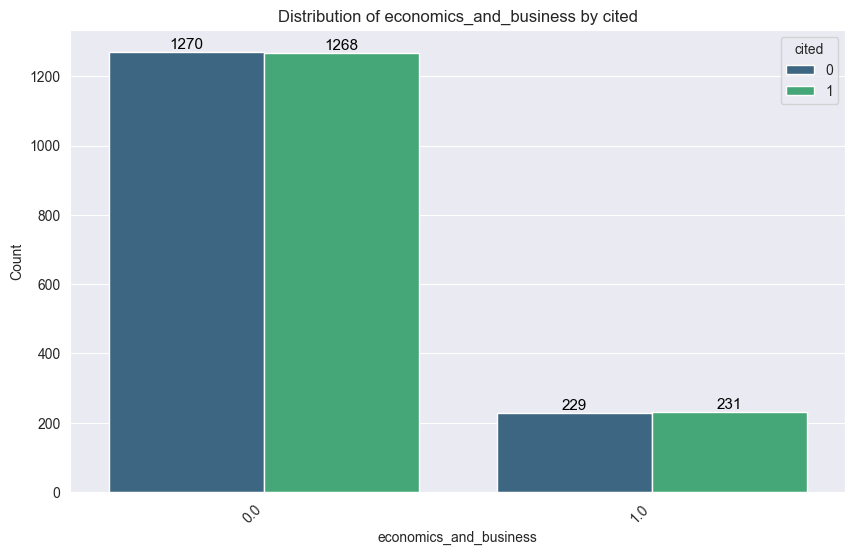

now in education
Original P-value: 0.11896724395481026
Bootstrap Mean P-value: 0.24327116461134474
Relationship is significant in 887/2500 bootstrap samples.
Cramér's V (Effect Size): 0.028475056580560015
Effect Size: Weak association
No significant association between education and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


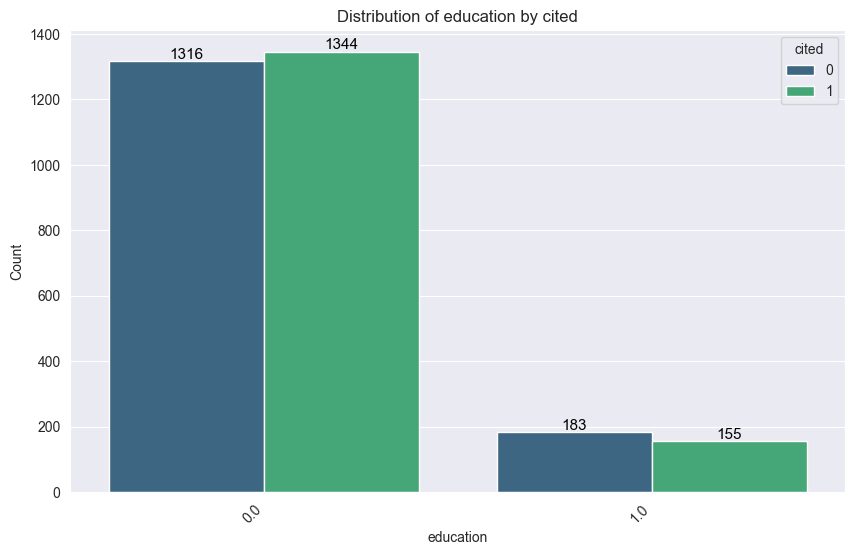

now in sociology
Original P-value: 0.930091294677
Bootstrap Mean P-value: 0.525953138175639
Relationship is significant in 99/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0016022570549363401
Effect Size: Weak association
No significant association between sociology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


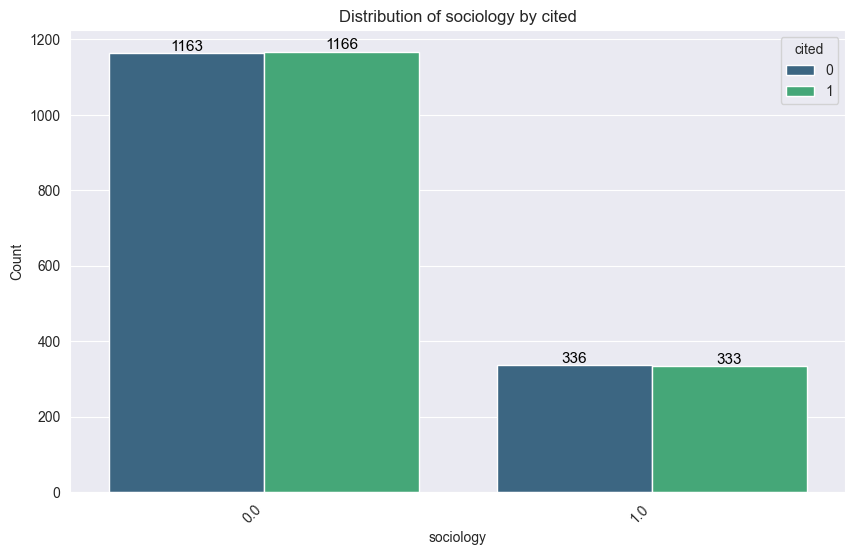

now in law
Original P-value: 0.014217337004710687
Bootstrap Mean P-value: 0.08184959069483791
Relationship is significant in 1723/2500 bootstrap samples.
Cramér's V (Effect Size): 0.04477709316159028
Effect Size: Weak association
Significant association between law and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


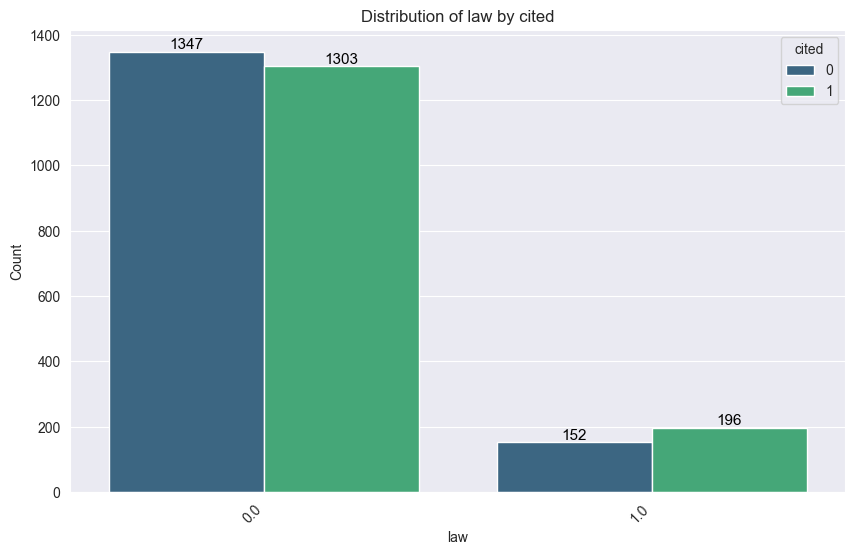

now in political_science
Original P-value: 0.5065396350949756
Bootstrap Mean P-value: 0.45786405461878976
Relationship is significant in 256/2500 bootstrap samples.
Cramér's V (Effect Size): 0.012131268867319848
Effect Size: Weak association
No significant association between political_science and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


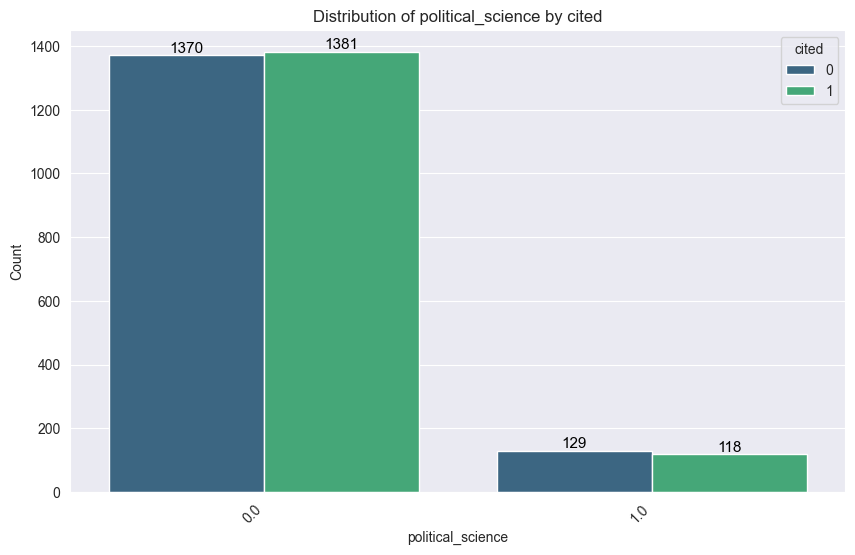

now in social_and_economic_geography
Original P-value: 0.6736710927369942
Bootstrap Mean P-value: 0.49673465889669577
Relationship is significant in 176/2500 bootstrap samples.
Cramér's V (Effect Size): 0.007691037334940869
Effect Size: Weak association
No significant association between social_and_economic_geography and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


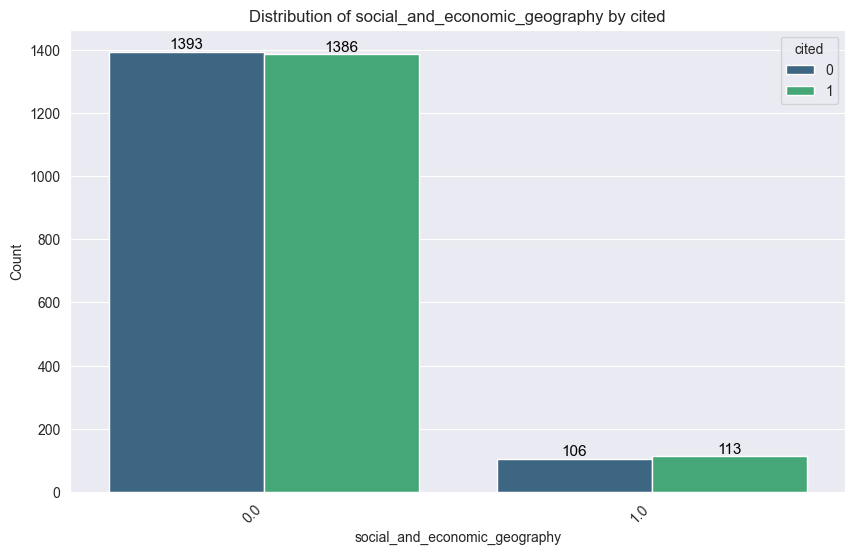

now in media_and_communications
Original P-value: 0.32239456429700736
Bootstrap Mean P-value: 0.37579806779008906
Relationship is significant in 414/2500 bootstrap samples.
Cramér's V (Effect Size): 0.01807263716268345
Effect Size: Weak association
No significant association between media_and_communications and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


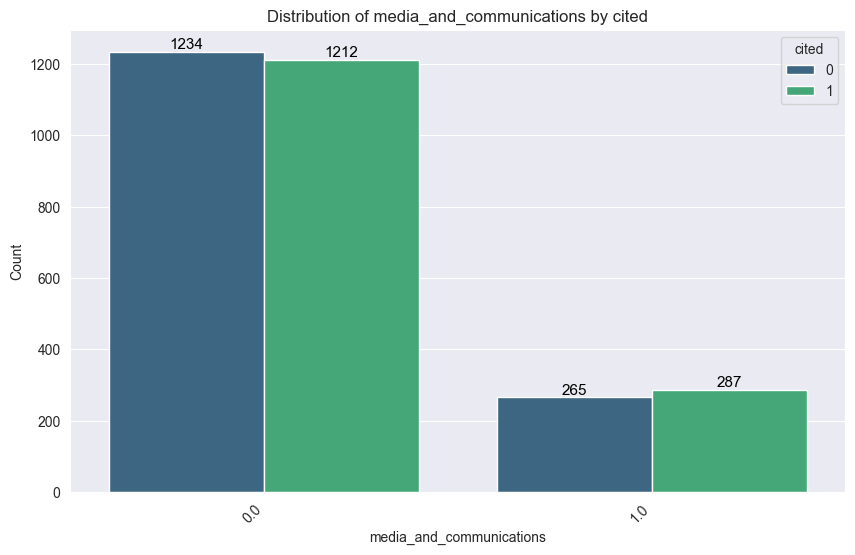

now in other_social_sciences
Original P-value: 0.15023568127802642
Bootstrap Mean P-value: 0.26766389467027524
Relationship is significant in 731/2500 bootstrap samples.
Cramér's V (Effect Size): 0.02627569900064848
Effect Size: Weak association
No significant association between other_social_sciences and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


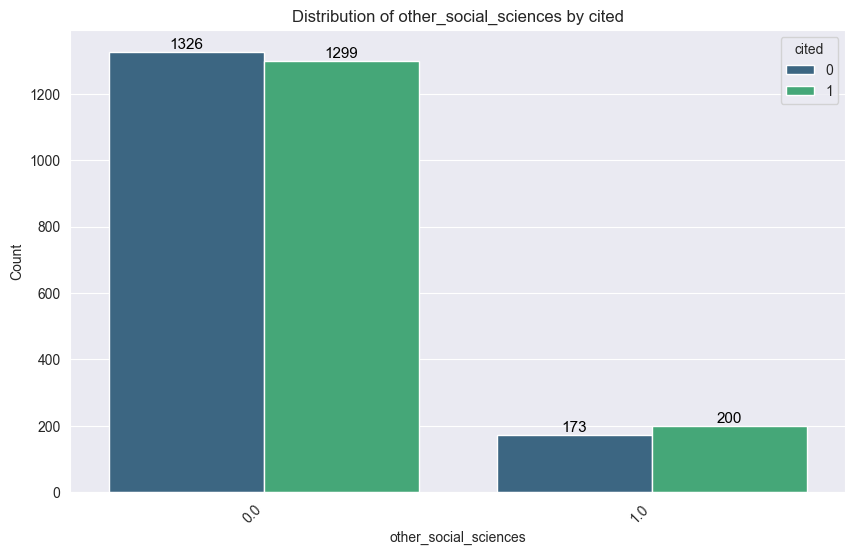

now in history_and_archaeology
Original P-value: 0.08655488155503387
Bootstrap Mean P-value: 0.21767488652236675
Relationship is significant in 962/2500 bootstrap samples.
Cramér's V (Effect Size): 0.03130105103455601
Effect Size: Weak association
No significant association between history_and_archaeology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


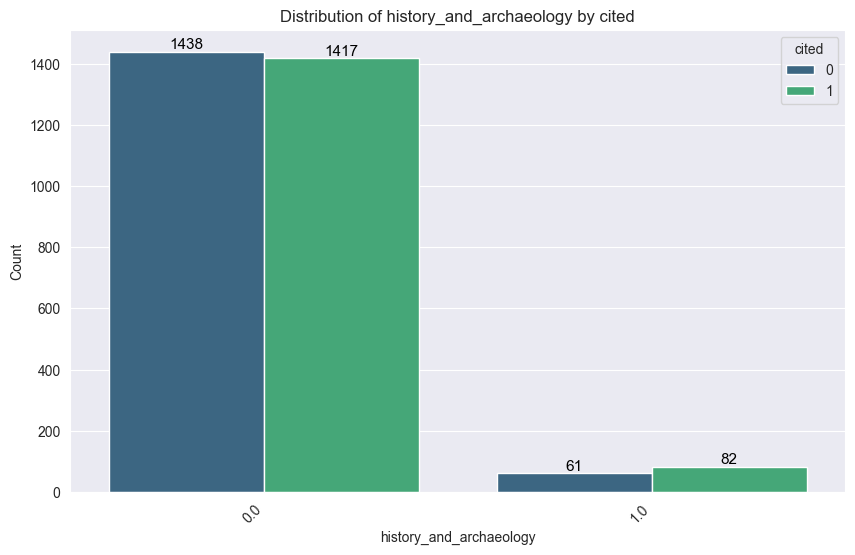

now in languages_and_literature
Original P-value: 0.3784758999559332
Bootstrap Mean P-value: 0.4042168576929108
Relationship is significant in 347/2500 bootstrap samples.
Cramér's V (Effect Size): 0.016084816623110187
Effect Size: Weak association
No significant association between languages_and_literature and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


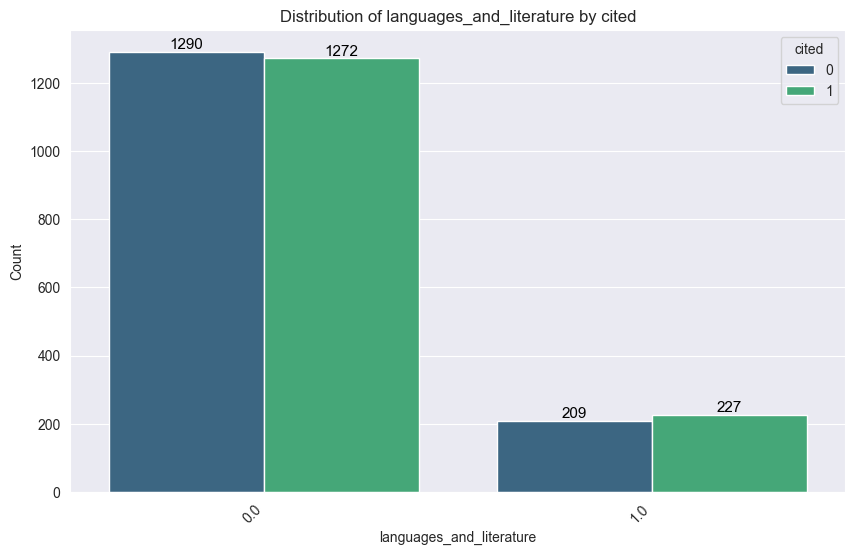

now in philosophy_ethics_and_religion
Original P-value: 0.9118777357318046
Bootstrap Mean P-value: 0.5550961013587199
Relationship is significant in 105/2500 bootstrap samples.
Cramér's V (Effect Size): 0.002021229290931858
Effect Size: Weak association
No significant association between philosophy_ethics_and_religion and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


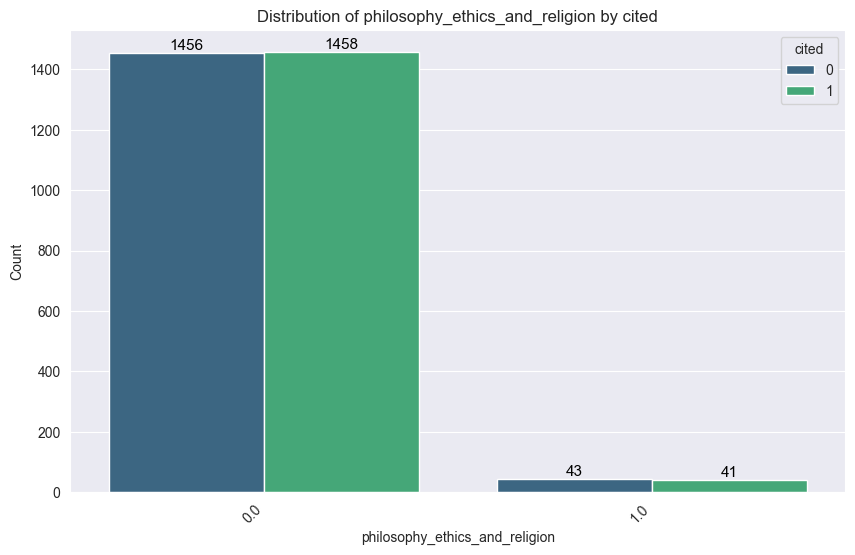

now in arts
Original P-value: 0.8376142174825421
Bootstrap Mean P-value: 0.5821736978751687
Relationship is significant in 104/2500 bootstrap samples.
Cramér's V (Effect Size): 0.003743035077224063
Effect Size: Weak association
No significant association between arts and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


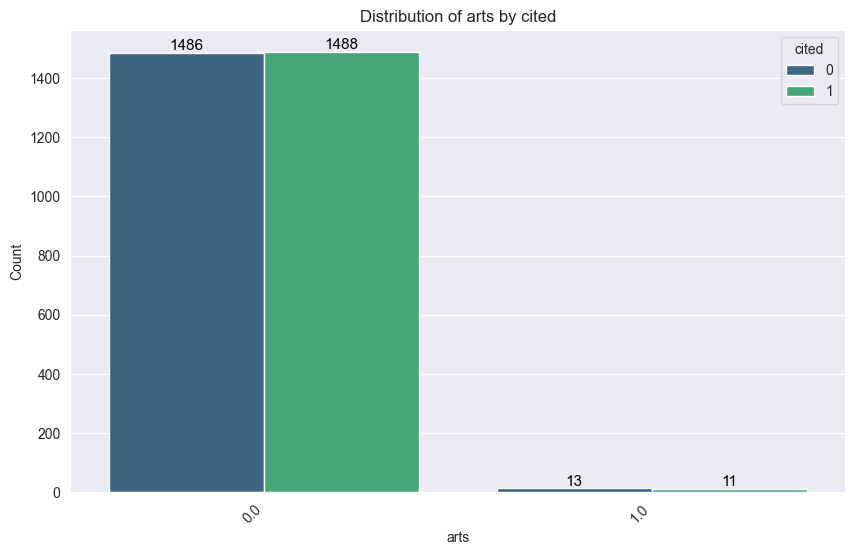

now in other_humanities_and_the_arts
Original P-value: 0.23938154440504283
Bootstrap Mean P-value: 0.33039593360297853
Relationship is significant in 506/2500 bootstrap samples.
Cramér's V (Effect Size): 0.02148763790005667
Effect Size: Weak association
No significant association between other_humanities_and_the_arts and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


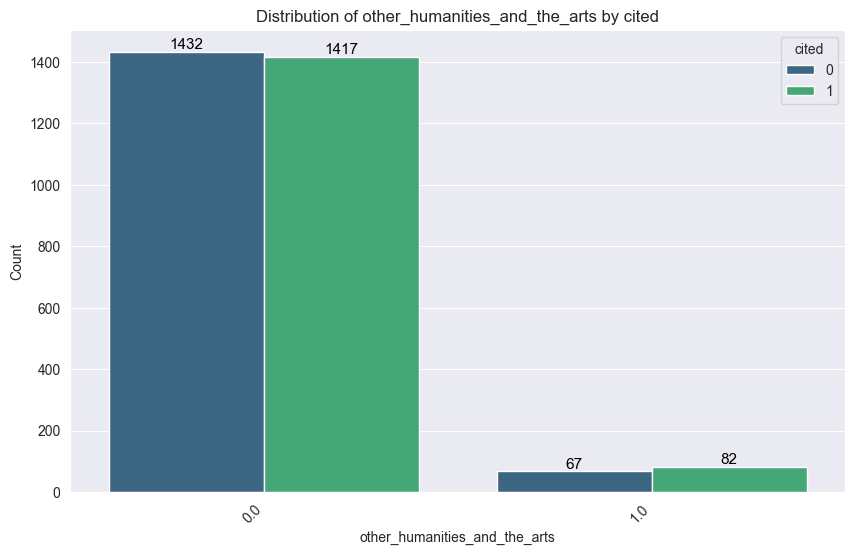

now in applied_research
Original P-value: 0.0661537695532712
Bootstrap Mean P-value: 0.17498612014544102
Relationship is significant in 1139/2500 bootstrap samples.
Cramér's V (Effect Size): 0.03355700919216443
Effect Size: Weak association
No significant association between applied_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


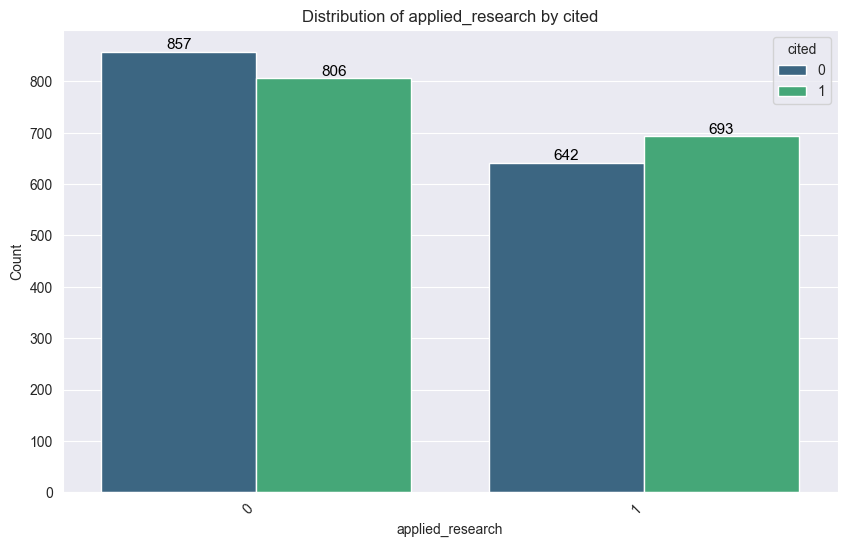

now in conclusive_research
Original P-value: 0.7723865441139722
Bootstrap Mean P-value: 0.5928763998598982
Relationship is significant in 92/2500 bootstrap samples.
Cramér's V (Effect Size): 0.005282803723588476
Effect Size: Weak association
No significant association between conclusive_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


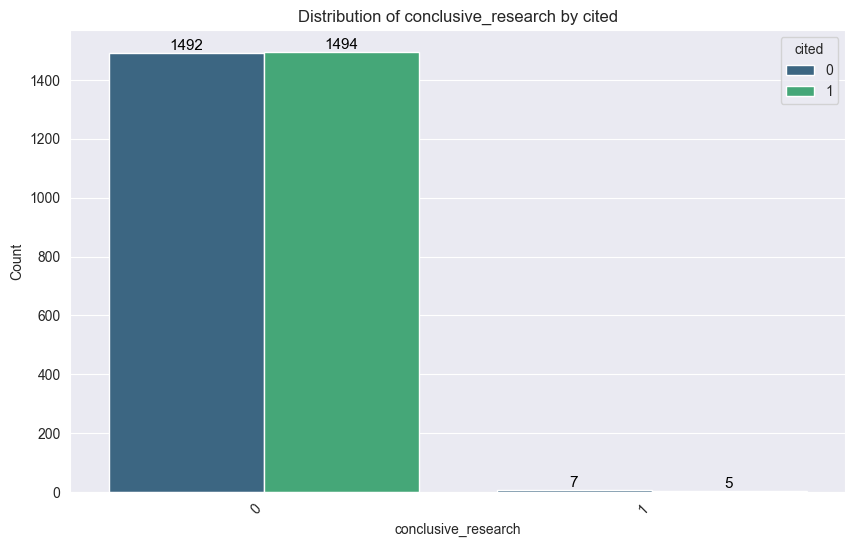

now in correlational_research
Original P-value: 0.5413357847335041
Bootstrap Mean P-value: 0.4598256800682493
Relationship is significant in 254/2500 bootstrap samples.
Cramér's V (Effect Size): 0.011155245761575665
Effect Size: Weak association
No significant association between correlational_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


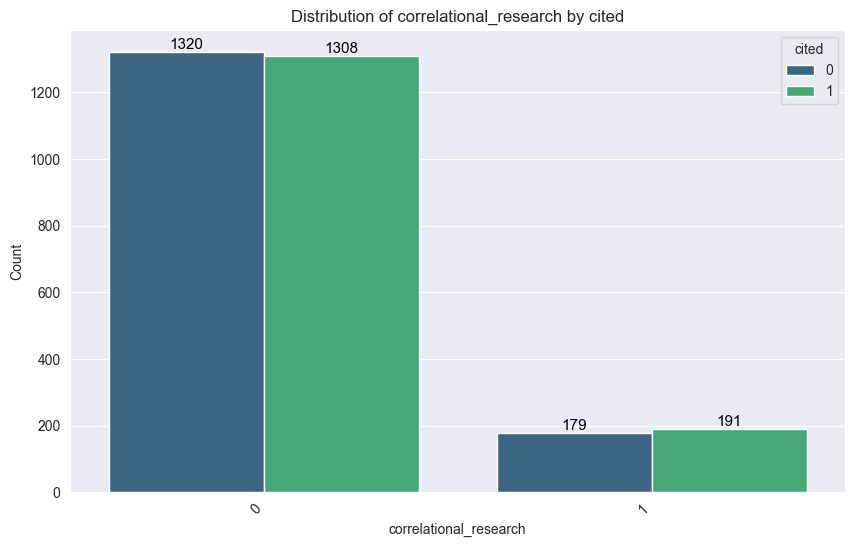

now in descriptive_research
Original P-value: 0.017889668650925485
Bootstrap Mean P-value: 0.08839196878037756
Relationship is significant in 1630/2500 bootstrap samples.
Cramér's V (Effect Size): 0.043246046611103636
Effect Size: Weak association
Significant association between descriptive_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


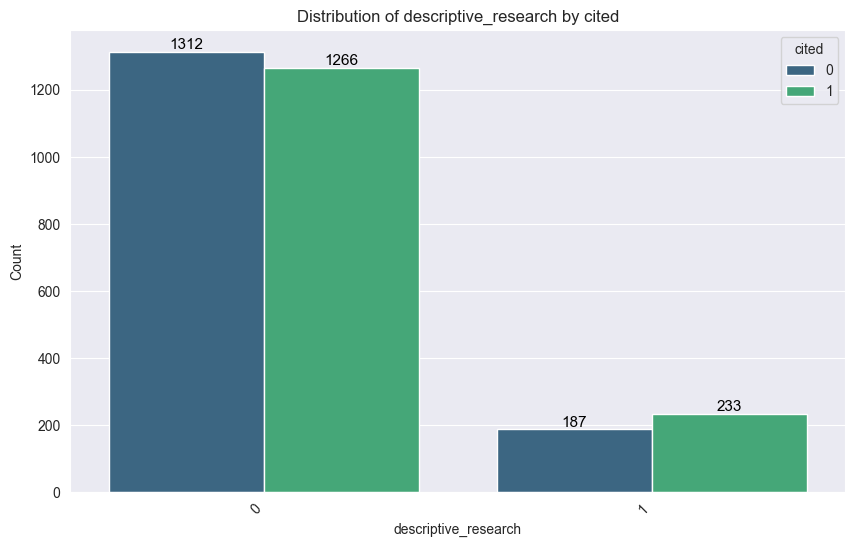

now in ethnographic_research
Original P-value: 0.8452789557981925
Bootstrap Mean P-value: 0.5382633356339861
Relationship is significant in 119/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0035640433334633344
Effect Size: Weak association
No significant association between ethnographic_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


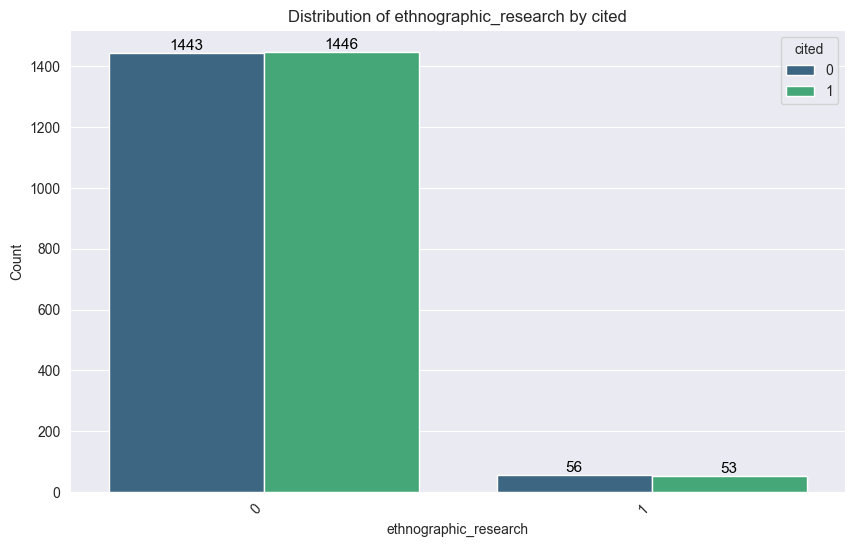

now in experiment
Original P-value: 0.8735275707631016
Bootstrap Mean P-value: 0.5585634125126363
Relationship is significant in 104/2500 bootstrap samples.
Cramér's V (Effect Size): 0.002907173287693535
Effect Size: Weak association
No significant association between experiment and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


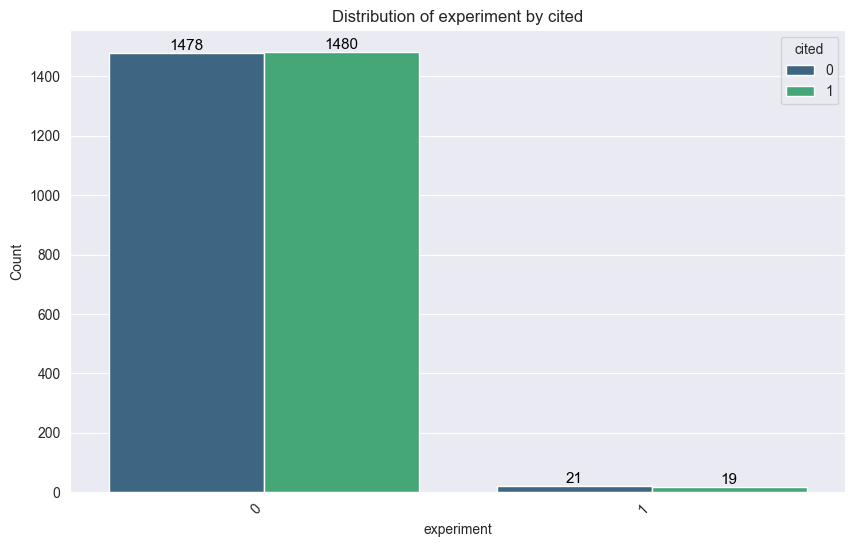

now in exploratory_research
Original P-value: 0.44843692612302355
Bootstrap Mean P-value: 0.44606571803253176
Relationship is significant in 296/2500 bootstrap samples.
Cramér's V (Effect Size): 0.013844167473501824
Effect Size: Weak association
No significant association between exploratory_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


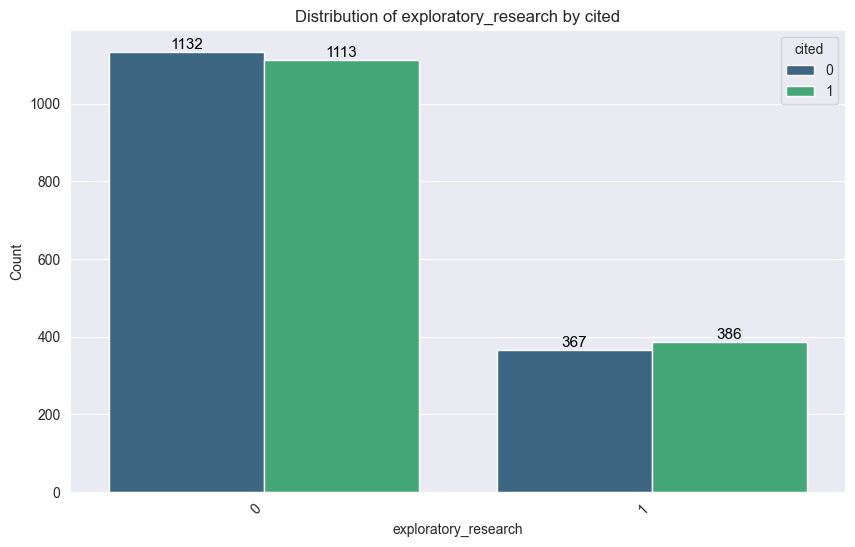

now in focus_groups
Original P-value: 0.14446680955268124
Bootstrap Mean P-value: 0.2726485914513801
Relationship is significant in 735/2500 bootstrap samples.
Cramér's V (Effect Size): 0.026652981734979594
Effect Size: Weak association
No significant association between focus_groups and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


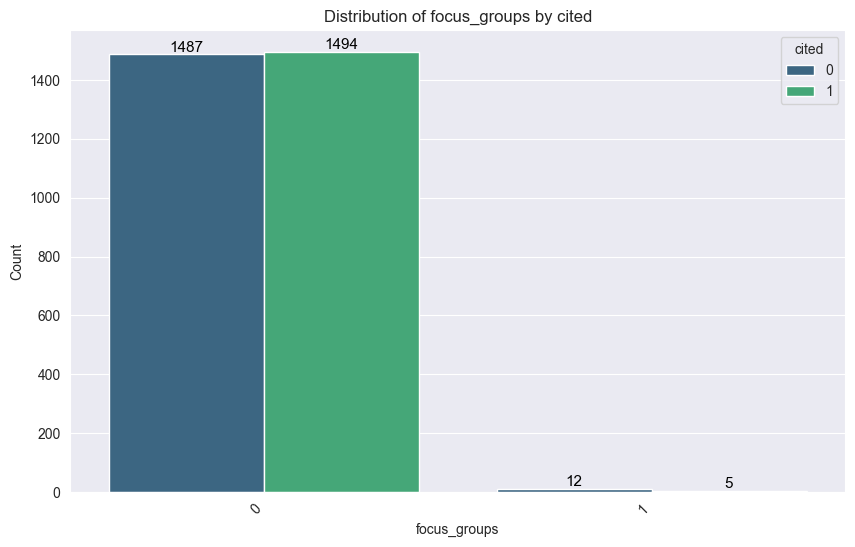

now in interviews
Original P-value: 0.16140864423461249
Bootstrap Mean P-value: 0.2730245803355098
Relationship is significant in 719/2500 bootstrap samples.
Cramér's V (Effect Size): 0.02557529596520645
Effect Size: Weak association
No significant association between interviews and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


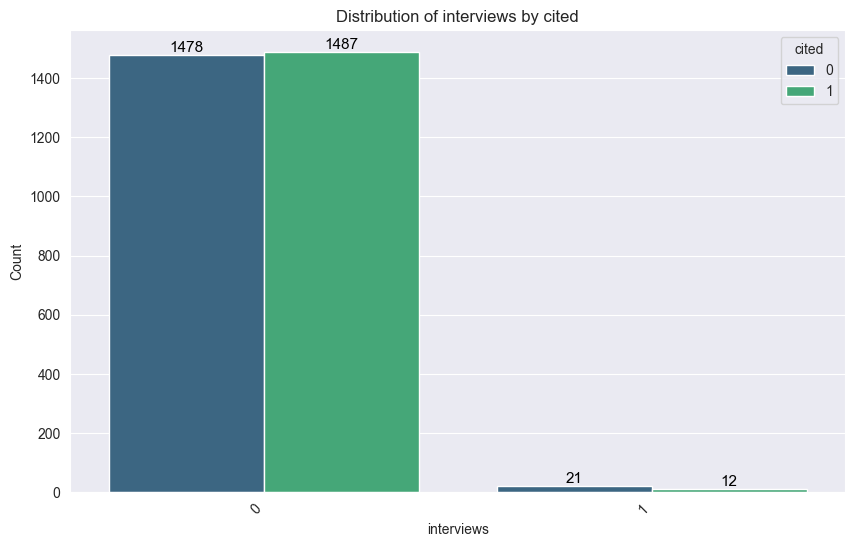

now in mixed_methods
Original P-value: 0.5153324050908868
Bootstrap Mean P-value: 0.45116471714468415
Relationship is significant in 240/2500 bootstrap samples.
Cramér's V (Effect Size): 0.011881455164368006
Effect Size: Weak association
No significant association between mixed_methods and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


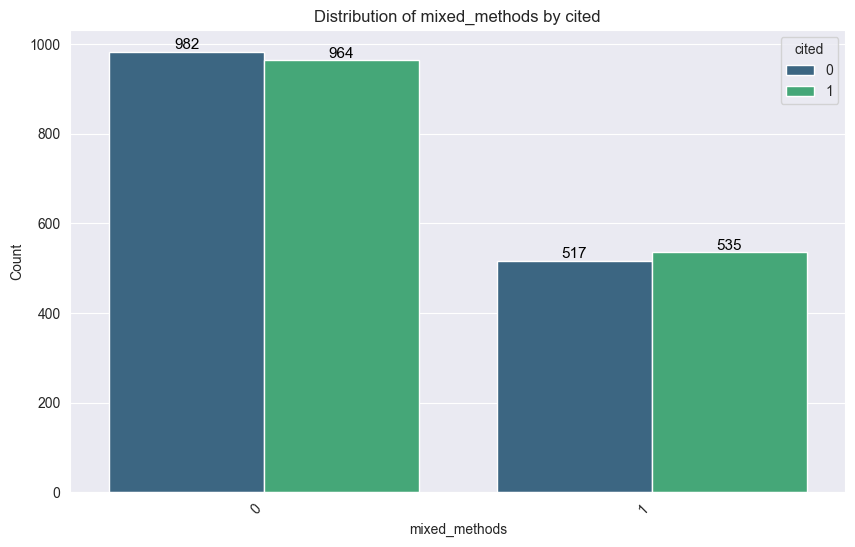

now in observation
Original P-value: 0.5804163581414713
Bootstrap Mean P-value: 0.46976168974394167
Relationship is significant in 210/2500 bootstrap samples.
Cramér's V (Effect Size): 0.010095640489913085
Effect Size: Weak association
No significant association between observation and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


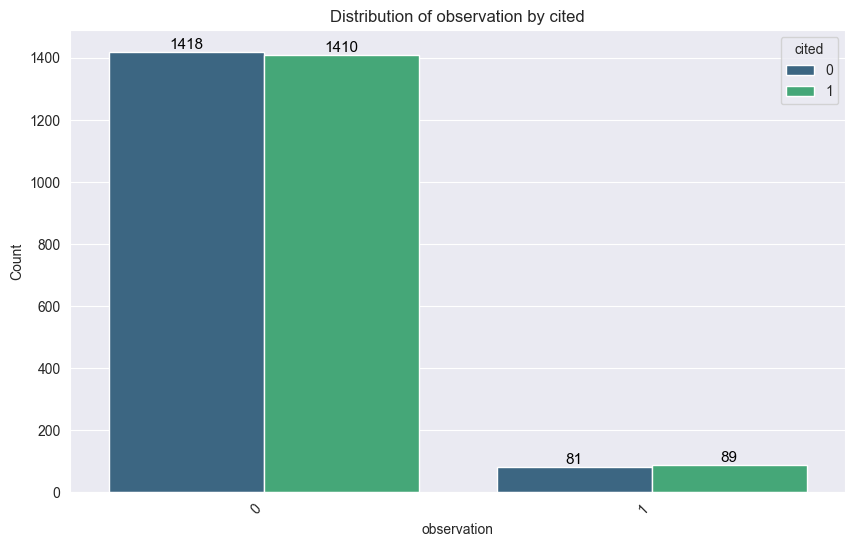

now in qualitative_research
Original P-value: 0.3665115616658329
Bootstrap Mean P-value: 0.3931537861436944
Relationship is significant in 374/2500 bootstrap samples.
Cramér's V (Effect Size): 0.016492440453436005
Effect Size: Weak association
No significant association between qualitative_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


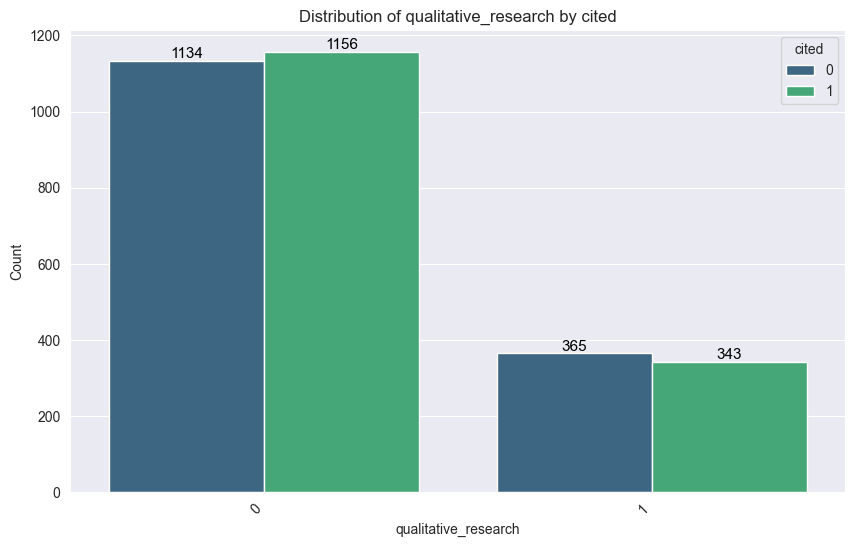

now in quantitative_research
Original P-value: 0.5653596640197058
Bootstrap Mean P-value: 0.4733443618162689
Relationship is significant in 212/2500 bootstrap samples.
Cramér's V (Effect Size): 0.010499670601299966
Effect Size: Weak association
No significant association between quantitative_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


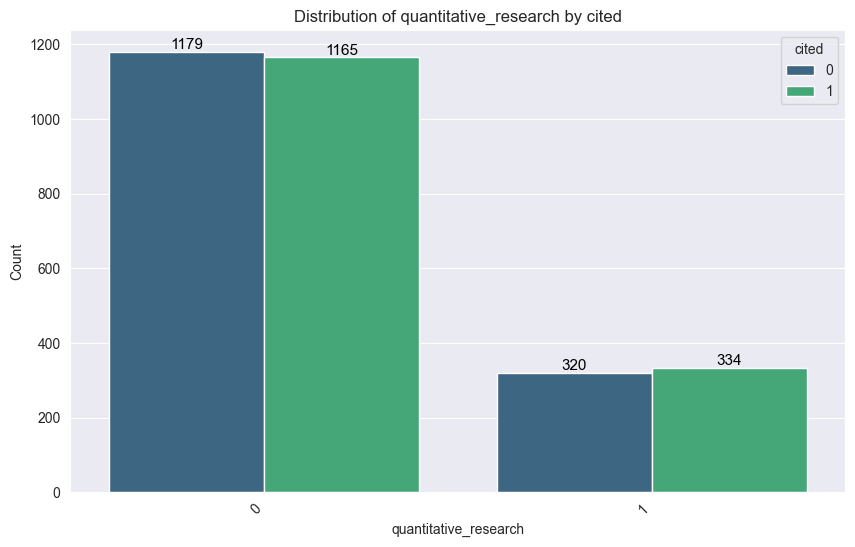

now in questionnaires
Original P-value: 0.01594947348590774
Bootstrap Mean P-value: 0.07481989350779589
Relationship is significant in 1720/2500 bootstrap samples.
Cramér's V (Effect Size): 0.044016325748425705
Effect Size: Weak association
Significant association between questionnaires and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


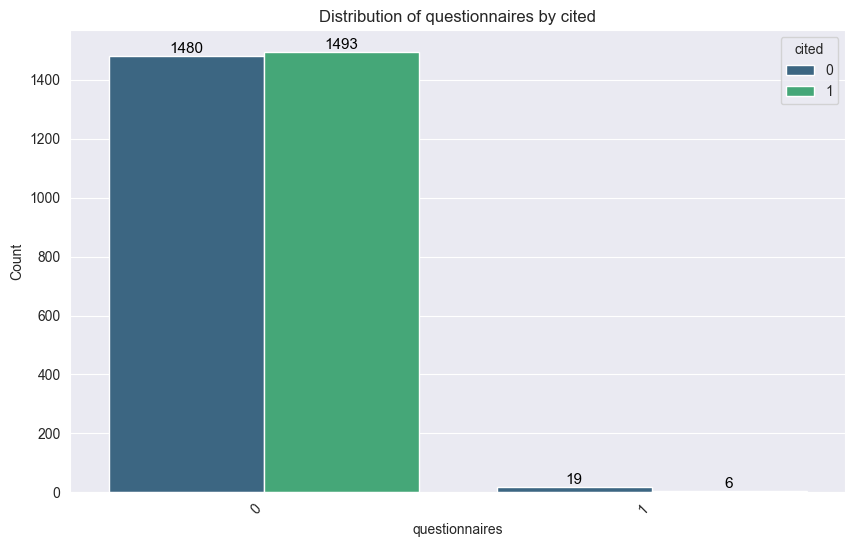

now in secondary_research
Original P-value: 0.3495554167167664
Bootstrap Mean P-value: 0.40764109821050054
Relationship is significant in 381/2500 bootstrap samples.
Cramér's V (Effect Size): 0.017084634291750864
Effect Size: Weak association
No significant association between secondary_research and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


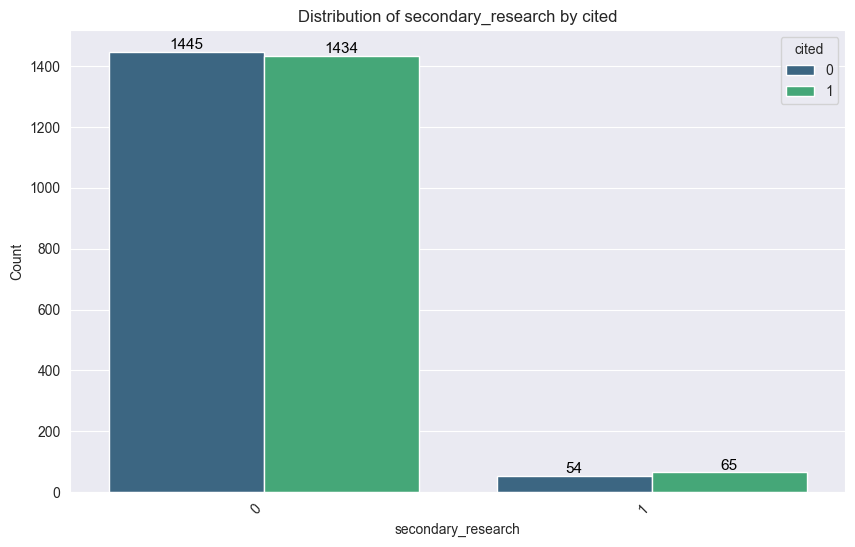

now in survey_methodology
Original P-value: 0.3876485935345414
Bootstrap Mean P-value: 0.4132500915849244
Relationship is significant in 343/2500 bootstrap samples.
Cramér's V (Effect Size): 0.015777652368396573
Effect Size: Weak association
No significant association between survey_methodology and cited.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


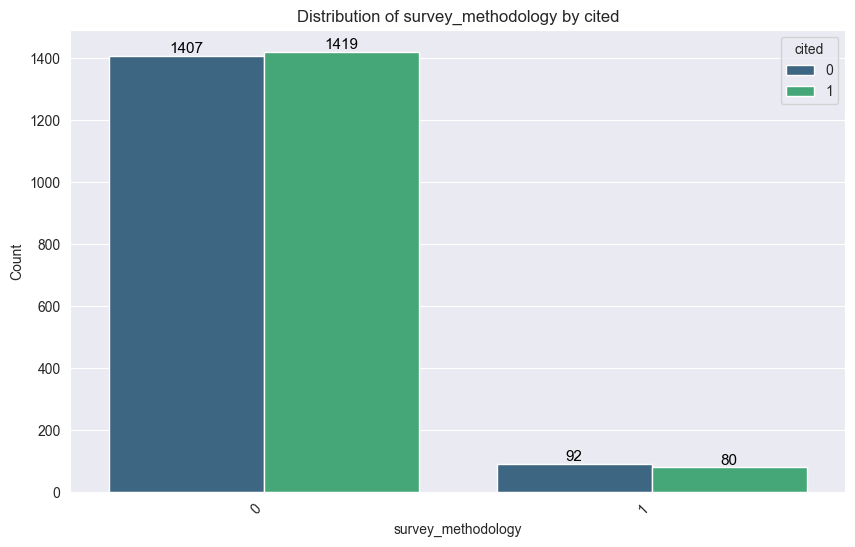

In [16]:
for col in df_c19.columns:
    if col in ['abstract', 'title', 'Unnamed: 0', 'Unnamed: 0.1', 'cited', 'research_methods>=5_c19', 'disciplines>=5_c19']:
        continue
    print(f"now in {col}")
    get_stat_significance(df_c19, col, 'cited')
    try:
        plot_categorical_distribution(df_c19, target_variable='cited', categorical_variable=col)
    except: 
        pass


now in novelty
Original P-value: 1.9920906553215145e-47
Bootstrap Mean P-value: 2.3412960370696036e-34
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.24508303513948965
Effect Size: Moderate association
Significant association between novelty and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


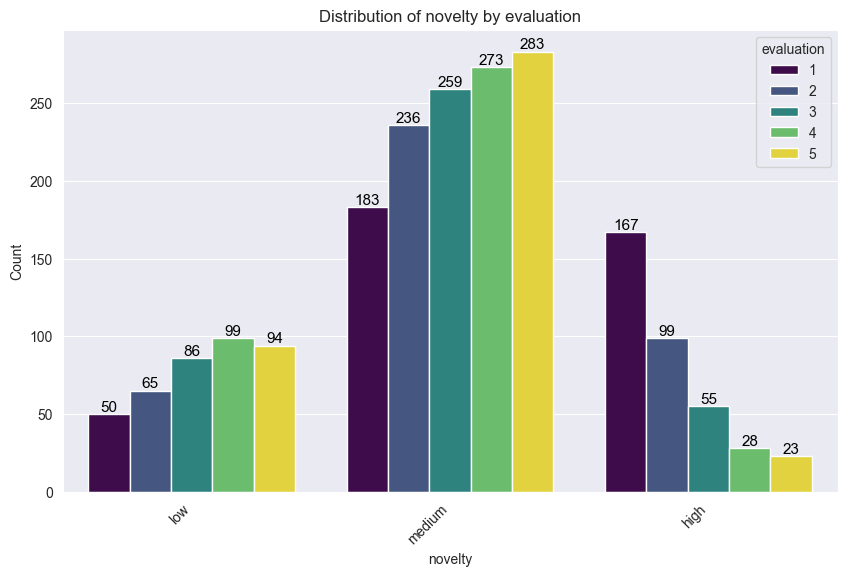

now in rigor
Original P-value: 7.0785552881818806e-71
Bootstrap Mean P-value: 6.398629370890952e-50
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2960156487064823
Effect Size: Moderate association
Significant association between rigor and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


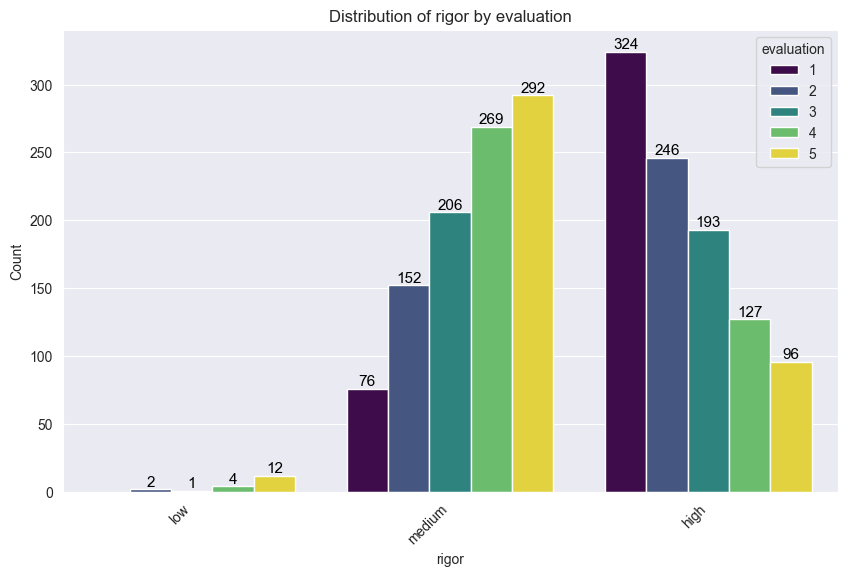

now in grammar
Original P-value: 4.6865211722534796e-20
Bootstrap Mean P-value: 4.6952278793381305e-12
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2200161484028683
Effect Size: Moderate association
Significant association between grammar and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


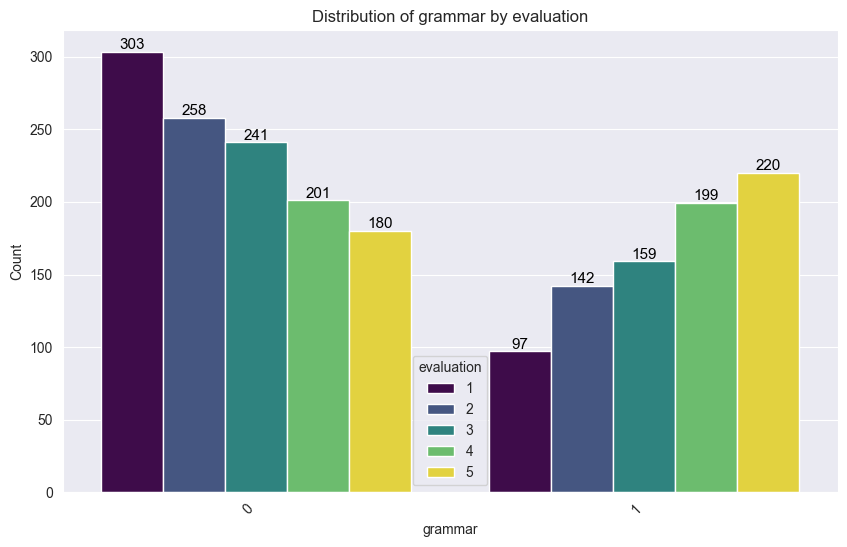

now in replicability
Original P-value: 7.971471796954155e-44
Bootstrap Mean P-value: 6.012577037696429e-32
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.32232094984252535
Effect Size: Strong association
Significant association between replicability and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


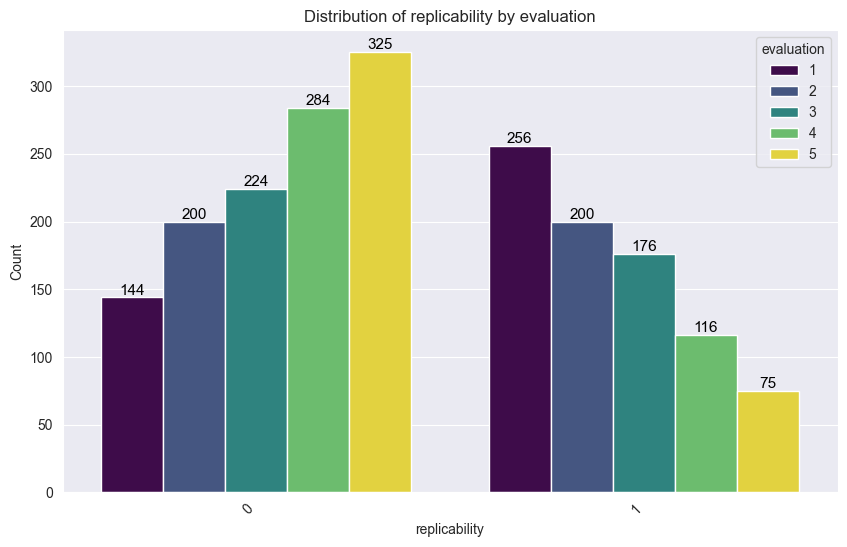

now in accessibility
Original P-value: 0.1491445134929061
Bootstrap Mean P-value: 0.07603497997131257
Relationship is significant in 1686/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0548781030099254
Effect Size: Weak association
No significant association between accessibility and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


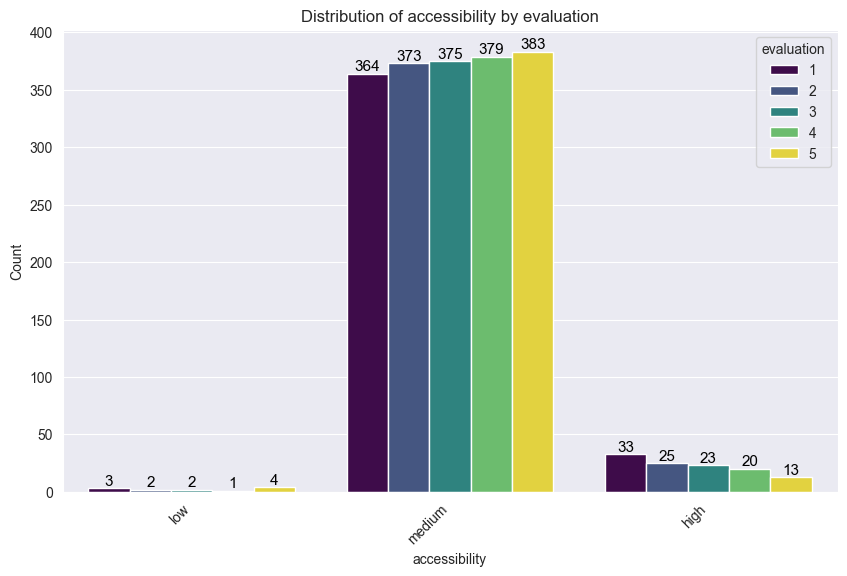

now in mathematics
Original P-value: 7.003097929743016e-16
Bootstrap Mean P-value: 3.9743173091398775e-09
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.19640050912786525
Effect Size: Moderate association
Significant association between mathematics and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


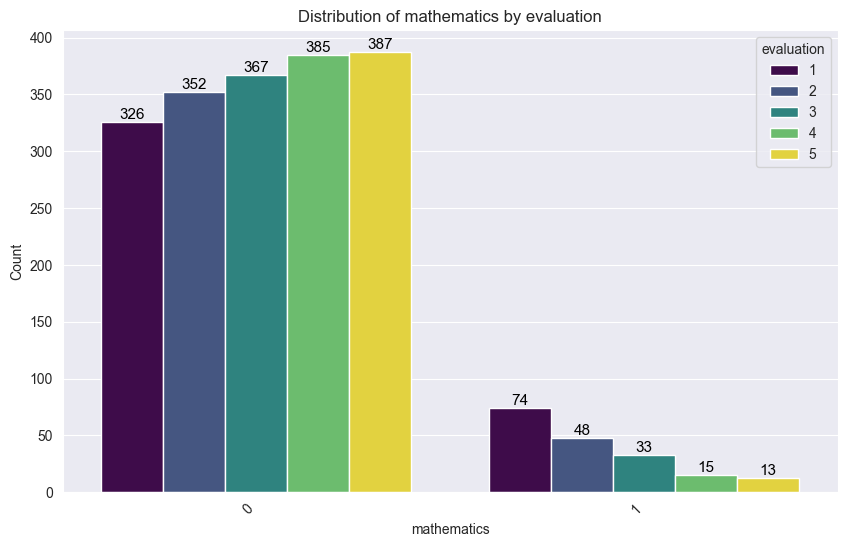

now in computer_and_information_sciences
Original P-value: 8.251568346617146e-33
Bootstrap Mean P-value: 9.721353392564456e-22
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.27972751098727394
Effect Size: Moderate association
Significant association between computer_and_information_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


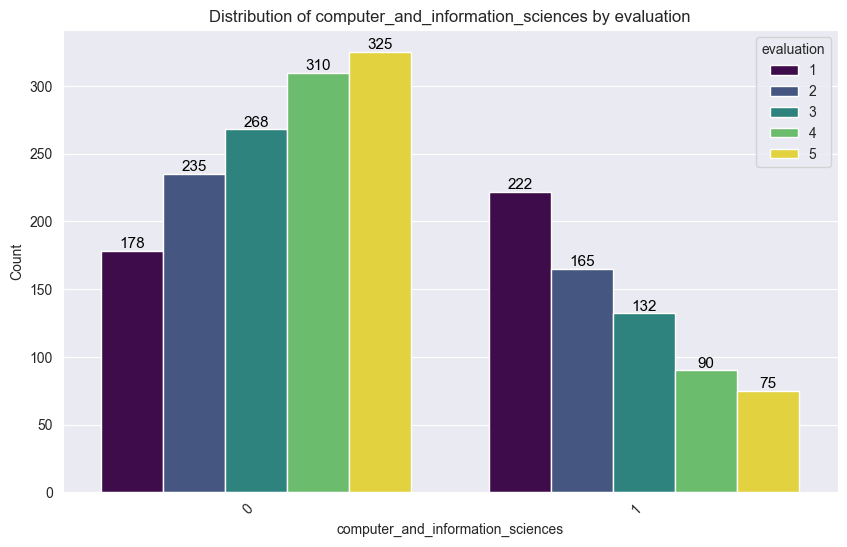

now in physical_sciences
Original P-value: 3.171451007308937e-39
Bootstrap Mean P-value: 9.05787384795067e-26
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.30527358923712067
Effect Size: Strong association
Significant association between physical_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


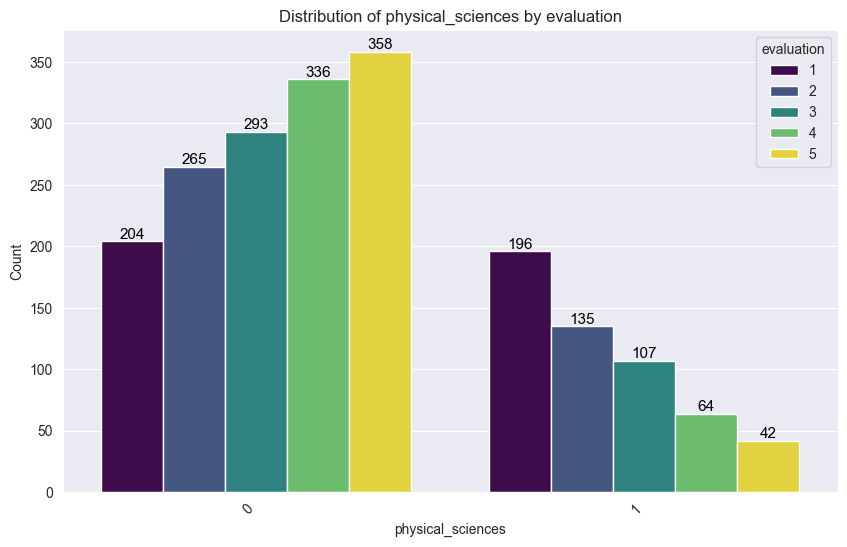

now in chemical_sciences
Original P-value: 2.0389469481192423e-28
Bootstrap Mean P-value: 2.3220685325934136e-17
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.26075653053136805
Effect Size: Moderate association
Significant association between chemical_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


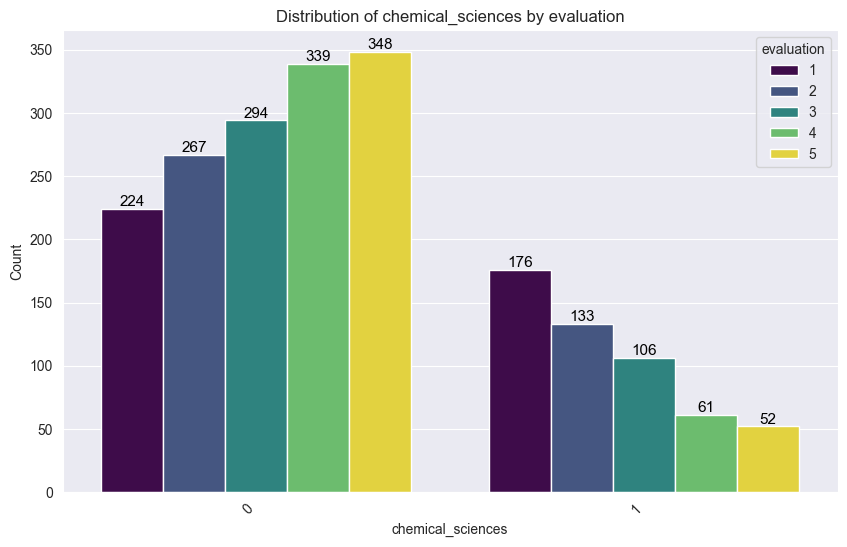

now in earth_and_related_environmental_sciences
Original P-value: 1.3596778711456364e-24
Bootstrap Mean P-value: 4.900592691395221e-16
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2430019989494499
Effect Size: Moderate association
Significant association between earth_and_related_environmental_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


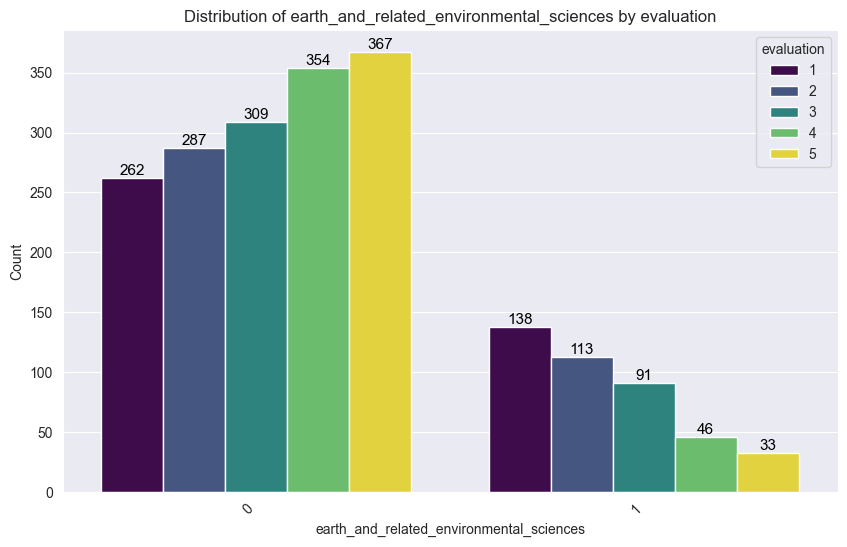

now in biological_sciences
Original P-value: 1.6791165934255688e-51
Bootstrap Mean P-value: 5.130437270113886e-38
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.3488889591686053
Effect Size: Strong association
Significant association between biological_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


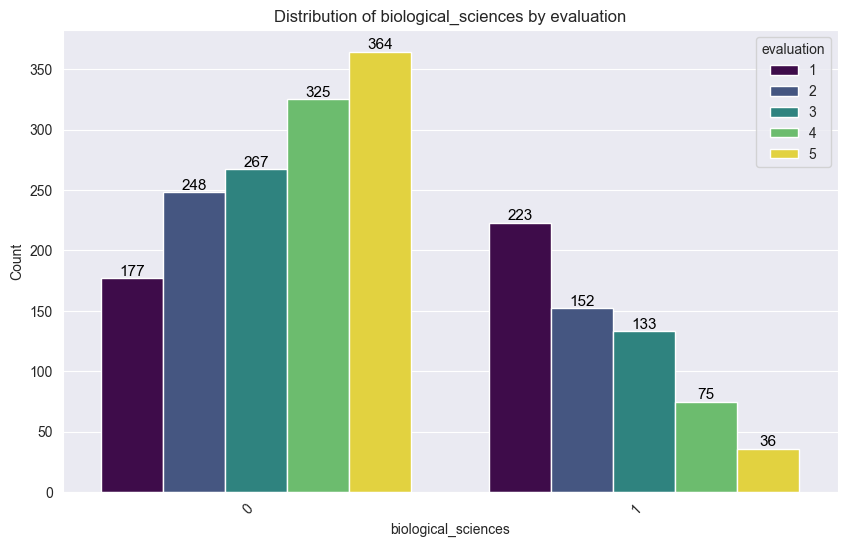

now in other_natural_sciences
Original P-value: 4.430362137640699e-36
Bootstrap Mean P-value: 2.5928037400490327e-23
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.29303409880454967
Effect Size: Moderate association
Significant association between other_natural_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


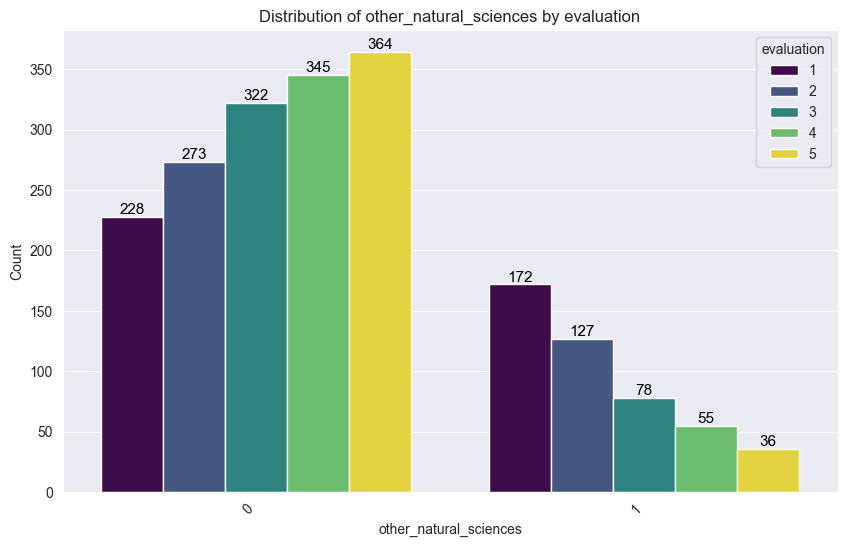

now in civil_engineering
Original P-value: 2.0778099018927364e-06
Bootstrap Mean P-value: 0.0004624394971120431
Relationship is significant in 2497/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1261437013069733
Effect Size: Moderate association
Significant association between civil_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


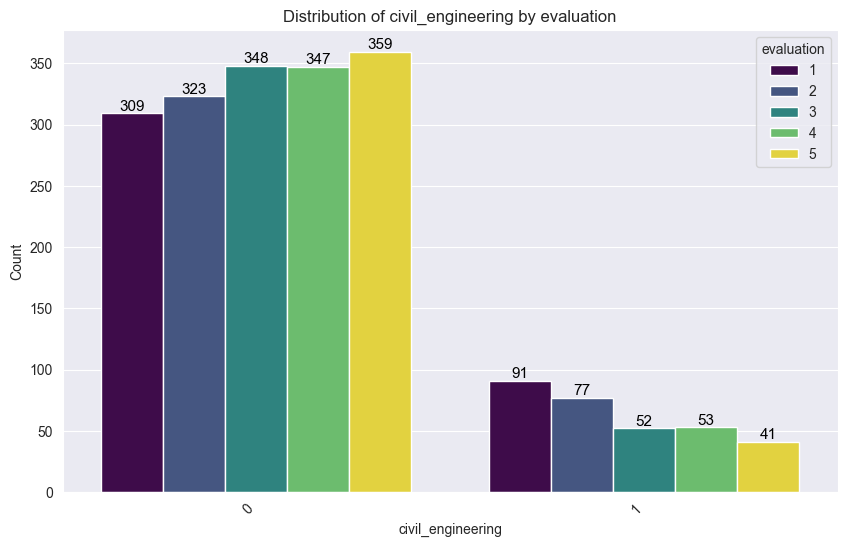

now in electrical_engineering
Original P-value: 1.1697493144825432e-11
Bootstrap Mean P-value: 5.691715718020636e-07
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1689911270681742
Effect Size: Moderate association
Significant association between electrical_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


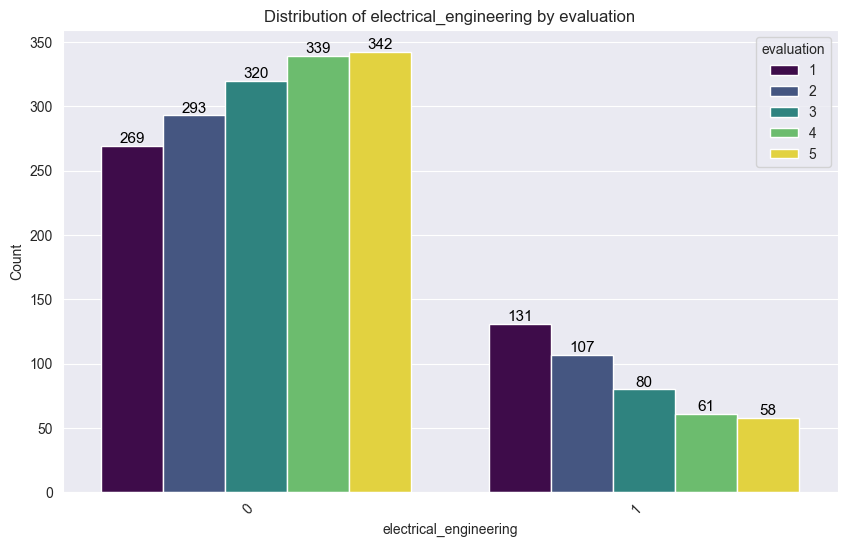

now in mechanical_engineering
Original P-value: 6.88262609520225e-06
Bootstrap Mean P-value: 0.0008467200892167135
Relationship is significant in 2492/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1209797177972444
Effect Size: Moderate association
Significant association between mechanical_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


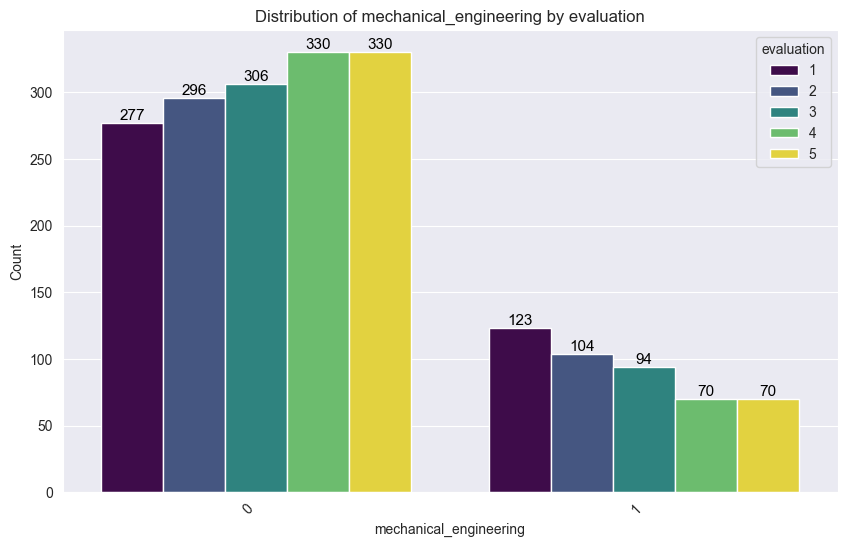

now in chemical_engineering
Original P-value: 1.495098192136837e-09
Bootstrap Mean P-value: 6.443485370807156e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.15336422986610312
Effect Size: Moderate association
Significant association between chemical_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


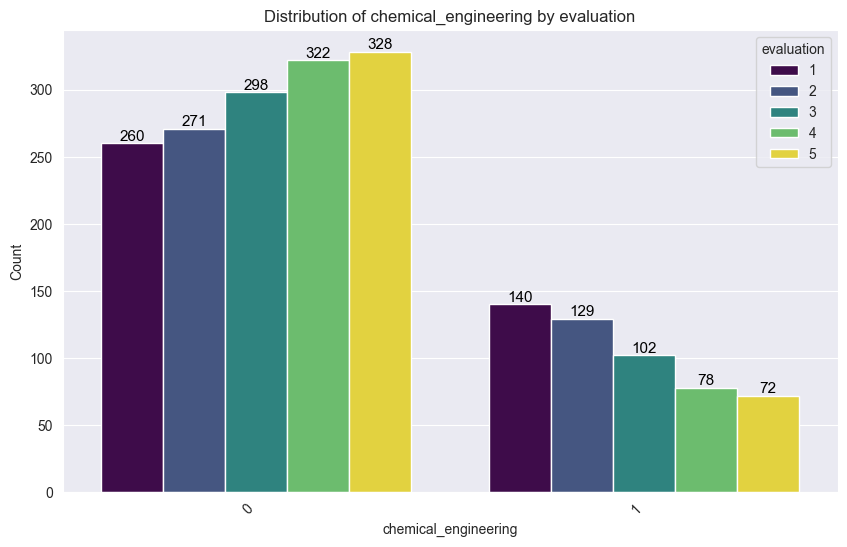

now in materials_engineering
Original P-value: 3.8361175935041533e-05
Bootstrap Mean P-value: 0.001778850589249496
Relationship is significant in 2483/2500 bootstrap samples.
Cramér's V (Effect Size): 0.11310436165299707
Effect Size: Moderate association
Significant association between materials_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


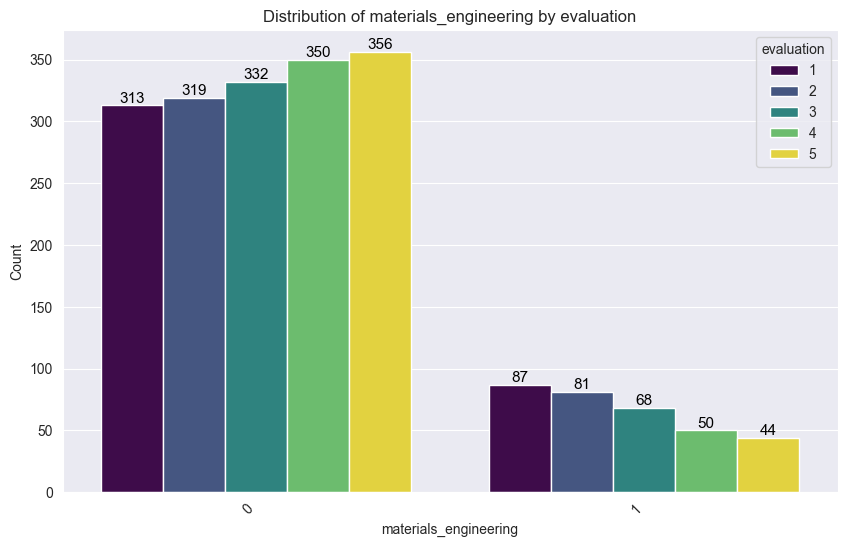

now in environmental_engineering
Original P-value: 4.697513428368978e-11
Bootstrap Mean P-value: 1.114104874731326e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.16467484854721712
Effect Size: Moderate association
Significant association between environmental_engineering and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


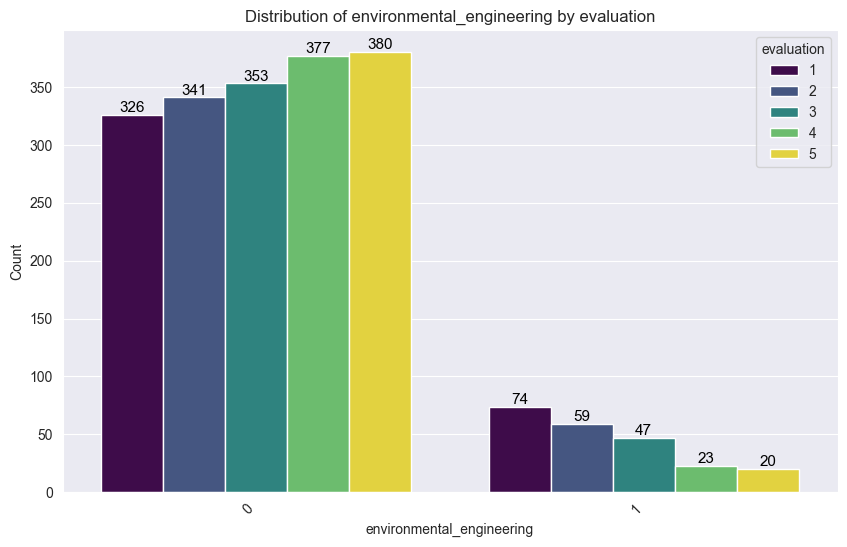

now in evironmental_biotechnology
Original P-value: 1.5262985128654605e-18
Bootstrap Mean P-value: 2.2137751592437477e-11
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.21177592028349382
Effect Size: Moderate association
Significant association between evironmental_biotechnology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


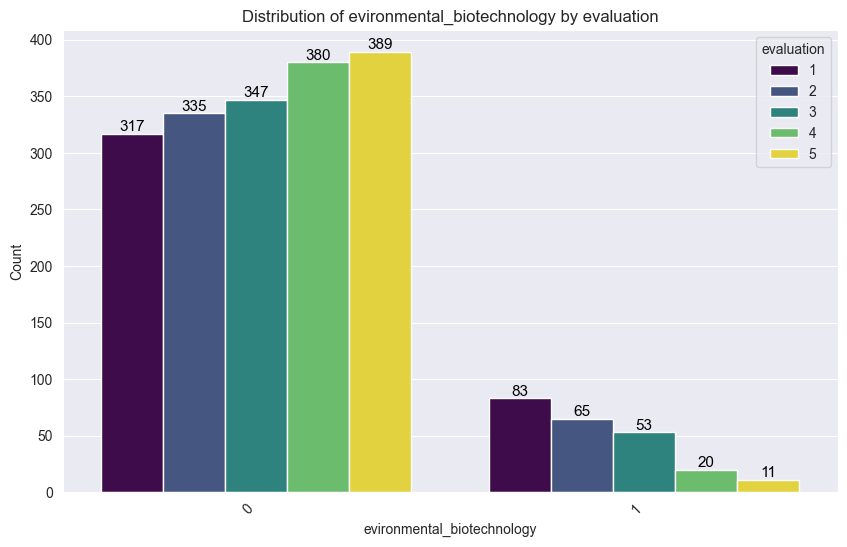

now in industrial_biotechnology
Original P-value: 5.2555598403588826e-15
Bootstrap Mean P-value: 4.834748904688835e-09
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1910600317754856
Effect Size: Moderate association
Significant association between industrial_biotechnology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


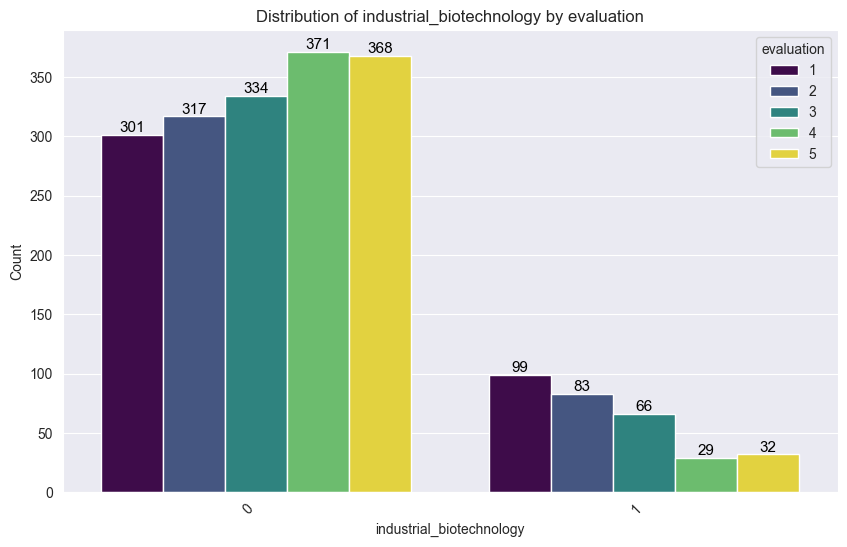

now in nano-technology
Original P-value: 8.64914701503055e-08
Bootstrap Mean P-value: 2.1433268698614793e-05
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.13882537435687403
Effect Size: Moderate association
Significant association between nano-technology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


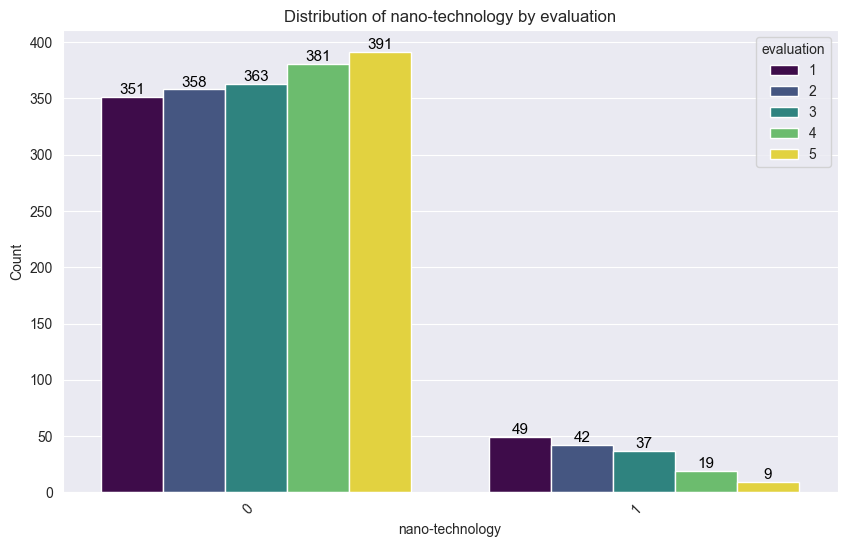

now in other_engineering_and_technologies
Original P-value: 1.1514623497203819e-11
Bootstrap Mean P-value: 1.3006489263393313e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.16903937214909368
Effect Size: Moderate association
Significant association between other_engineering_and_technologies and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


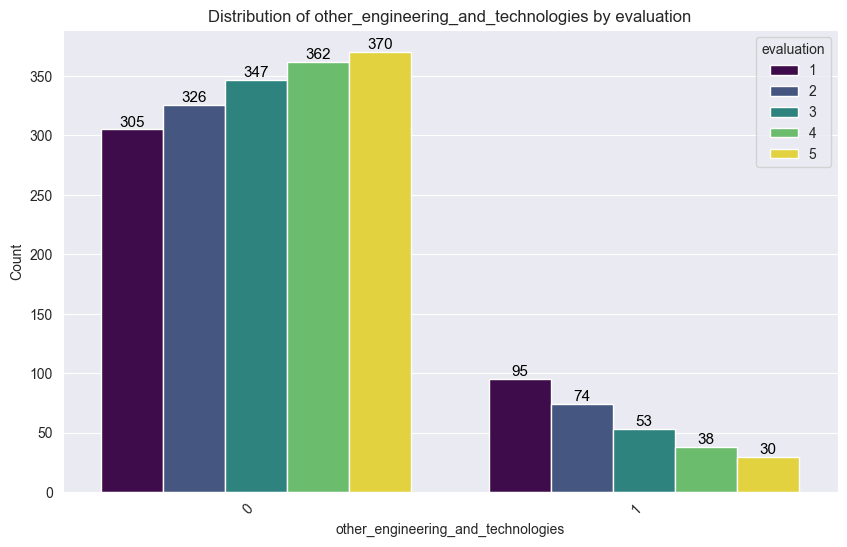

now in basic_medicine
Original P-value: 1.3259480087015795e-41
Bootstrap Mean P-value: 3.495719334862327e-28
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.314207400404362
Effect Size: Strong association
Significant association between basic_medicine and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


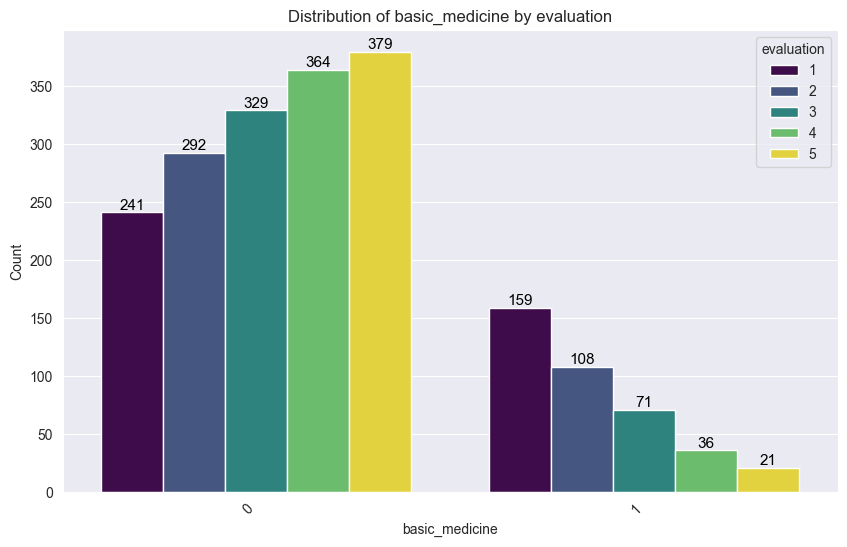

now in clinical_medicine
Original P-value: 1.6024778598939112e-21
Bootstrap Mean P-value: 2.4177740354923923e-12
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.22770638397889234
Effect Size: Moderate association
Significant association between clinical_medicine and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


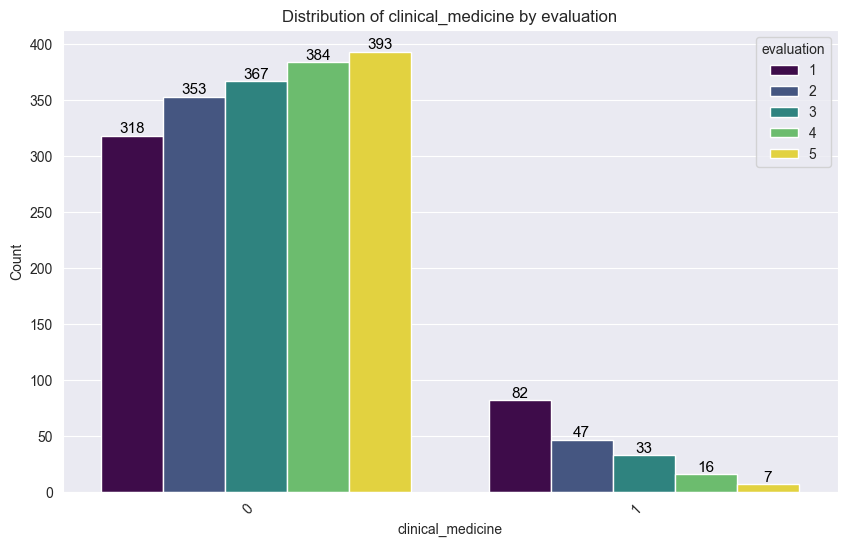

now in health_sciences
Original P-value: 7.516861606224953e-18
Bootstrap Mean P-value: 9.122861469007137e-11
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2078906607396949
Effect Size: Moderate association
Significant association between health_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


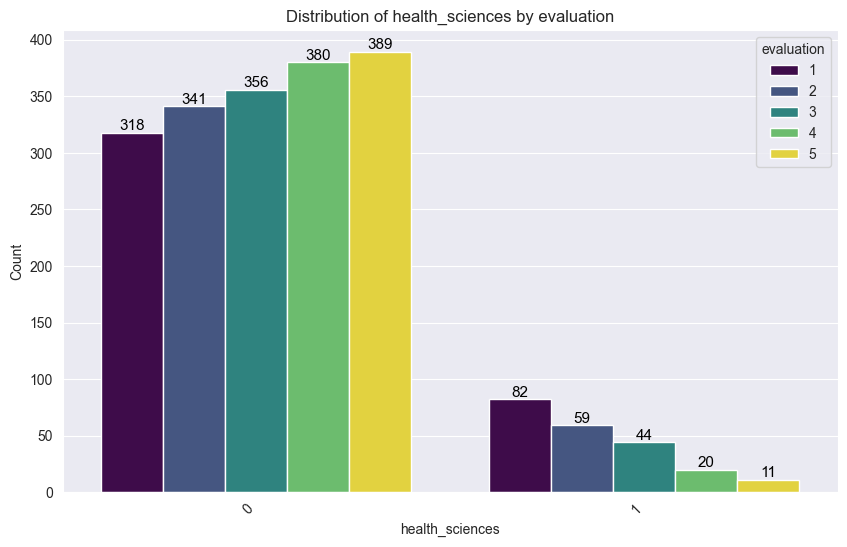

now in medical_biotechnology
Original P-value: 1.3085527689783018e-27
Bootstrap Mean P-value: 2.0073118550434904e-16
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.25711313965572424
Effect Size: Moderate association
Significant association between medical_biotechnology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


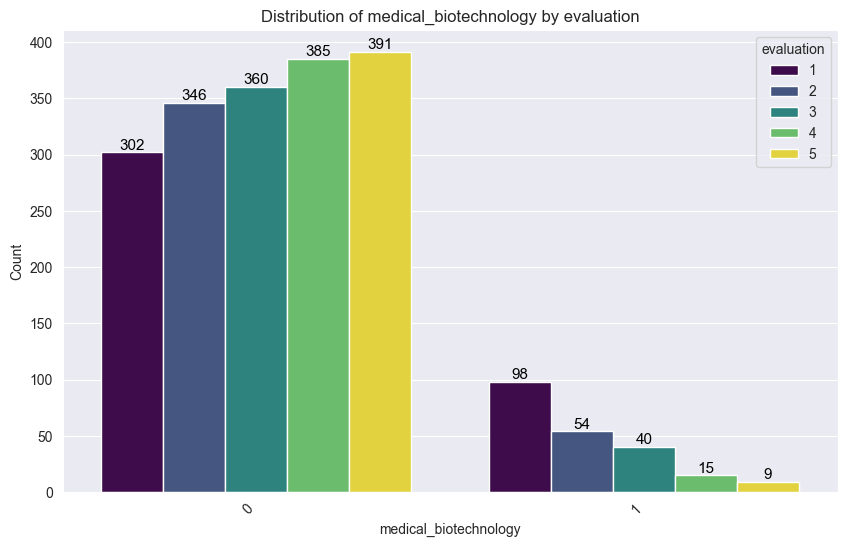

now in other_medical_sciences
Original P-value: 2.520116816655975e-29
Bootstrap Mean P-value: 2.17422640034069e-16
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2647922962728367
Effect Size: Moderate association
Significant association between other_medical_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


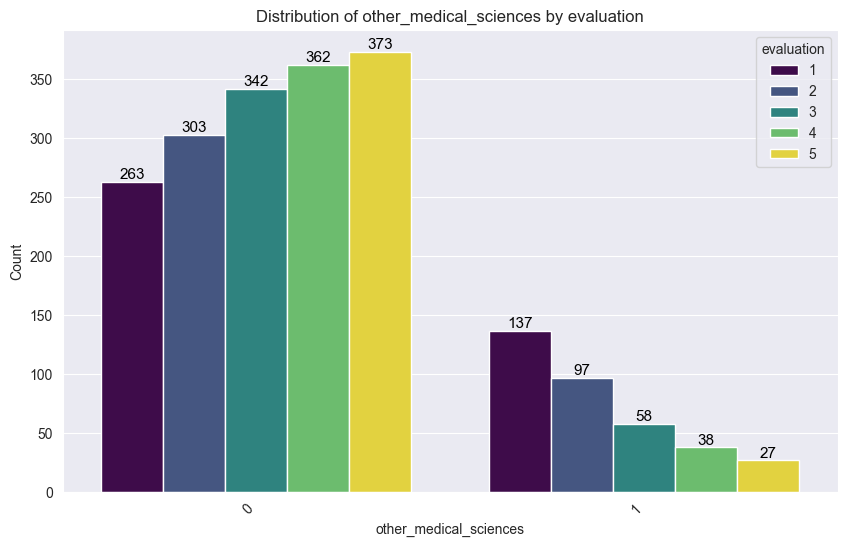

now in agriculture_forestry_and_fisheries
Original P-value: 3.7441324834150875e-17
Bootstrap Mean P-value: 1.0930574992808937e-10
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.20389954496743654
Effect Size: Moderate association
Significant association between agriculture_forestry_and_fisheries and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


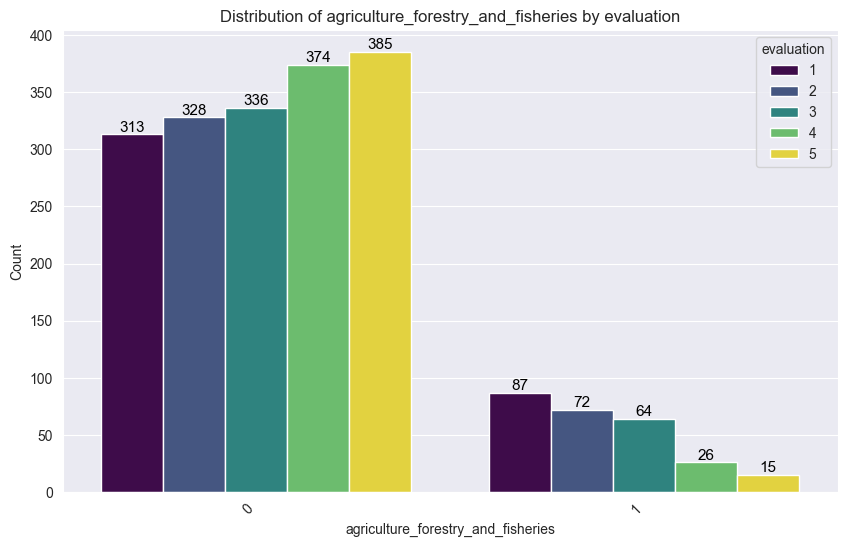

now in animal_and_dairy_science
Original P-value: 5.205710652190268e-26
Bootstrap Mean P-value: 8.596078488045167e-17
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.24973263660118192
Effect Size: Moderate association
Significant association between animal_and_dairy_science and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


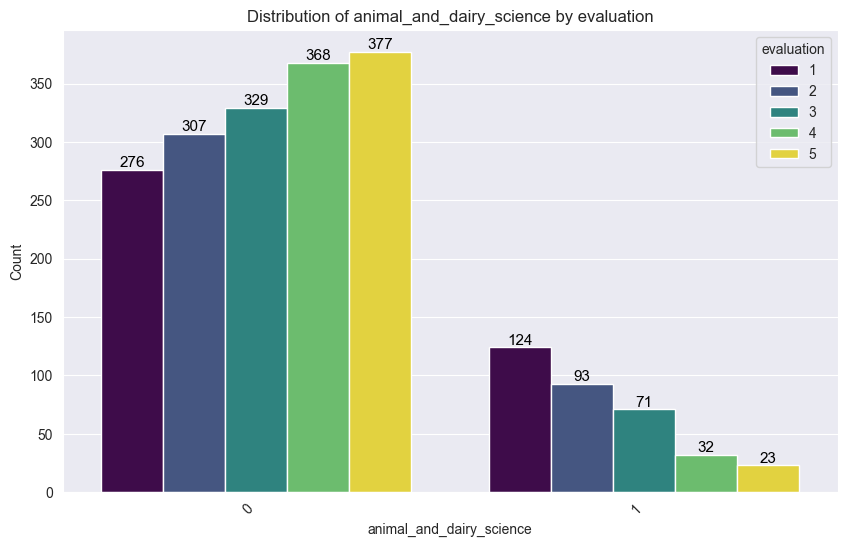

now in veterinary_science
Original P-value: 1.2105955222919015e-25
Bootstrap Mean P-value: 3.745752544033944e-15
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2480097228496515
Effect Size: Moderate association
Significant association between veterinary_science and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


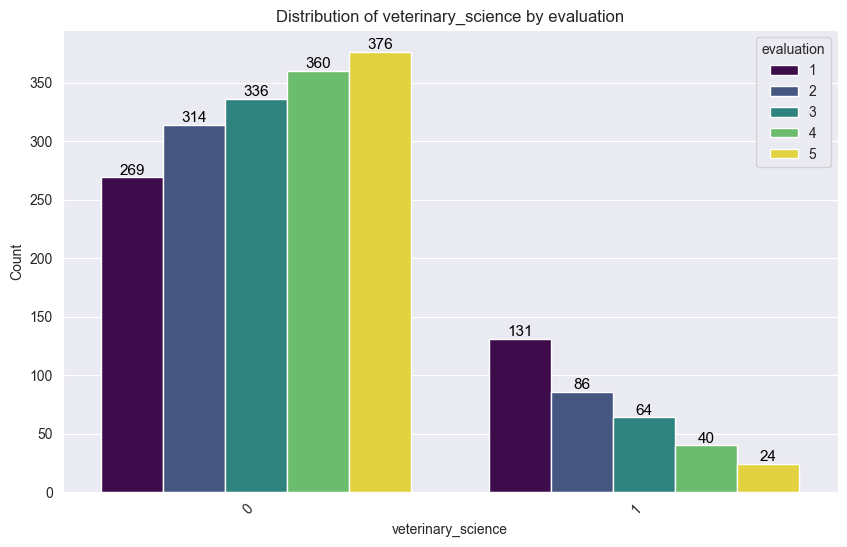

now in agricultural_biotechnology
Original P-value: 1.760427396923287e-08
Bootstrap Mean P-value: 7.456753078658859e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.14471903687416168
Effect Size: Moderate association
Significant association between agricultural_biotechnology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


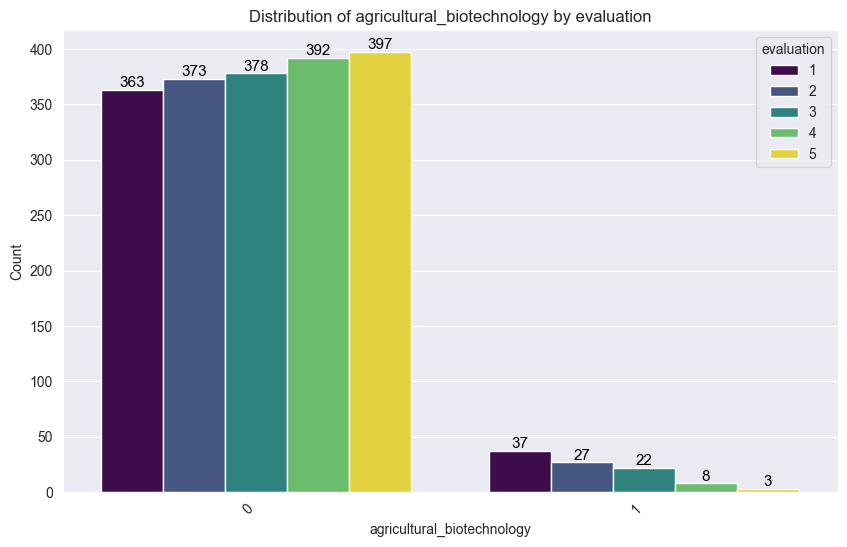

now in other_agricultural_sciences
Original P-value: 1.6412627056404238e-23
Bootstrap Mean P-value: 3.5544066511350676e-14
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.23773105683462759
Effect Size: Moderate association
Significant association between other_agricultural_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


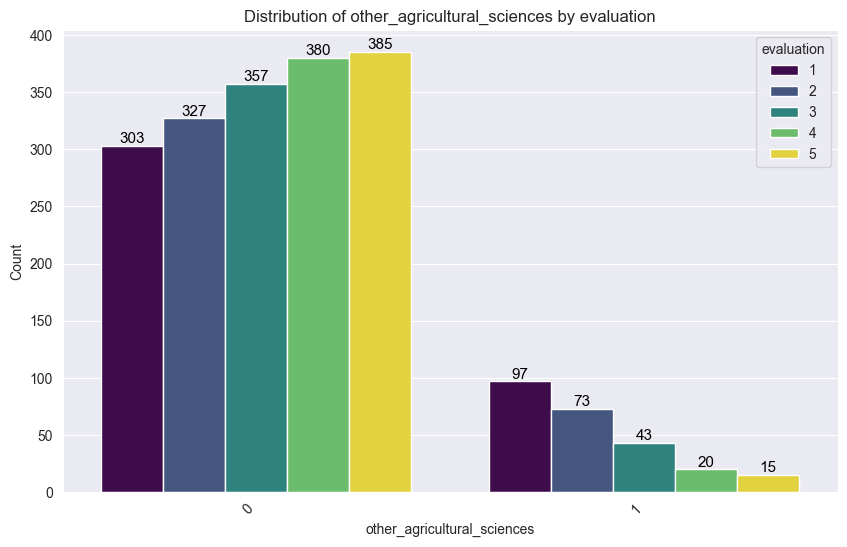

now in psychology
Original P-value: 3.728454060433183e-25
Bootstrap Mean P-value: 2.7281413842662973e-16
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.2456938768435442
Effect Size: Moderate association
Significant association between psychology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


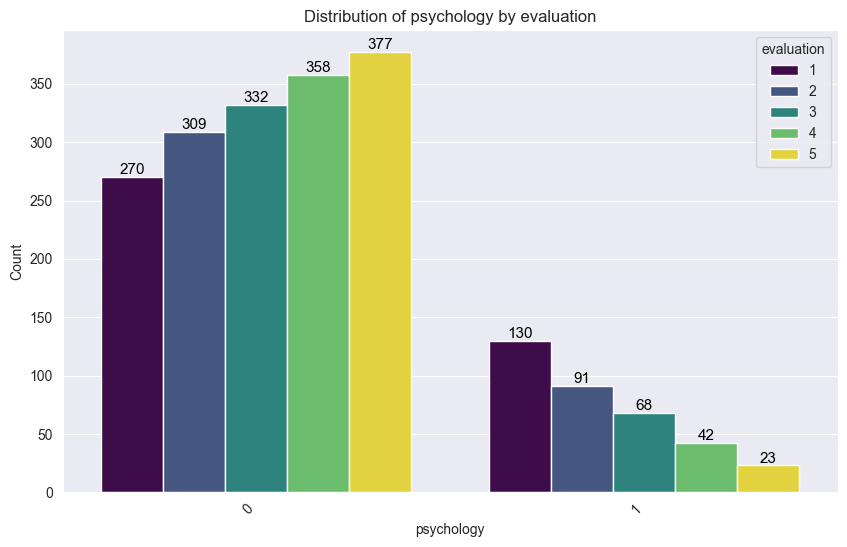

now in economics_and_business
Original P-value: 1.8117460991224797e-05
Bootstrap Mean P-value: 0.00213026884649957
Relationship is significant in 2476/2500 bootstrap samples.
Cramér's V (Effect Size): 0.11661745417077109
Effect Size: Moderate association
Significant association between economics_and_business and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


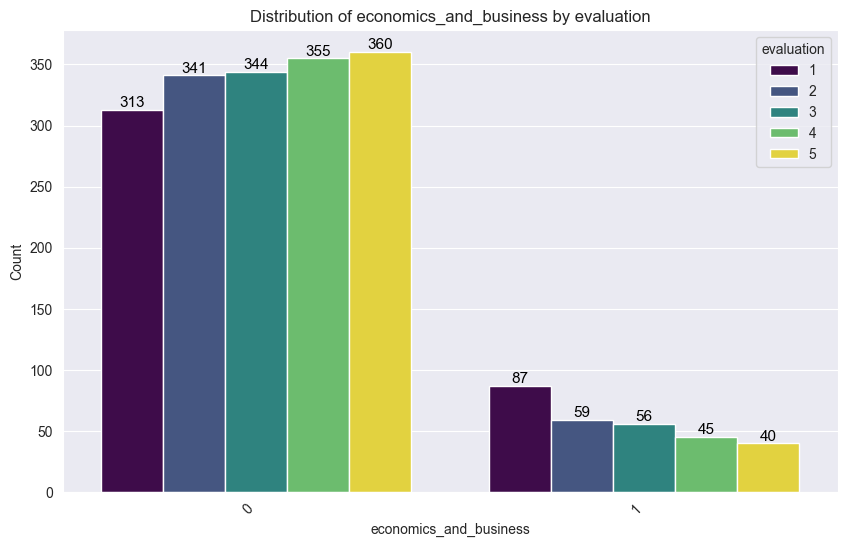

now in education
Original P-value: 1.0538501190667017e-06
Bootstrap Mean P-value: 0.0002148022466697669
Relationship is significant in 2498/2500 bootstrap samples.
Cramér's V (Effect Size): 0.12896829995774545
Effect Size: Moderate association
Significant association between education and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


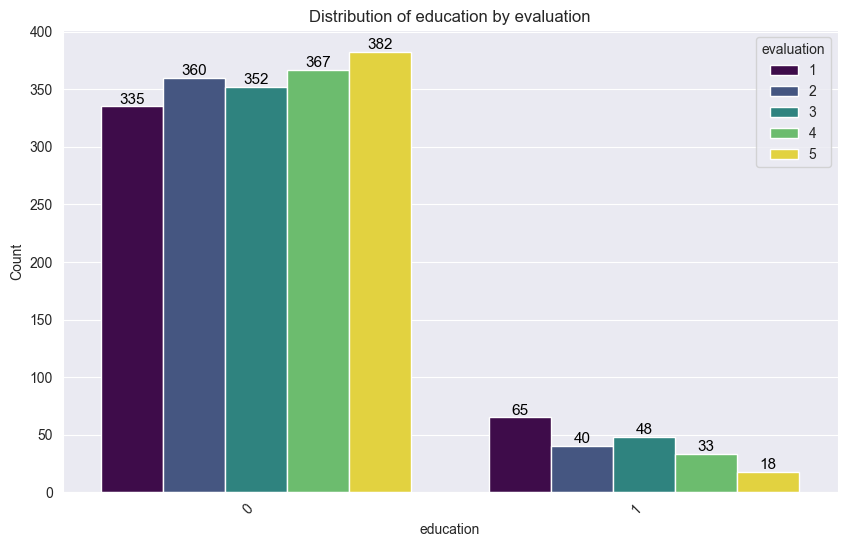

now in sociology
Original P-value: 2.231290718230671e-11
Bootstrap Mean P-value: 4.888450154096608e-07
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.16700098222238427
Effect Size: Moderate association
Significant association between sociology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


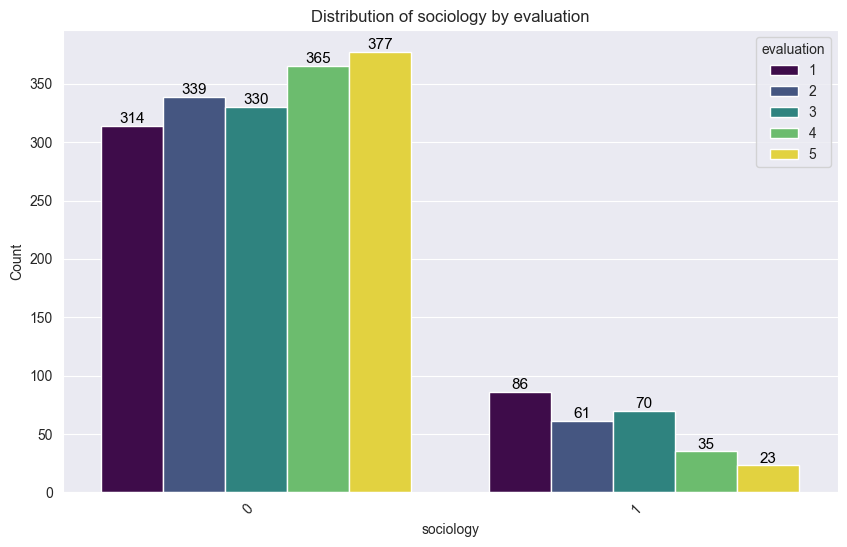

now in law
Original P-value: 8.325236485044399e-12
Bootstrap Mean P-value: 3.861397698752956e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.17002917357726197
Effect Size: Moderate association
Significant association between law and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


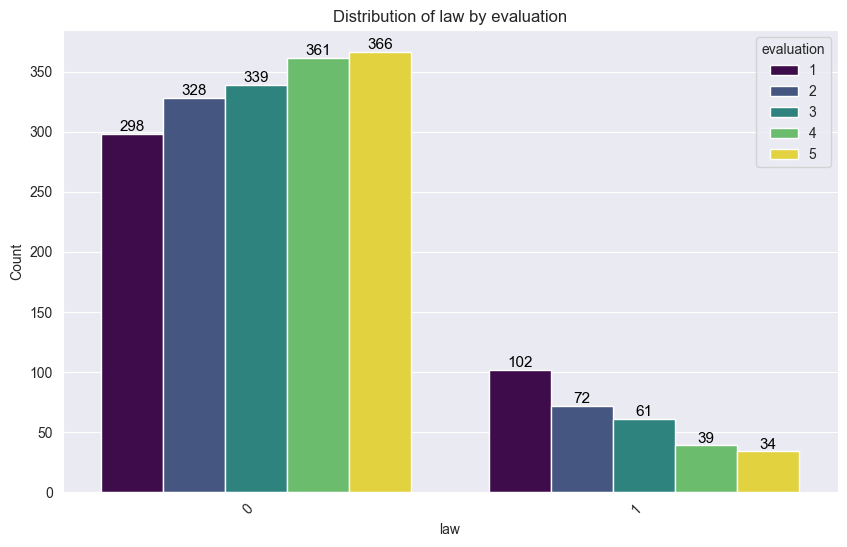

now in political_science
Original P-value: 0.0045257755536978785
Bootstrap Mean P-value: 0.021955033361622304
Relationship is significant in 2240/2500 bootstrap samples.
Cramér's V (Effect Size): 0.08685095838376547
Effect Size: Weak association
Significant association between political_science and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


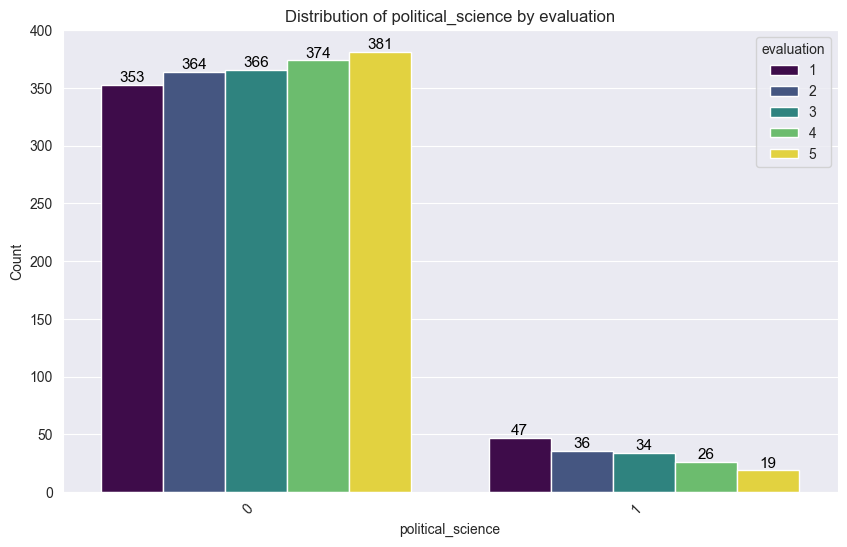

now in social_and_economic_geography
Original P-value: 6.613793087687494e-07
Bootstrap Mean P-value: 0.00033049741372500436
Relationship is significant in 2498/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1308674993043118
Effect Size: Moderate association
Significant association between social_and_economic_geography and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


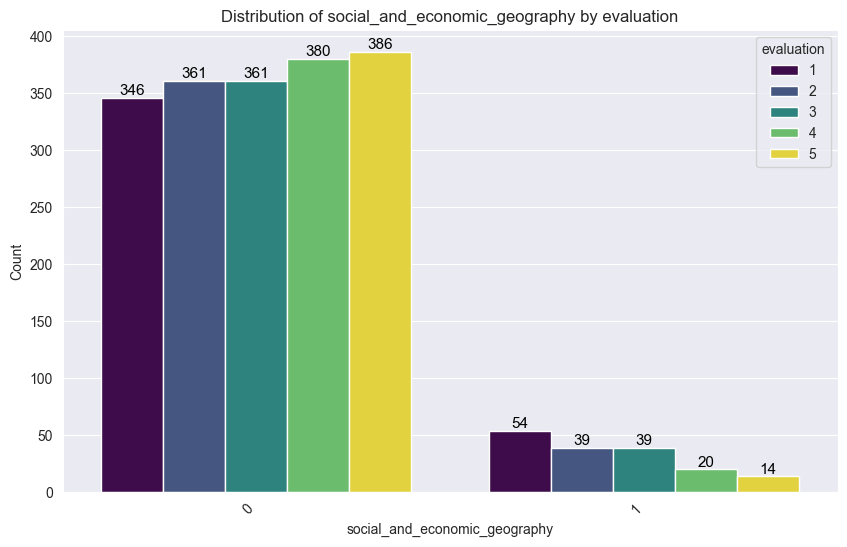

now in media_and_communications
Original P-value: 2.0655792410968958e-11
Bootstrap Mean P-value: 8.447957165259211e-07
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.16724012862024185
Effect Size: Moderate association
Significant association between media_and_communications and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


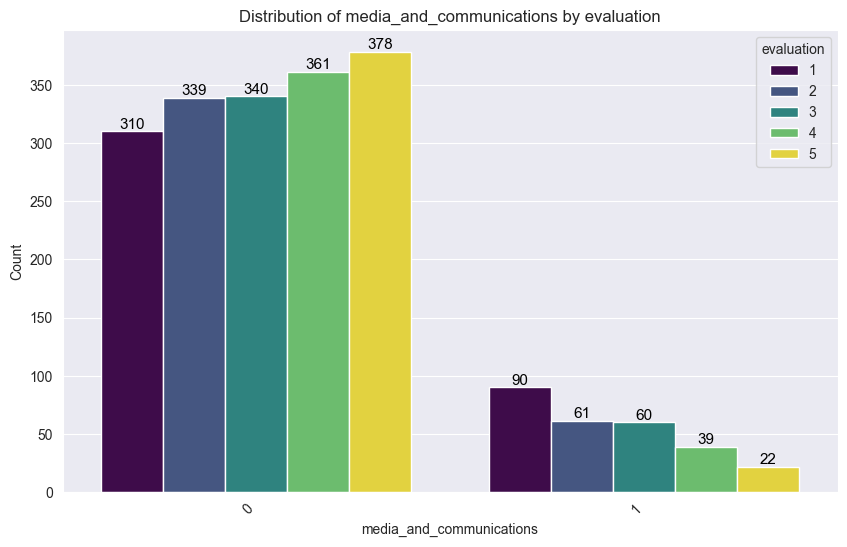

now in other_social_sciences
Original P-value: 8.699910851313753e-19
Bootstrap Mean P-value: 1.2207470139296041e-10
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.21312815910082497
Effect Size: Moderate association
Significant association between other_social_sciences and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


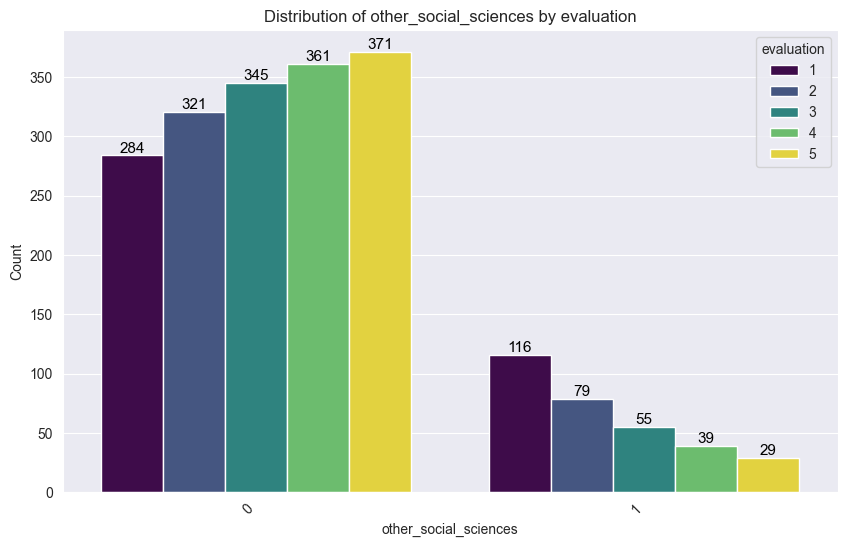

now in history_and_archaeology
Original P-value: 6.294538196374286e-13
Bootstrap Mean P-value: 4.156251182692989e-08
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1777007237464308
Effect Size: Moderate association
Significant association between history_and_archaeology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


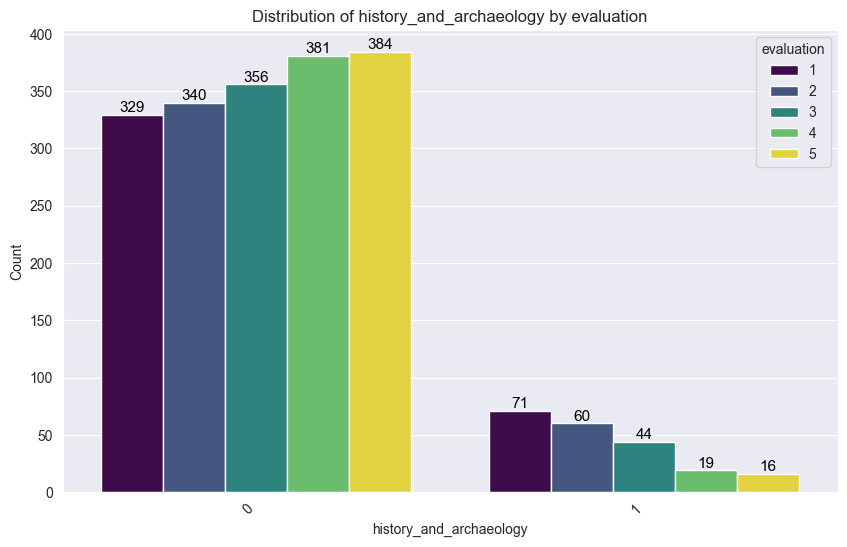

now in languages_and_literature
Original P-value: 3.615147131589007e-13
Bootstrap Mean P-value: 9.885938678610388e-08
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.17930282018820817
Effect Size: Moderate association
Significant association between languages_and_literature and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


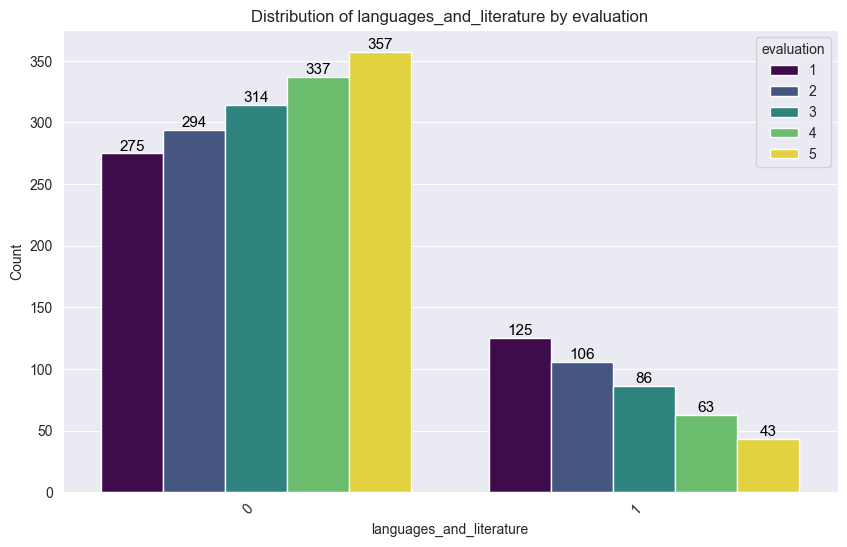

now in philosophy_ethics_and_religion
Original P-value: 2.321507926106625e-10
Bootstrap Mean P-value: 4.6888332830776175e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.15955951679626687
Effect Size: Moderate association
Significant association between philosophy_ethics_and_religion and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


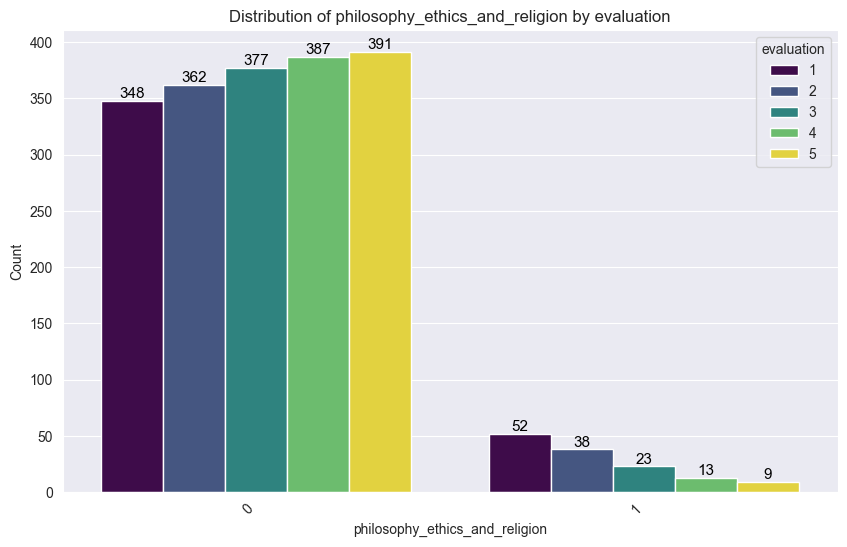

now in arts
Original P-value: 0.0010860334404684251
Bootstrap Mean P-value: 0.012618070601003941
Relationship is significant in 2350/2500 bootstrap samples.
Cramér's V (Effect Size): 0.09561327560711402
Effect Size: Weak association
Significant association between arts and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


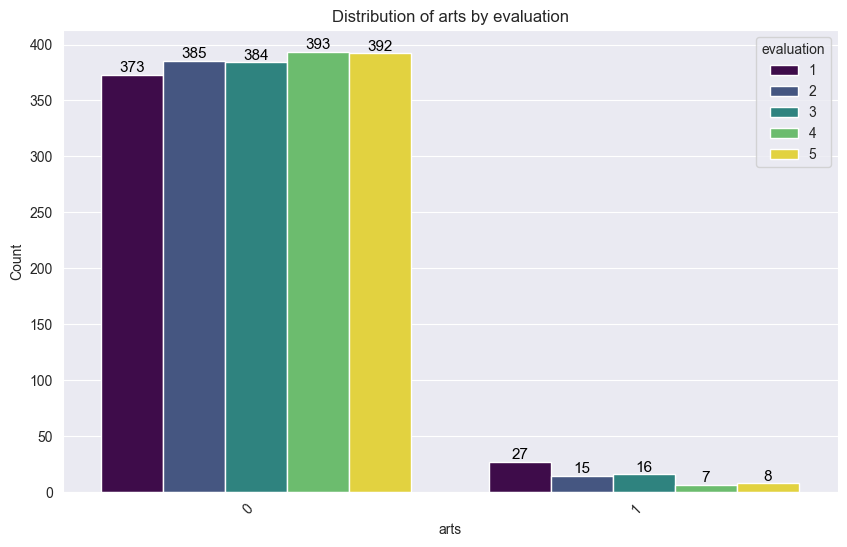

now in other_humanities_and_the_arts
Original P-value: 7.486378282280143e-13
Bootstrap Mean P-value: 7.340629628383032e-08
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1771966067288818
Effect Size: Moderate association
Significant association between other_humanities_and_the_arts and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


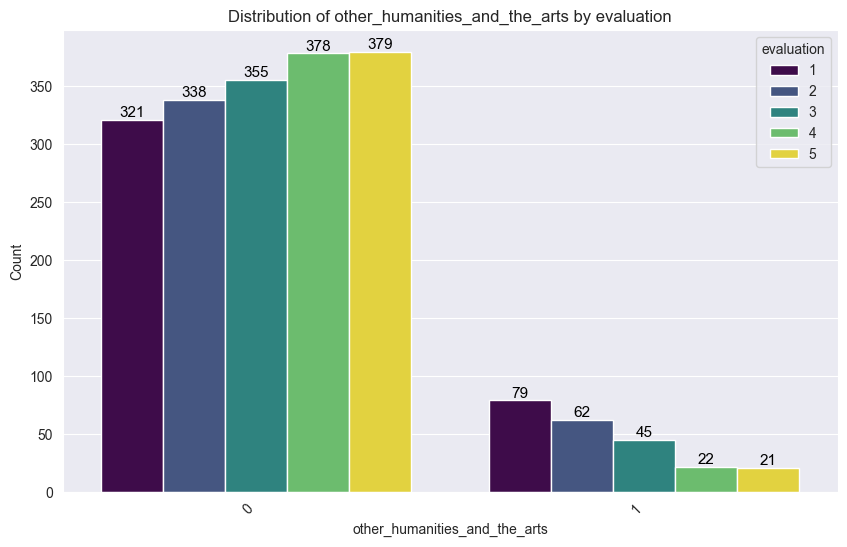

now in applied_research
Original P-value: 7.516505691881803e-10
Bootstrap Mean P-value: 8.83533261331298e-06
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.15568257207006558
Effect Size: Moderate association
Significant association between applied_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


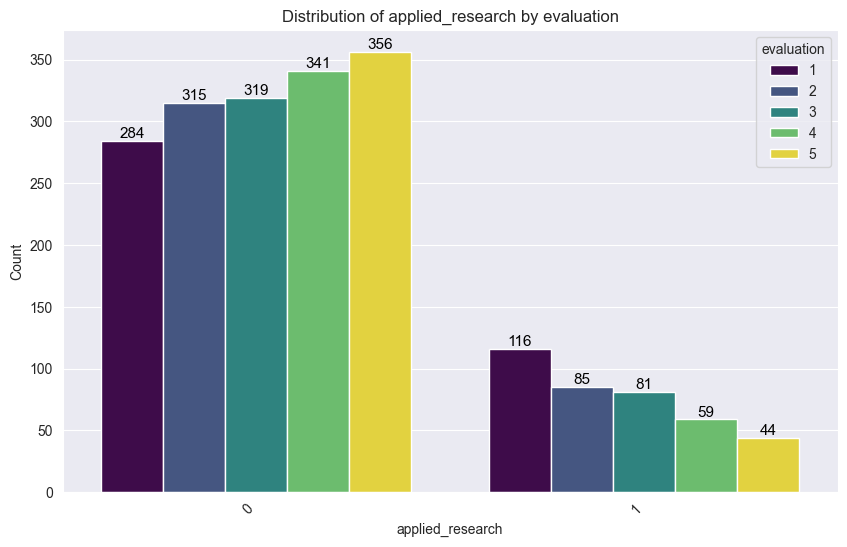

now in conclusive_research
Original P-value: 5.225364645782965e-07
Bootstrap Mean P-value: 0.00277303035376915
Relationship is significant in 2474/2500 bootstrap samples.
Cramér's V (Effect Size): 0.1318165181727608
Effect Size: Moderate association
Significant association between conclusive_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


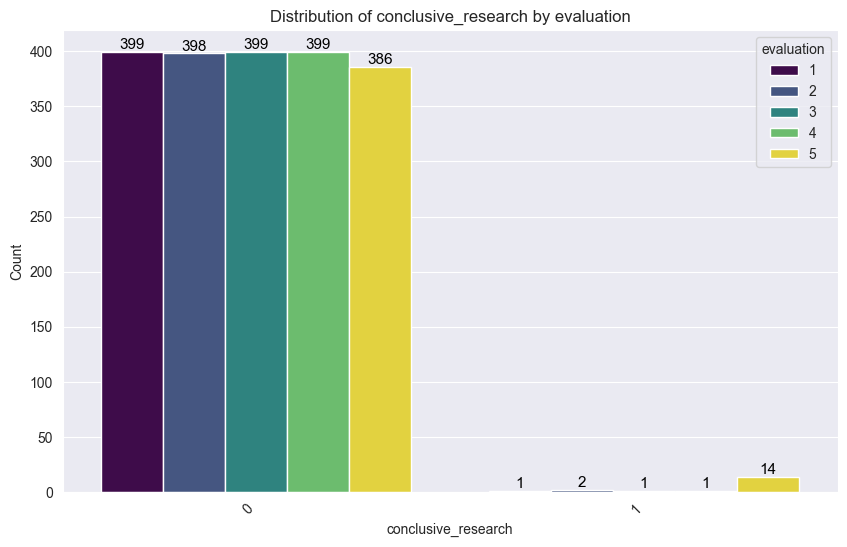

now in correlational_research
Original P-value: 0.0027965991975449317
Bootstrap Mean P-value: 0.01682663363791361
Relationship is significant in 2285/2500 bootstrap samples.
Cramér's V (Effect Size): 0.0899227255357174
Effect Size: Weak association
Significant association between correlational_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


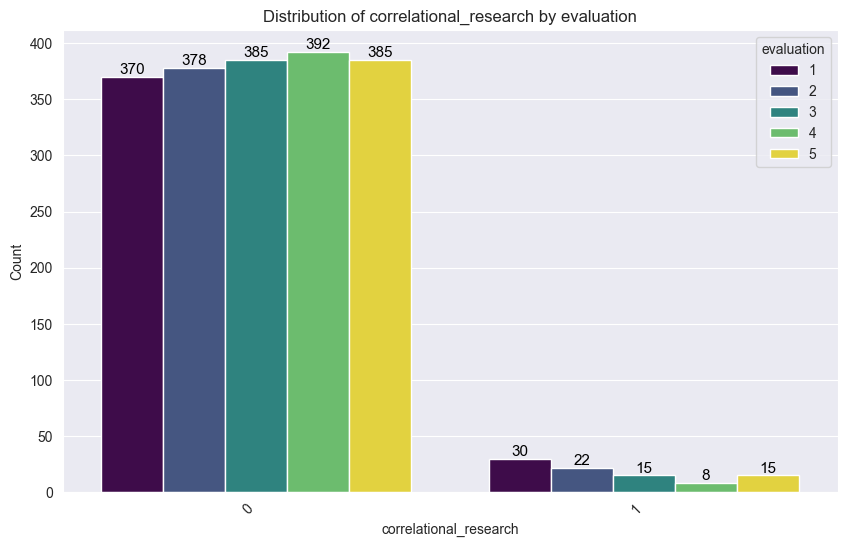

now in descriptive_research
Original P-value: 0.010206429981623282
Bootstrap Mean P-value: 0.03880237173917476
Relationship is significant in 2068/2500 bootstrap samples.
Cramér's V (Effect Size): 0.08133164076115244
Effect Size: Weak association
Significant association between descriptive_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


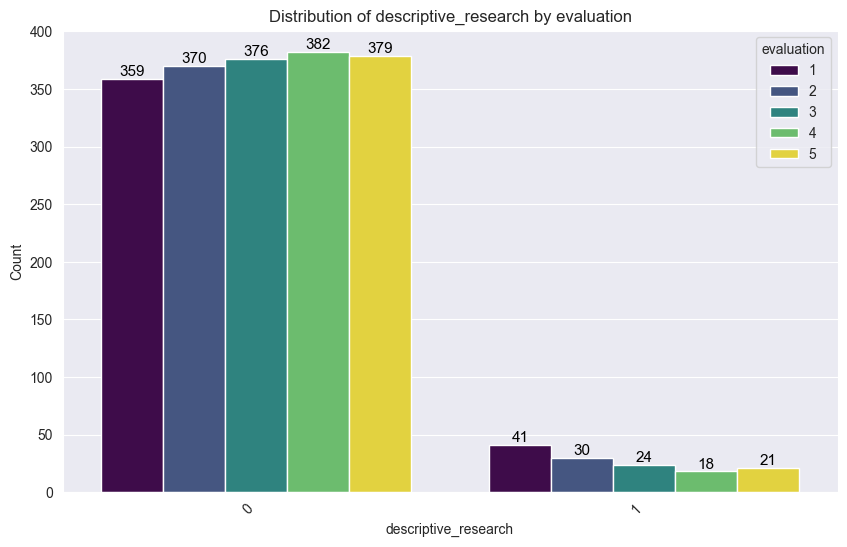

now in ethnographic_research
Original P-value: 0.04516226529402488
Bootstrap Mean P-value: 0.06497322484668955
Relationship is significant in 1777/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06976247758421804
Effect Size: Weak association
Significant association between ethnographic_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


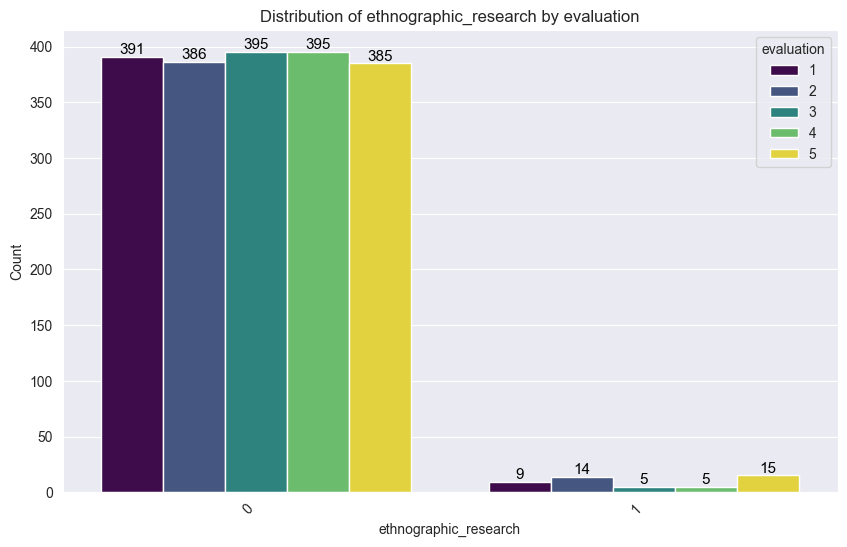

now in experiment
Original P-value: 0.0014602008833185527
Bootstrap Mean P-value: 0.027125501237438787
Relationship is significant in 2187/2500 bootstrap samples.
Cramér's V (Effect Size): 0.09387692334863258
Effect Size: Weak association
Significant association between experiment and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


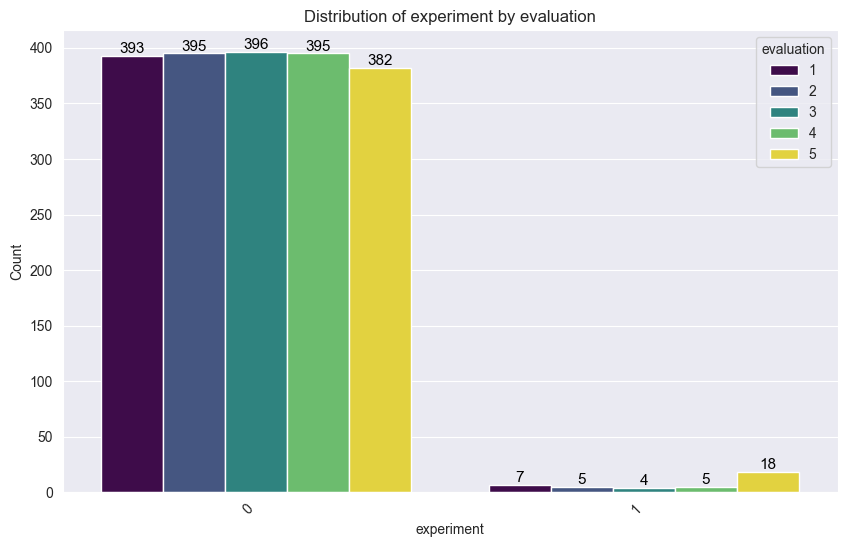

now in exploratory_research
Original P-value: 1.0174343687708971e-06
Bootstrap Mean P-value: 0.00037900815923624947
Relationship is significant in 2497/2500 bootstrap samples.
Cramér's V (Effect Size): 0.12911274294953765
Effect Size: Moderate association
Significant association between exploratory_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


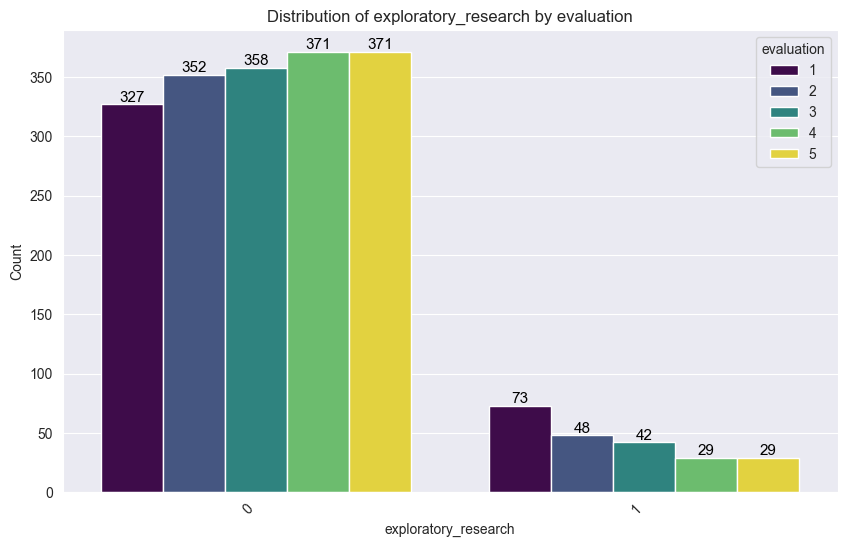

now in focus_groups
Original P-value: 1.1769514961718205e-07
Bootstrap Mean P-value: 0.0015035424049094476
Relationship is significant in 2484/2500 bootstrap samples.
Cramér's V (Effect Size): 0.13765286989778913
Effect Size: Moderate association
Significant association between focus_groups and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


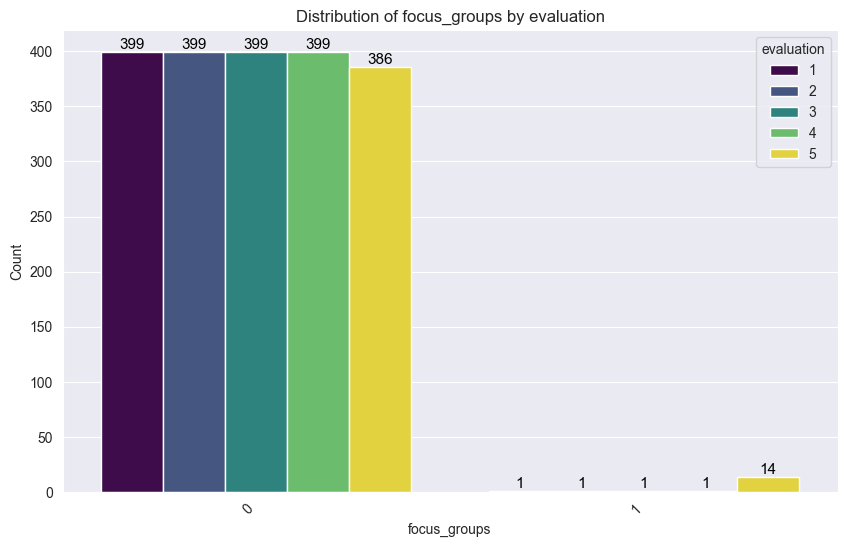

now in interviews
Original P-value: 4.813425332094345e-05
Bootstrap Mean P-value: 0.005930498938508478
Relationship is significant in 2425/2500 bootstrap samples.
Cramér's V (Effect Size): 0.11201667711546916
Effect Size: Moderate association
Significant association between interviews and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


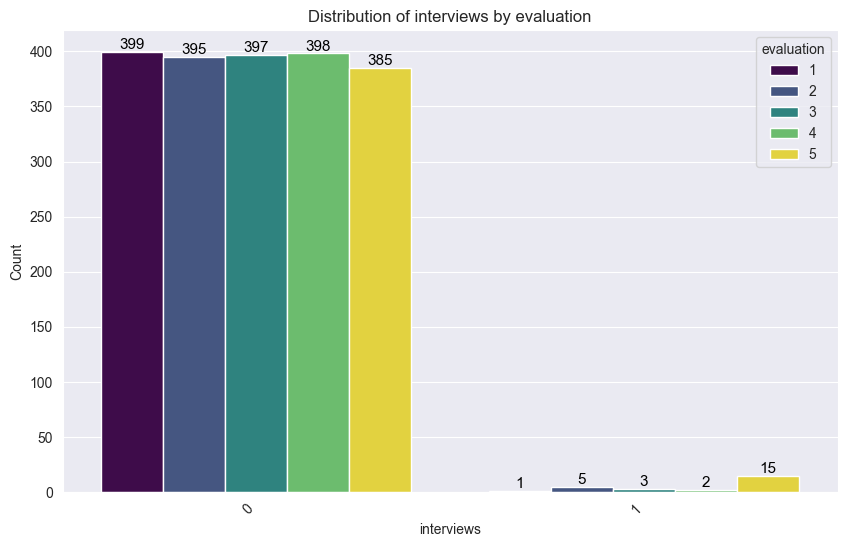

now in mixed_methods
Original P-value: 3.505857017555222e-14
Bootstrap Mean P-value: 1.754642124411727e-08
Relationship is significant in 2500/2500 bootstrap samples.
Cramér's V (Effect Size): 0.18588376609208945
Effect Size: Moderate association
Significant association between mixed_methods and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


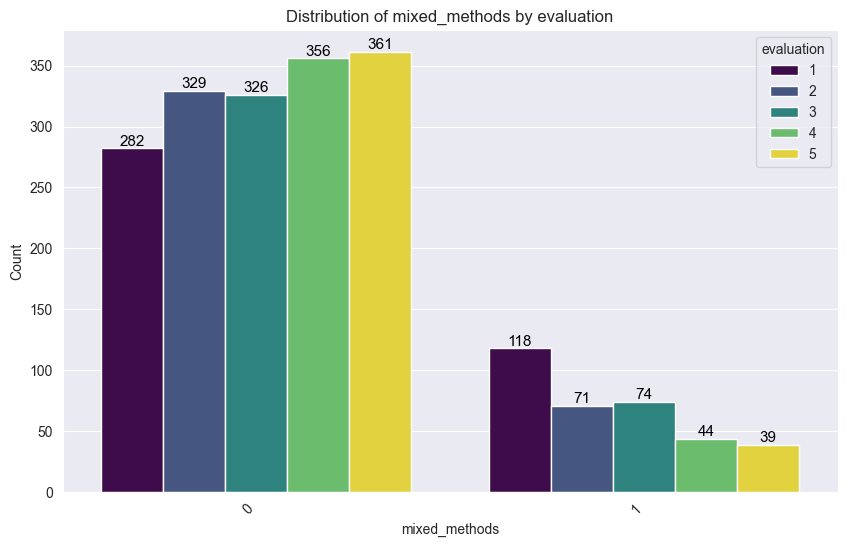

now in observation
Original P-value: 0.16456826817436787
Bootstrap Mean P-value: 0.12457474592744361
Relationship is significant in 1294/2500 bootstrap samples.
Cramér's V (Effect Size): 0.05702423755238061
Effect Size: Weak association
No significant association between observation and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


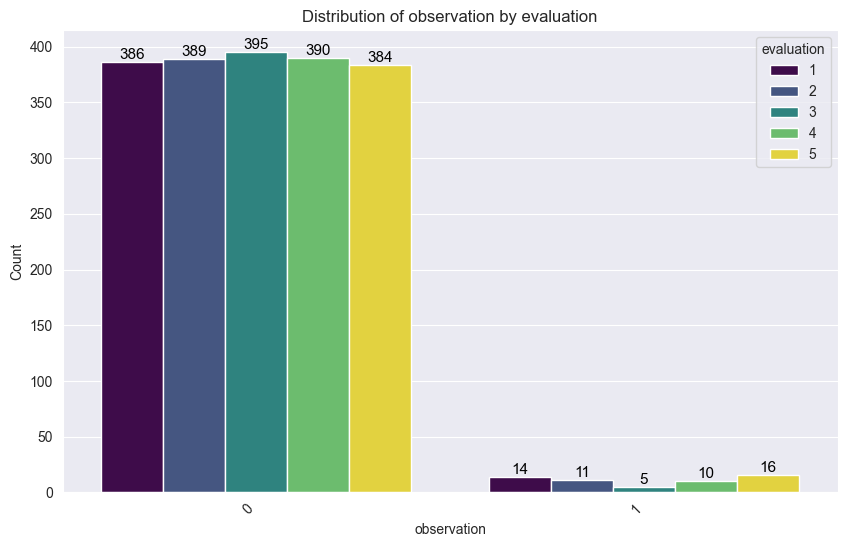

now in qualitative_research
Original P-value: 0.016234780662333886
Bootstrap Mean P-value: 0.036810916413763835
Relationship is significant in 2080/2500 bootstrap samples.
Cramér's V (Effect Size): 0.07795847248721863
Effect Size: Weak association
Significant association between qualitative_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


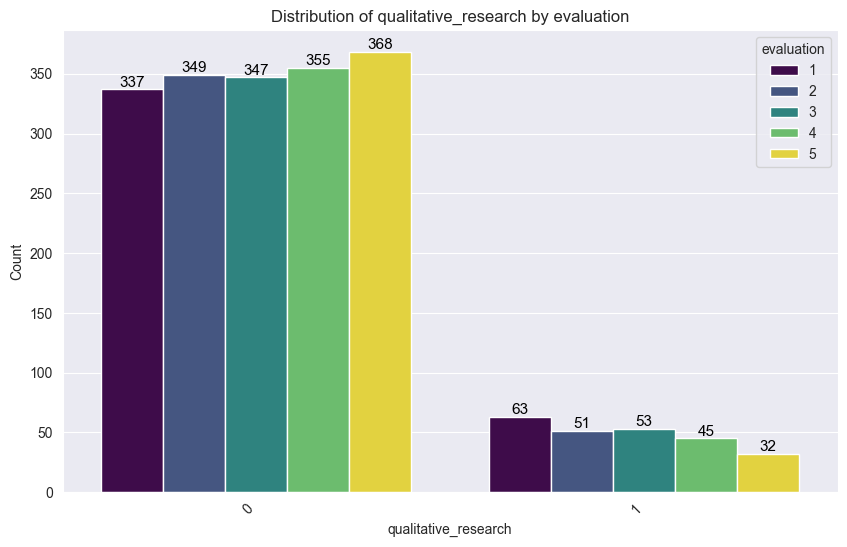

now in quantitative_research
Original P-value: 0.00024298515013624063
Bootstrap Mean P-value: 0.008492770159372142
Relationship is significant in 2400/2500 bootstrap samples.
Cramér's V (Effect Size): 0.10387367269164478
Effect Size: Moderate association
Significant association between quantitative_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


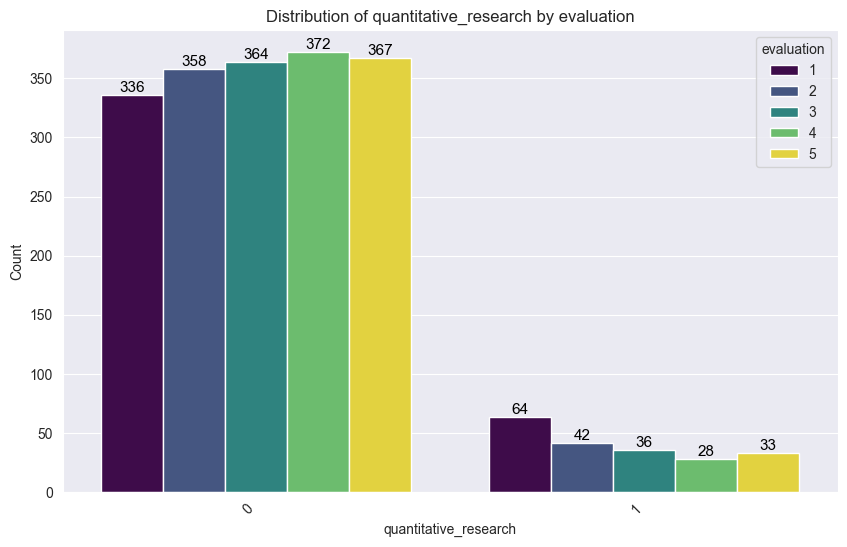

now in questionnaires
Original P-value: 1.5233285420174528e-08
Bootstrap Mean P-value: 0.0005538070059445382
Relationship is significant in 2496/2500 bootstrap samples.
Cramér's V (Effect Size): 0.14524166302597716
Effect Size: Moderate association
Significant association between questionnaires and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


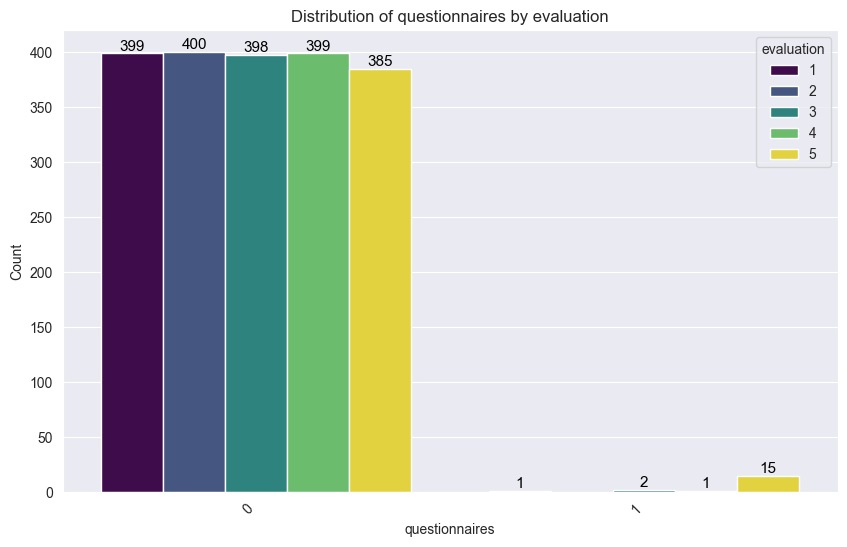

now in secondary_research
Original P-value: 0.05881076714552742
Bootstrap Mean P-value: 0.07338129172446042
Relationship is significant in 1708/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06742862042529875
Effect Size: Weak association
No significant association between secondary_research and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


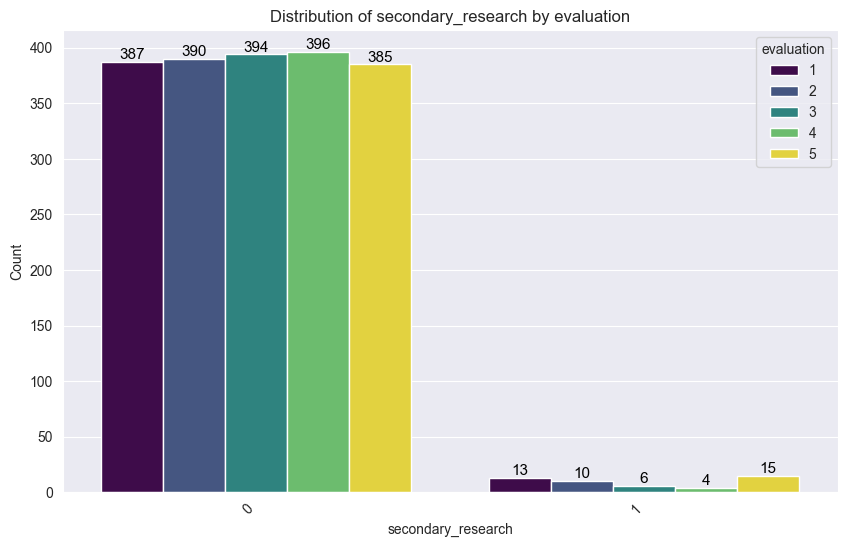

now in survey_methodology
Original P-value: 0.08422911611002004
Bootstrap Mean P-value: 0.10946082784180712
Relationship is significant in 1472/2500 bootstrap samples.
Cramér's V (Effect Size): 0.06406479096079087
Effect Size: Weak association
No significant association between survey_methodology and evaluation.
---------------------------------------------------------------


C:\Users\vojta\AppData\Local\Temp\ipykernel_26204\3098714893.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


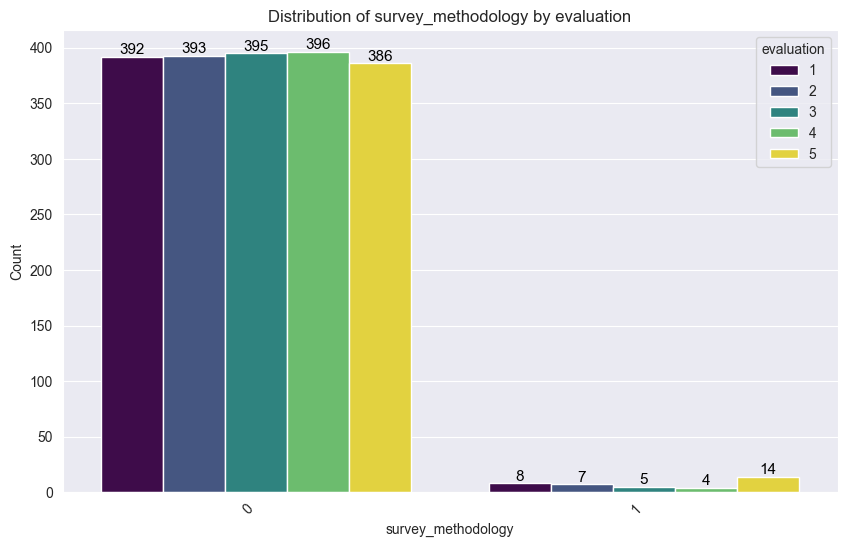

In [17]:
for col in df_m17.columns:
    if col in ['abstract', 'title', 'Unnamed: 0', 'Unnamed: 0.1', 'cited', 'science_field', 'collaborators', "journal_name", "evaluation"]:
        continue
    print(f"now in {col}")
    get_stat_significance(df_m17, col, 'evaluation')
    plot_categorical_distribution(df_m17, target_variable='evaluation', categorical_variable=col)
